<div align="center">

# Data Projects and Hackathon 3  
## Project 
Sergio Fernandez, Alessandro Mecchia 

</div>

In [201]:
# Standard Library
import gc
import json
import math
import os
import re
import subprocess
import sys
import tempfile
import time
import unicodedata
import warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import joblib

# Data Processing & Math
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.json as paj
import pyarrow.parquet as pq
import duckdb

# GPU Acceleration (RAPIDS)
try:
    import cudf
    import cugraph
    USE_RAPIDS = True
except ImportError:
    USE_RAPIDS = False
    print("RAPIDS (cudf/cugraph) not available — graph operations will not run")

# Machine Learning & NLP
import lightgbm as lgb
import torch
import shap
import yake
from langdetect import DetectorFactory, detect
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler


# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import plotly.graph_objects as go

# Graph Visualization
try:
    import graphistry
except ImportError:
    graphistry = None
    print("graphistry not available — graph visualization will be skipped")

# Interactive Notebook Tools
import ipywidgets as widgets
from IPython.display import display

# HTTP / Networking
import requests

# Configuration

warnings.filterwarnings("ignore")
DetectorFactory.seed = 0  # Ensure consistent language detection

# Try to import cuML for GPU Logistic Regression, fallback to sklearn
try:
    from cuml.linear_model import LogisticRegression as cuLogisticRegression
    USE_CUML = True
    print("cuML available — Logistic Regression will run on GPU")
except ImportError:
    from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
    USE_CUML = False
    print("cuML not available — Logistic Regression will run on CPU (sklearn)")

DATA_DIR = Path("data")


cuML not available — Logistic Regression will run on CPU (sklearn)


In [202]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [203]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)


## Functions 

This section defines all shared utility functions used throughout the notebook. It includes helpers for data cleaning and type normalization, missing value checks, OpenAlex API wrappers for imputing abstracts, references, venues, keywords and document types, language detection, and author ID/organization imputation by cross-referencing papers.

In [204]:
def to_python_nested(x):
    if x is None:
        return None
    if isinstance(x, float) and pd.isna(x):
        return None
    if isinstance(x, np.ndarray):
        return [to_python_nested(v) for v in x.tolist()]
    if isinstance(x, tuple):
        return [to_python_nested(v) for v in x]
    if isinstance(x, list):
        return [to_python_nested(v) for v in x]
    if isinstance(x, dict):
        return {k: to_python_nested(v) for k, v in x.items()}
    return x

def normalize_author_value(v):
    if isinstance(v, np.generic):
        v = v.item()
    if isinstance(v, float) and pd.isna(v):
        return None
    return v

def normalize_authors_cell(x):
    if x is None:
        return None
    if isinstance(x, float) and pd.isna(x):
        return None

    if isinstance(x, np.ndarray):
        x = x.tolist()
    elif isinstance(x, dict):
        x = [x]
    elif isinstance(x, tuple):
        x = list(x)
    elif not isinstance(x, list):
        return None

    out = []
    for item in x:
        if isinstance(item, np.ndarray):
            item = item.tolist()

        if not isinstance(item, dict):
            continue

        clean_item = {k: normalize_author_value(v) for k, v in item.items()}
        out.append(clean_item)

    return out if out else None

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    if isinstance(x, np.ndarray):
        return x.size == 0
    return pd.isna(x)

def valid_authors_sequence(authors):
    if authors is None:
        return False
    if isinstance(authors, float) and pd.isna(authors):
        return False
    try:
        if isinstance(authors, np.ndarray):
            return authors.ndim > 0 and len(authors) > 0
        return isinstance(authors, (list, tuple)) and len(authors) > 0
    except Exception:
        return False
    
def authors_complete(authors):
    if not valid_authors_sequence(authors):
        return False

    for author in authors:
        if not isinstance(author, dict):
            return False
        if is_empty(author.get("id")) or is_empty(author.get("org")):
            return False

    return True

In [205]:
def check_missing_column(pf, col):
    missing_count = 0
    filled_count = 0
    n = 0

    for rg in range(pf.num_row_groups):
        chunk = pf.read_row_group(rg, columns=[col]).to_pandas()
        missing_mask = chunk[col].apply(is_empty)

        missing_count += missing_mask.sum()
        filled_count += (~missing_mask).sum()
        n += len(chunk)

    print(f"{col} summary (sample of {n:,} rows):\n")
    print(f"missing : {missing_count:,}")
    print(f"filled  : {filled_count:,}")
    print(f"missing %: {missing_count / n * 100:.4f}")

In [206]:
OPENALEX_REFERENCES_CACHE = Path("data/cache_openalex_references.json")
MAILTO = ""  # put your email here for polite pool

def load_cache(path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_cache(path, cache):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False)

def normalize_doi(x):
    if x is None:
        return ""
    x = str(x).strip().lower()
    return x.replace("https://doi.org/", "").replace("http://doi.org/", "").rstrip("/")

def chunked(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]

def fetch_openalex_references_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,referenced_works",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        refs = work.get("referenced_works", [])
        out[doi] = refs if refs else None
    return out

def fetch_openalex_references_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_references_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_references_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_REFERENCES_CACHE)

    mask = df["references"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"references: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"references: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_references_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_REFERENCES_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        refs = cache.get(doi)

        if refs and is_empty(df.at[idx, "references"]):
            df.at[idx, "references"] = refs
            recovered += 1

    print("\nImputation completed for references")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['references'].apply(is_empty).sum()}")

In [207]:
OPENALEX_ABSTRACT_CACHE = Path("data/cache_openalex_abstracts.json")
MAILTO = "" # put your email here for polite pool

def reconstruct_abstract(inverted_index):
    if not inverted_index:
        return None

    max_pos = max((max(pos) for pos in inverted_index.values() if pos), default=-1)
    if max_pos < 0:
        return None

    words = [""] * (max_pos + 1)
    for word, positions in inverted_index.items():
        for pos in positions:
            words[pos] = word

    text = " ".join(words).strip()
    return text if text else None

def fetch_openalex_abstracts_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,abstract_inverted_index",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        abstract = reconstruct_abstract(work.get("abstract_inverted_index"))
        out[doi] = abstract
    return out

def fetch_openalex_abstracts_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_abstracts_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_abstract_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_ABSTRACT_CACHE)

    mask = df["abstract"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"abstract: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"abstract: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_abstracts_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_ABSTRACT_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        abstract = cache.get(doi)

        if abstract and is_empty(df.at[idx, "abstract"]):
            df.at[idx, "abstract"] = abstract
            recovered += 1

    print("\nImputation completed for abstract")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['abstract'].apply(is_empty).sum()}")


In [208]:
OPENALEX_VENUE_CACHE = Path("data/cache_openalex_venue.json")
MAILTO = "" # put your email here for polite pool

def extract_venue_from_work(data):
    if not isinstance(data, dict):
        return None
    venue = data.get("primary_location", {}).get("raw_source_name")
    return venue if venue else None

def fetch_openalex_venue_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,primary_location",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        venue = extract_venue_from_work(work)
        out[doi] = venue
    return out

def fetch_openalex_venue_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_venue_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_venue_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_VENUE_CACHE)

    mask = df["venue"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"venue: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"venue: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_venue_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_VENUE_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        venue = cache.get(doi)

        if venue and is_empty(df.at[idx, "venue"]):
            df.at[idx, "venue"] = venue
            recovered += 1

    print("\nImputation completed for venue")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['venue'].apply(is_empty).sum()}")


In [209]:
OPENALEX_KEYWORDS_CACHE = Path("data/cache_openalex_keywords.json")
MAILTO = "" # put your email here for polite pool

def extract_keywords_from_work(data):
    if not isinstance(data, dict):
        return None

    concepts = data.get("concepts", [])
    keywords = [
        c["display_name"]
        for c in concepts
        if c.get("level", 0) >= 1 and c.get("score", 0) >= 0.3
    ]
    return keywords if keywords else None

def fetch_openalex_keywords_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,concepts",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        keywords = extract_keywords_from_work(work)
        out[doi] = keywords
    return out

def fetch_openalex_keywords_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_keywords_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_keywords_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_KEYWORDS_CACHE)

    mask = df["keywords"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"keywords: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"keywords: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_keywords_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_KEYWORDS_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        keywords = cache.get(doi)

        if keywords and is_empty(df.at[idx, "keywords"]):
            df.at[idx, "keywords"] = keywords
            recovered += 1

    print("\nImputation completed for keywords")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['keywords'].apply(is_empty).sum()}")


In [210]:
OPENALEX_DOC_TYPE_CACHE = Path("data/cache_openalex_doc_type.json")

def fetch_openalex_doc_type_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,type",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        doc_type = work.get("type")
        out[doi] = doc_type if doc_type else None
    return out

def fetch_openalex_doc_type_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_doc_type_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_doc_type_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_DOC_TYPE_CACHE)

    mask = df["doc_type"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"doc_type: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"doc_type: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_doc_type_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_DOC_TYPE_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        doc_type = cache.get(doi)

        if doc_type and is_empty(df.at[idx, "doc_type"]):
            df.at[idx, "doc_type"] = doc_type
            recovered += 1

    print("\nImputation completed for doc_type")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['doc_type'].apply(is_empty).sum()}")


In [211]:
SUPPORTED_LANGS = {"en", "de", "fr", "pt", "es", "it", "zh", "ja", "ko", "ru"}

YAKE_LANG_MAP = {
    "en": "en",
    "it": "it",
    "fr": "fr",
    "de": "de",
    "es": "es",
    "pt": "pt",
    "zh": "zh",
    "ja": "ja",
    "ko": "ko",
    "ru": "ru",
}


In [212]:
def detect_lang(row):
    parts = []
    for col in ["title", "abstract", "venue"]:
        val = row.get(col)
        if isinstance(val, str) and val.strip():
            parts.append(val.strip())

    text = " ".join(parts)

    if len(text) < 30:
        return None

    try:
        pred = detect(text)
        return pred if pred in SUPPORTED_LANGS else None
    except Exception:
        return None


In [213]:
def valid_authors_sequence(authors):
    if authors is None:
        return False
    if isinstance(authors, float) and pd.isna(authors):
        return False

    try:
        if isinstance(authors, np.ndarray):
            return authors.ndim > 0 and len(authors) > 0
        return isinstance(authors, (list, tuple)) and len(authors) > 0
    except Exception:
        return False


def build_author_mappings(input_path):
    pf = pq.ParquetFile(input_path)

    name_to_year_ids = defaultdict(list)
    name_to_year_orgs = defaultdict(list)

    for rg in range(pf.num_row_groups):
        print(f"[authors mapping] Row group {rg + 1}/{pf.num_row_groups}")

        chunk = pf.read_row_group(rg, columns=["authors", "year"]).to_pandas()

        for _, row in chunk.iterrows():
            year = row.get("year")
            authors = row.get("authors")

            if not valid_authors_sequence(authors):
                continue

            parsed_year = None
            try:
                if year is not None and not (isinstance(year, float) and pd.isna(year)):
                    parsed_year = int(year)
            except Exception:
                parsed_year = None

            if parsed_year is None:
                continue

            for author in authors:
                if not isinstance(author, dict):
                    continue

                name = author.get("name")
                author_id = author.get("id")
                org = author.get("org")

                if isinstance(name, str):
                    name = name.strip()

                if not name:
                    continue

                if isinstance(author_id, str) and author_id.strip():
                    name_to_year_ids[name].append((parsed_year, author_id.strip()))

                if isinstance(org, str) and org.strip():
                    name_to_year_orgs[name].append((parsed_year, org.strip()))

    print(f"Created ID history for {len(name_to_year_ids):,} author names")
    print(f"Created org history for {len(name_to_year_orgs):,} author names")

    return name_to_year_ids, name_to_year_orgs


In [214]:
def impute_authors_id_chunk(chunk, name_to_year_ids):
    recovered = 0

    for idx, row in chunk.iterrows():
        authors = row.get("authors")
        year = row.get("year")

        if not valid_authors_sequence(authors):
            continue

        try:
            if year is None or (isinstance(year, float) and pd.isna(year)):
                continue
            year = int(year)
        except Exception:
            continue

        changed = False
        for author in authors:
            if not isinstance(author, dict):
                continue

            name = author.get("name")
            author_id = author.get("id")

            if isinstance(name, str):
                name = name.strip()

            if author_id or not name:
                continue

            candidates = name_to_year_ids.get(name)
            if not candidates:
                continue

            best_author_id = None
            best_distance = float("inf")

            for cand_year, cand_author_id in candidates:
                distance = year - cand_year
                if 0 <= distance < best_distance:
                    best_author_id = cand_author_id
                    best_distance = distance
                    if distance == 0:
                        break

            if best_author_id:
                author["id"] = best_author_id
                recovered += 1
                changed = True

        if changed:
            chunk.at[idx, "authors"] = authors

    print(f"Recovered {recovered:,} author IDs")
    return chunk


In [215]:
def impute_authors_org_chunk(chunk, name_to_year_orgs, max_year_diff=1):
    recovered = 0

    for idx, row in chunk.iterrows():
        year = row.get("year")
        authors = row.get("authors")

        if not valid_authors_sequence(authors):
            continue

        try:
            if year is None or (isinstance(year, float) and pd.isna(year)):
                continue
            year = int(year)
        except Exception:
            continue

        changed = False
        for author in authors:
            if not isinstance(author, dict):
                continue

            name = author.get("name")
            org = author.get("org")

            if isinstance(name, str):
                name = name.strip()

            if org or not name:
                continue

            candidates = name_to_year_orgs.get(name)
            if not candidates:
                continue

            best_org = None
            best_distance = float("inf")

            for cand_year, cand_org in candidates:
                distance = year - cand_year
                if 0 <= distance <= max_year_diff and distance < best_distance:
                    best_org = cand_org
                    best_distance = distance
                    if distance == 0:
                        break

            if best_org:
                author["org"] = best_org
                recovered += 1
                changed = True

        if changed:
            chunk.at[idx, "authors"] = authors

    print(f"Recovered {recovered:,} author ORGs")
    return chunk


## 1. Data Creation

The raw dataset is DBLP Citation Network V18, a large JSONL file containing millions of scientific papers. Loading it directly into memory is not feasible, so we first convert it to Parquet a compressed columnar format that allows efficient on-disk querying and then query it with DuckDB without ever loading the full dataset into RAM.

### 1.1. Parquet Creation 


Run only once. We stream the JSONL file batch by batch and write it incrementally to a compressed Parquet file, dropping a few uninformative columns along the way.

In [34]:
DATA_DIR = Path("data")
SOURCE_PATH = DATA_DIR / "DBLP-Citation-network-V18.jsonl"
TARGET_PATH = DATA_DIR / "DBLP-Citation-network-V18.parquet"
BLOCK_SIZE = 64 * 1024 * 1024  

if TARGET_PATH.exists() or Path("final_dataset.parquet").exists() or Path("dataset.parquet").exists():
    raise FileNotFoundError(f"File non trovato: {SOURCE_PATH}")

if pa.Codec.is_available("zstd"):
    COMPRESSION = "zstd"
elif pa.Codec.is_available("snappy"):
    COMPRESSION = "snappy"
else:
    COMPRESSION = None

if SOURCE_PATH.exists():
    print(f"Input : {SOURCE_PATH} ({SOURCE_PATH.stat().st_size / 1024**3:.2f} GiB)")
else:
    print(f"Input : {SOURCE_PATH} (missing)")

print(f"Output: {TARGET_PATH}")
print(f"Compression: {COMPRESSION}")
print(f"Block size: {BLOCK_SIZE / 1024**2:.0f} MiB")

Input : data/DBLP-Citation-network-V18.jsonl (14.85 GiB)
Output: data/DBLP-Citation-network-V18.parquet
Compression: zstd
Block size: 64 MiB


In [35]:
DROP_COLS = {"page_start", "page_end", "volume", "issue", "issn", "isbn", "url"}

if TARGET_PATH.exists():
    print(f"Parquet already exists, skipping conversion.")
else:
    reader = paj.open_json(
        SOURCE_PATH,
        read_options=paj.ReadOptions(block_size=BLOCK_SIZE),
    )

    writer = None
    rows_written = 0
    batches_written = 0
    started_at = time.perf_counter()

    try:
        while True:
            try:
                batch = reader.read_next_batch()
            except StopIteration:
                break

            keep_cols = [name for name in batch.schema.names if name not in DROP_COLS]
            batch = batch.select(keep_cols)

            if writer is None:
                writer = pq.ParquetWriter(
                    TARGET_PATH,
                    batch.schema,
                    compression=COMPRESSION,
                )

            writer.write_batch(batch)
            rows_written += batch.num_rows
            batches_written += 1

            if batches_written % 25 == 0:
                elapsed = time.perf_counter() - started_at
                print(f"Batch: {batches_written:>5} | Rows: {rows_written:>12,} | Elapsed: {elapsed:>8.1f}s")

        if writer is None:
            raise RuntimeError("JSONL file seems empty: no batch read.")
    finally:
        reader.close()
        if writer is not None:
            writer.close()

    elapsed = time.perf_counter() - started_at
    print(f"Conversion completed in {elapsed:.1f}s")
    print(f"Rows written : {rows_written:,}")
    print(f"JSONL size   : {SOURCE_PATH.stat().st_size / 1024**3:.2f} GiB")
    print(f"Parquet size : {TARGET_PATH.stat().st_size / 1024**3:.2f} GiB")

Batch:    25 | Rows:      708,650 | Elapsed:      4.3s
Batch:    50 | Rows:    1,416,669 | Elapsed:      8.3s
Batch:    75 | Rows:    2,125,369 | Elapsed:     12.2s
Batch:   100 | Rows:    2,833,128 | Elapsed:     16.1s
Batch:   125 | Rows:    3,541,516 | Elapsed:     20.2s
Batch:   150 | Rows:    4,249,581 | Elapsed:     24.1s
Batch:   175 | Rows:    4,957,371 | Elapsed:     28.1s
Batch:   200 | Rows:    5,665,742 | Elapsed:     32.1s
Batch:   225 | Rows:    6,373,876 | Elapsed:     36.0s
Conversion completed in 37.9s
Rows written : 6,729,828
JSONL size   : 14.85 GiB
Parquet size : 4.34 GiB


### 1.2. Data Creation with DuckDB


We run all profiling and data quality checks directly on the full Parquet file via DuckDB, so that missing value counts and year distributions reflect the entire dataset rather than a sample.

In [36]:
PARQUET_PATH = Path("data/DBLP-Citation-network-V18.parquet")


con = duckdb.connect(":memory:")

# con = duckdb.connect(r"C:\Users\ms\Desktop\dblp.duckdb")

con.execute("PRAGMA threads=4;")
con.execute("PRAGMA enable_progress_bar;")

parquet_str = PARQUET_PATH.as_posix()

con.execute(f"""
    CREATE OR REPLACE VIEW papers AS
    SELECT *
    FROM read_parquet('{parquet_str}');
""")

In [37]:
display(con.execute("SELECT * FROM papers LIMIT 5").fetchdf())

,id,title,abstract,keywords,year,authors,references,lang,doi,n_citation,venue,doc_type
0,5390877920f70186a0d2ce7f,Top-Down Construction of 3-D Mechanical Object...,,"[First Page, 3-D Mechanical Object Shapes, Eng...",1984,"[{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H...","[5390962020f70186a0df3bf2, 5390879d20f70186a0d...",en,10.1109/mc.1984.1659026,46,Computer,Journal
1,5390877920f70186a0d2d85b,MH: A Multifarious User Agent.,The UCI version of the Rand Message Handling S...,"[Computer network mail, Distributed mail syste...",1985,"[{'id': '', 'name': 'MT ROSE', 'org': None}, {...",[5390880720f70186a0d7a97e],en,10.1016/0169-7552(85)90077-7,4,Computer Networks and ISDN Systems,Journal
2,5390877920f70186a0d2e433,Characterizing an Optimal Input in Perturbed C...,When every feasible stable perturbation of dat...,"[Optimal input, region of stability, input con...",1983,"[{'id': '53f43a54dabfaee43ec54f70', 'name': 'S...","[53e99d28b7602d97025da4e6, 5390877920f70186a0d...",en,10.1007/bf02591721,20,Mathematical Programming,Journal
3,5390877f20f70186a0d2fca6,Theoretical Aspects of Sigma-programming,,[theoretical aspect],1986,"[{'id': '65570cb0145e064b7afc5d53', 'name': 'G...",[],en,10.1007/3-540-16444-8_13,35,Lecture Notes in Computer Science Mathematical...,Conference
4,5390878320f70186a0d33e0e,I 3 R: a New Approach to the Design of Documen...,THE MOST EFFECTIVE METHOD OF IMPROVING THE RET...,"[INFORMATION NEED, A GIVEN STAGE, PROVIDES A N...",1987,"[{'id': '53f459c4dabfaee2a1d80cdf', 'name': 'W...","[53e9ab6fb7602d9703510c21, 53e9baa0b7602d97046...",en,10.1002/(sici)1097-4571(198711)38:6<389::aid-a...,467,Journal of the American Society for Informatio...,Journal


In [38]:
# PROFILE_DB_PATH = DATA_DIR / "dblp_profiling.duckdb"

# con_full = duckdb.connect(PROFILE_DB_PATH.as_posix())
# con_full.execute("PRAGMA threads=4;")
# con_full.execute("PRAGMA enable_progress_bar;")

# con_full.execute(f"""
#     CREATE OR REPLACE VIEW papers_full AS
#     SELECT *
#     FROM read_parquet('{parquet_str}');
# """)

# total_rows_full = con_full.execute("SELECT COUNT(*) FROM papers_full").fetchone()[0]
# print(f"Profiling DB: {PROFILE_DB_PATH}")
# print(f"Total rows available in DuckDB: {total_rows_full:,}")

## 2. Data Exploration  

We start by exploring the dataset to understand its structure, the available fields, and the general quality of the data before any cleaning or filtering.

In [39]:
# pf = pq.ParquetFile(r"data/DBLP-Citation-network-V18.parquet")

# print(f"Total rows   : {pf.metadata.num_rows:,}")
# print(f"Columns      : {pf.metadata.num_columns}")
# print(f"Row groups   : {pf.metadata.num_row_groups}")

In [40]:
total_rows = con.execute("""
    SELECT COUNT(*)
    FROM papers
""").fetchone()[0]

n_columns = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf().shape[0]

row_groups = con.execute(f"""
    SELECT COUNT(DISTINCT row_group_id)
    FROM parquet_metadata('{parquet_str}')
""").fetchone()[0]

print(f"Total rows   : {total_rows:,}")
print(f"Columns      : {n_columns}")
print(f"Row groups   : {row_groups}")


Total rows   : 6,729,828
Columns      : 12
Row groups   : 238


The dataset contains almost 7 million papers across 12 columns. This is relevant because it means we can afford to drop low-quality records without risking significant data loss.

In [41]:
schema_df = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf()

for i, name in enumerate(schema_df["column_name"]):
    print(f"{i}. {name}")


0. id
1. title
2. abstract
3. keywords
4. year
5. authors
6. references
7. lang
8. doi
9. n_citation
10. venue
11. doc_type


In [42]:
schema_df = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf()

columns = schema_df["column_name"].tolist()

dropdown = widgets.Dropdown(options=columns, description="Colonna:")
output = widgets.Output()

def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        col = change["new"]
        with output:
            output.clear_output()
            df = con.execute(f'''
                SELECT "{col}"
                FROM papers
                LIMIT 10
            ''').fetchdf()
            display(df)

dropdown.observe(on_change)

display(dropdown, output)

Dropdown(description='Colonna:', options=('id', 'title', 'abstract', 'keywords', 'year', 'authors', 'reference…

Output()

In [43]:
paper = con.execute("""
    SELECT *
    FROM papers
    LIMIT 1
""").fetchdf().iloc[0]

for col, val in paper.items():
    print(f"{col:15}: {val}")

id             : 5390877920f70186a0d2ce7f
title          : Top-Down Construction of 3-D Mechanical Object Shapes from Engineering Drawings
abstract       : 
keywords       : ['First Page' '3-D Mechanical Object Shapes' 'Engineering Drawings'
 'Top-Down Construction']
year           : 1984
authors        : [{'id': '62aad3b2d9f2040d085dc9f9', 'name': 'H YOSHIURA', 'org': 'Hitachi Research Laboratory, Hitachi Ltd.'}
 {'id': '5608ec4a45cedb3396db2920', 'name': 'K FUJIMURA', 'org': 'Univ. of Tokyo, Tokyo, Japan'}
 {'id': '548a62d3dabfae8a11fb49e2', 'name': 'TL KUNII', 'org': None}]
references     : ['5390962020f70186a0df3bf2' '5390879d20f70186a0d43d74'
 '5390a1e620f70186a0e59c05' '5390b1d220f70186a0ee1bd6'
 '53909f8220f70186a0e3cfc7' '5390962020f70186a0df3f87'
 '53e9b8a8b7602d970447e86b']
lang           : en
doi            : 10.1109/mc.1984.1659026
n_citation     : 46
venue          : Computer
doc_type       : Journal


We can see the available features and inspect their content. Fields like abstract, keywords, doc_type, venue and references look promising for our task. Columns like page numbers, volume, issue and URLs were already dropped during the Parquet conversion as they carry little predictive meaning for our task.

Interesting is how author data is stored: each paper has an `authors` field containing a list of dictionaries, each with the author's name, id, and affiliated organization.

### 2.1. Data Selection

Since the dataset is large and many papers contain missing values, our goal is to identify and keep only the records with the best data quality. The following charts show how missing values are distributed across features, which will guide our filtering decisions.

In [44]:
con.execute("""
    CREATE OR REPLACE VIEW papers_profile_base AS
    SELECT
        *,
        CASE WHEN title IS NULL OR TRIM(CAST(title AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_title,
        CASE WHEN abstract IS NULL OR TRIM(CAST(abstract AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_abstract,
        CASE WHEN doi IS NULL OR TRIM(CAST(doi AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_doi,
        CASE WHEN lang IS NULL OR TRIM(CAST(lang AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_lang,
        CASE WHEN venue IS NULL OR TRIM(CAST(venue AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_venue,
        CASE WHEN doc_type IS NULL OR TRIM(CAST(doc_type AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_doc_type,
        CASE WHEN COALESCE(array_length(keywords), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_keywords,
        CASE WHEN COALESCE(array_length("references"), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_references,
        CASE WHEN COALESCE(array_length(authors), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_authors,
        CASE WHEN TRY_CAST(year AS INTEGER) IS NULL THEN TRUE ELSE FALSE END AS flag_year_missing,
        TRY_CAST(year AS INTEGER) AS year_int

    FROM papers
""")


We create a profiling view that extends the original table with a boolean flag for each column, marking whether the value is missing or empty. This lets us count and filter missing values efficiently using SQL without loading the data into memory.

### 2.1.1. Missing Values

In [45]:
missing_summary = con.execute("""
    SELECT * FROM (
        SELECT 'title' AS feature, SUM(CAST(flag_missing_title AS INTEGER)) AS count_rows FROM papers_profile_base
        UNION ALL
        SELECT 'abstract', SUM(CAST(flag_missing_abstract AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'doi', SUM(CAST(flag_missing_doi AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'lang', SUM(CAST(flag_missing_lang AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'venue', SUM(CAST(flag_missing_venue AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'doc_type', SUM(CAST(flag_missing_doc_type AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'keywords', SUM(CAST(flag_missing_keywords AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'references', SUM(CAST(flag_missing_references AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'authors', SUM(CAST(flag_missing_authors AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'year', SUM(CAST(flag_year_missing AS INTEGER)) FROM papers_profile_base
    )
    ORDER BY count_rows DESC
""").fetchdf()

total_rows = con.execute("SELECT COUNT(*) FROM papers_profile_base").fetchone()[0]
missing_summary["pct_rows"] = missing_summary["count_rows"] / total_rows * 100
missing_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,feature,count_rows,pct_rows
0,keywords,1090024.0,16.196907
1,references,1052766.0,15.643282
2,doi,601990.0,8.945102
3,abstract,361893.0,5.377448
4,lang,242582.0,3.604579
5,venue,44889.0,0.667016
6,doc_type,21044.0,0.312697
7,authors,3.0,0.000045
8,title,0.0,0.000000
9,year,0.0,0.000000


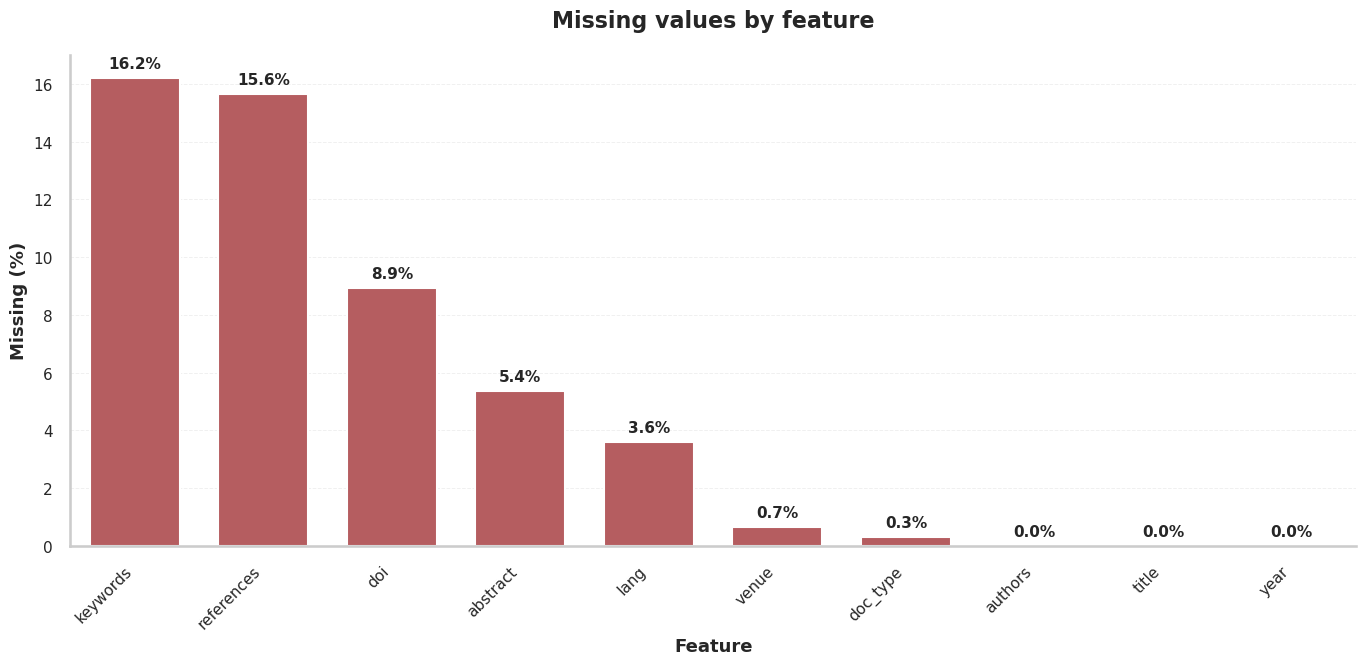

In [46]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=missing_summary, x="feature", y="pct_rows", color="#C44E52", width=0.7)

plt.title("Missing values by feature", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Feature", fontsize=13, fontweight='bold')
plt.ylabel("Missing (%)", fontsize=13, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

Looking at the missing values, we can already spot some issues, mainly in keywords, references and doi. Our goal is to work carefully on data quality and retain as much information as possible, dropping only what is truly unrecoverable. This step gives us a clear picture of which columns will require imputation work before we can use them effectively.

In [47]:
authors_missing_summary = con.execute("""
WITH authors_exploded AS (
    SELECT
        p.id AS paper_id,
        a.author AS author
    FROM papers_profile_base p
    CROSS JOIN UNNEST(p.authors) AS a(author)
)
SELECT
    COUNT(*) AS total_author_rows,
    SUM(CASE WHEN author.id IS NULL OR TRIM(CAST(author.id AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_id,
    SUM(CASE WHEN author.name IS NULL OR TRIM(CAST(author.name AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_name,
    SUM(CASE WHEN author.org IS NULL OR TRIM(CAST(author.org AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_org
FROM authors_exploded
""").fetchdf()

display(authors_missing_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_author_rows,missing_author_id,missing_author_name,missing_author_org
0,22998013,2284412.0,228.0,4208990.0


We also inspect missing values inside the `authors` field, which is a nested structure. The main issue is the missing `org` field, while `id` and `name` are mostly present. This is less critical since we can recover missing author information by cross-referencing other papers that share the same author id.

In [48]:
missing_by_year = con.execute("""
    SELECT
        year_int AS year,
        COUNT(*) AS n_papers,
        SUM(CAST(flag_missing_abstract AS INTEGER)) AS missing_abstract,
        SUM(CAST(flag_missing_doi AS INTEGER)) AS missing_doi,
        SUM(CAST(flag_missing_venue AS INTEGER)) AS missing_venue,
        SUM(CAST(flag_missing_doc_type AS INTEGER)) AS missing_doc_type,
        SUM(CAST(flag_missing_keywords AS INTEGER)) AS missing_keywords,
        SUM(CAST(flag_missing_references AS INTEGER)) AS missing_references
    FROM papers_profile_base
    WHERE year_int IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

display(missing_by_year.head(5))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,n_papers,missing_abstract,missing_doi,missing_venue,missing_doc_type,missing_keywords,missing_references
0,0,10,0.0,2.0,0.0,0.0,2.0,9.0
1,13,7,0.0,0.0,0.0,0.0,1.0,3.0
2,14,4,0.0,0.0,0.0,0.0,0.0,2.0
3,210,27,0.0,0.0,0.0,0.0,0.0,5.0
4,1808,1,0.0,0.0,0.0,0.0,0.0,1.0


We then look at how missing values are distributed across years. As expected, there are paper with wrong year number and they contain missing values. We decide to restrict the dataset to papers published between 1990 and 2026, since records outside this range are either too sparse or likely erroneous. Additionally, since we plan to use the DOI to recover missing abstracts and references via the OpenAlex API, we drop any paper that is missing its DOI and at the same time has no abstract or no references, as these would be unrecoverable.

In [49]:
con.execute("""
CREATE OR REPLACE VIEW papers_scope AS
SELECT *
FROM papers_profile_base
WHERE year_int > 1990
  AND year_int < 2027
  AND NOT (
      flag_missing_doi
      AND (flag_missing_abstract OR flag_missing_references)
  )
""")

We count the total number of missing values per paper to understand how quality is distributed across the dataset. This will help us decide a clean threshold for filtering.

In [50]:
missing_counts_query = con.execute("""
WITH missing_per_paper AS (
    SELECT
        id,
        CAST(flag_missing_title AS INTEGER) +
        CAST(flag_missing_abstract AS INTEGER) +
        CAST(flag_missing_doi AS INTEGER) +
        CAST(flag_missing_lang AS INTEGER) +
        CAST(flag_missing_venue AS INTEGER) +
        CAST(flag_missing_doc_type AS INTEGER) +
        CAST(flag_missing_keywords AS INTEGER) +
        CAST(flag_missing_references AS INTEGER) +
        CAST(flag_missing_authors AS INTEGER) +
        CAST(flag_year_missing AS INTEGER) AS num_missing
    FROM papers_scope
)
SELECT
    num_missing,
    COUNT(*) AS count_papers
FROM missing_per_paper
GROUP BY num_missing
ORDER BY num_missing
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

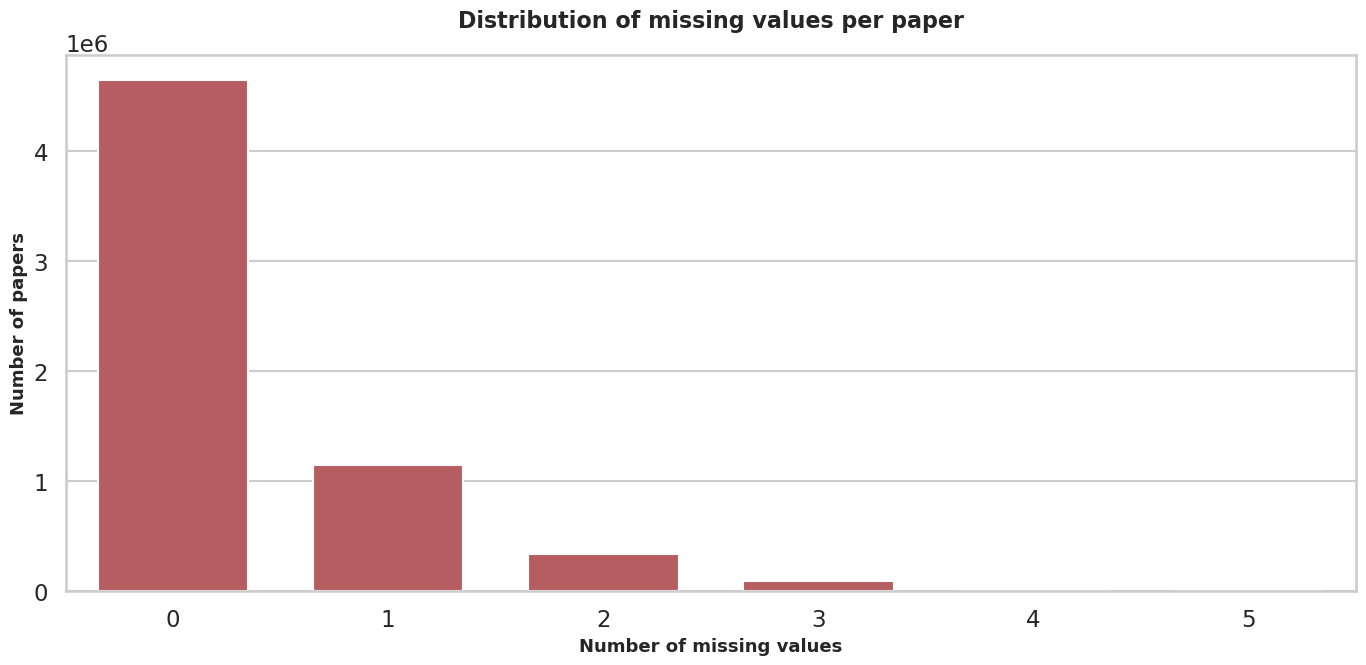

In [51]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=missing_counts_query, x="num_missing", y="count_papers", color="#C44E52", width=0.7)

plt.title("Distribution of missing values per paper", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of missing values", fontsize=13, fontweight='bold')
plt.ylabel("Number of papers", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Fix: use count_papers instead of count_rows
missing_counts_query["pct_papers"] = missing_counts_query["count_papers"] / missing_counts_query["count_papers"].sum() * 100

As we can see, the majority of papers have 0 or 1 missing value, totaling over 4 million records. Since papers with 2 or more missing values represent a small minority, we drop them to save space and reduce computation time, while still retaining most of the dataset.

In [52]:
con.execute("""
CREATE OR REPLACE VIEW papers_working AS
SELECT *
FROM (
    SELECT
        *,
        (
            CAST(flag_missing_title AS INTEGER) +
            CAST(flag_missing_abstract AS INTEGER) +
            CAST(flag_missing_lang AS INTEGER) +
            CAST(flag_missing_venue AS INTEGER) +
            CAST(flag_missing_doc_type AS INTEGER) +
            CAST(flag_missing_keywords AS INTEGER) +
            CAST(flag_missing_references AS INTEGER) +
            CAST(flag_missing_authors AS INTEGER) +
            CAST(flag_year_missing AS INTEGER)
        ) AS num_missing
    FROM papers_scope
) t
WHERE num_missing <= 1
""")

In [53]:
con.execute("""
SELECT
    COUNT(*) AS total_papers,
    SUM(CAST(flag_missing_title AS INTEGER)) AS missing_title,
    SUM(CAST(flag_missing_abstract AS INTEGER)) AS missing_abstract,
    SUM(CAST(flag_missing_doi AS INTEGER)) AS missing_doi,
    SUM(CAST(flag_missing_references AS INTEGER)) AS missing_references,
    SUM(CAST(flag_missing_authors AS INTEGER)) AS missing_authors,
    SUM(CAST(flag_year_missing AS INTEGER)) AS missing_year,
    SUM(CAST(flag_missing_lang AS INTEGER)) AS missing_lang,
    SUM(CAST(flag_missing_venue AS INTEGER)) AS missing_venue,
    SUM(CAST(flag_missing_doc_type AS INTEGER)) AS missing_doc_type
FROM papers_working
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_papers,missing_title,missing_abstract,missing_doi,missing_references,missing_authors,missing_year,missing_lang,missing_venue,missing_doc_type
0,5915577,0.0,11700.0,255678.0,477657.0,0.0,0.0,112147.0,19339.0,1040.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

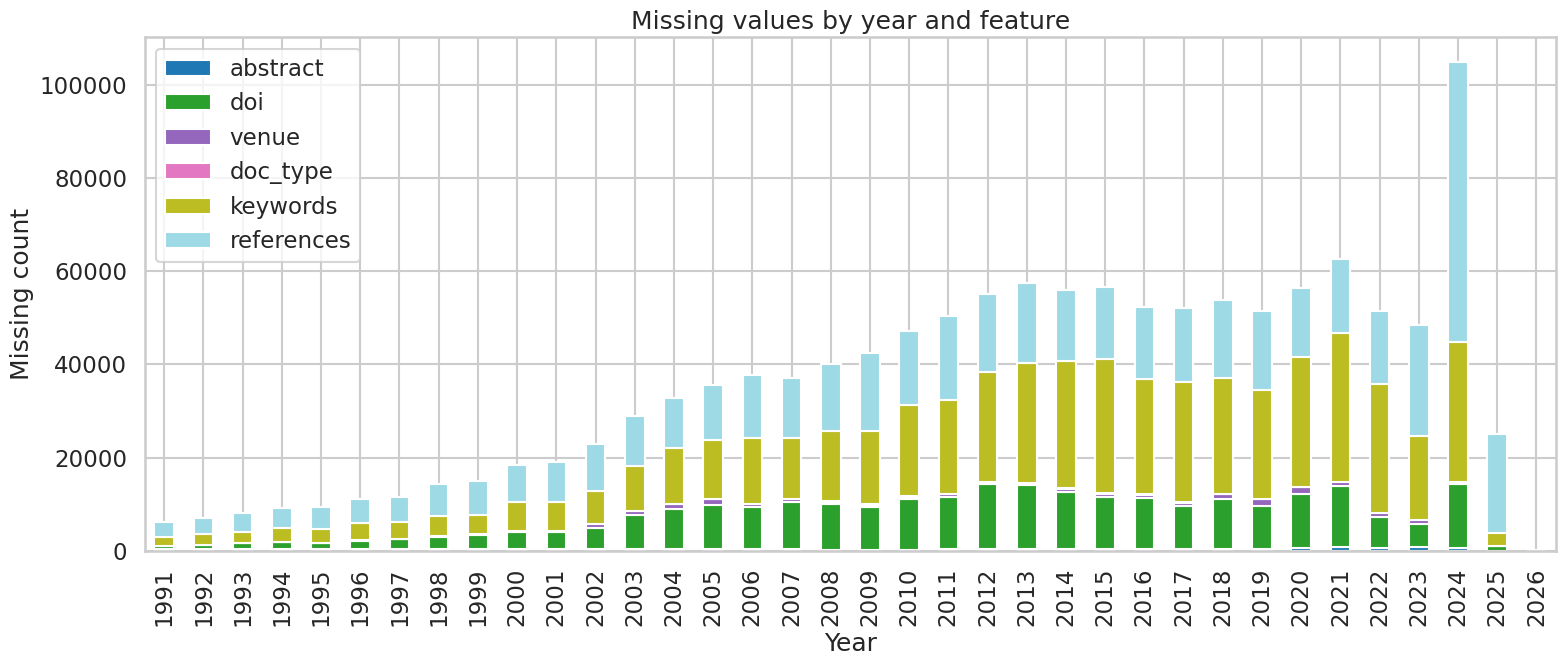

In [54]:
missing_by_year = con.execute("""
    SELECT
        year_int AS year,
        SUM(CAST(flag_missing_abstract AS INTEGER)) AS abstract,
        SUM(CAST(flag_missing_doi AS INTEGER)) AS doi,
        SUM(CAST(flag_missing_venue AS INTEGER)) AS venue,
        SUM(CAST(flag_missing_doc_type AS INTEGER)) AS doc_type,
        SUM(CAST(flag_missing_keywords AS INTEGER)) AS keywords,
        SUM(CAST(flag_missing_references AS INTEGER)) AS "references"
    FROM papers_working
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

missing_by_year = missing_by_year.set_index("year")

missing_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 7),
    colormap="tab20"
)

plt.title("Missing values by year and feature")
plt.xlabel("Year")
plt.ylabel("Missing count")
plt.tight_layout()
plt.show()

After the initial filtering we are left with about 5.9 million papers. The chart shows that keywords and references are the main sources of remaining missing values, distributed fairly uniformly across years with a natural growth trend. There are no suspicious patterns that would justify excluding any specific time period.

In [55]:
MAX_OPENALEX_CALLS = 90000

budget_df = con.execute("""
    SELECT
        COUNT(*) FILTER (WHERE flag_missing_abstract) AS n_missing_abstract,
        COUNT(*) FILTER (WHERE flag_missing_references) AS n_missing_references
    FROM papers_working
""").fetchdf()

n_missing_abstract = int(budget_df.loc[0, "n_missing_abstract"])
n_missing_references = int(budget_df.loc[0, "n_missing_references"])
ref_budget = max(0, MAX_OPENALEX_CALLS - n_missing_abstract)

print({
    "missing_abstract_all": n_missing_abstract,
    "missing_references_pool": n_missing_references,
    "reference_sample_budget": ref_budget
})


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

{'missing_abstract_all': 11700, 'missing_references_pool': 477657, 'reference_sample_budget': 78300}


We compute how many papers are missing an abstract or references, and allocate a call budget for the OpenAlex API. Since the total number of free API calls is capped at 90,000, we first use them to recover missing abstracts, and assign the remaining budget to references. 

In [56]:
# segment_summary = con.execute(f"""
# SELECT
#     paper_segment,
#     COUNT(*) AS n_papers,
#     SUM(CASE WHEN NOT flag_missing_abstract THEN 1 ELSE 0 END) AS has_abstract,
#     SUM(CASE WHEN NOT flag_missing_references THEN 1 ELSE 0 END) AS has_references,
#     SUM(CASE WHEN NOT flag_missing_doi THEN 1 ELSE 0 END) AS has_doi,
#     SUM(CASE WHEN COALESCE(array_length("references"), 0) >= {MIN_REFERENCES_RECOVERABLE} THEN 1 ELSE 0 END) AS refs_ge_threshold
# FROM papers_record_quality_preimputation
# GROUP BY 1
# """).fetchdf()

Since the reference imputation budget is limited, we distribute the available API calls proportionally across years, so that each year gets a quota proportional to how many papers with missing references it contains.

In [57]:
ref_year_counts = con.execute("""
    SELECT
        year_int AS year,
        COUNT(*) AS n_year
    FROM papers_working
    WHERE flag_missing_references
      AND NOT flag_missing_abstract
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

if len(ref_year_counts) > 0 and ref_budget > 0:
    ref_year_counts["quota_float"] = (
        ref_year_counts["n_year"] / ref_year_counts["n_year"].sum() * ref_budget
    )
    ref_year_counts["k"] = ref_year_counts["quota_float"].astype(int)

    remaining = ref_budget - int(ref_year_counts["k"].sum())
    if remaining > 0:
        ref_year_counts["frac"] = ref_year_counts["quota_float"] - ref_year_counts["k"]
        extra_idx = ref_year_counts.nlargest(remaining, "frac").index
        ref_year_counts.loc[extra_idx, "k"] += 1
else:
    ref_year_counts["quota_float"] = 0.0
    ref_year_counts["k"] = 0

ref_alloc = ref_year_counts[["year", "k"]].copy()

con.register("ref_alloc_df", ref_alloc)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

We then select the final set of paper IDs to work with. Papers that already have references are all kept, while papers with missing references are sampled according to the year quota computed above.

In [58]:
con.execute("""
CREATE OR REPLACE TABLE papers_final_ids AS
WITH ref_ranked AS (
    SELECT
        p.id,
        p.year_int,
        ROW_NUMBER() OVER (
            PARTITION BY p.year_int
            ORDER BY random()
        ) AS rn
    FROM papers_working p
    WHERE p.flag_missing_references
      AND NOT p.flag_missing_abstract
),
ref_sample AS (
    SELECT r.id
    FROM ref_ranked r
    JOIN ref_alloc_df a
      ON r.year_int = a.year
    WHERE r.rn <= a.k
)
SELECT p.id
FROM papers_working p
LEFT JOIN ref_sample s
  ON p.id = s.id
WHERE
    NOT p.flag_missing_references
    OR s.id IS NOT NULL
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [59]:
con.execute("""
CREATE OR REPLACE VIEW papers_final_original_filtered AS
SELECT p.*
FROM papers p
JOIN papers_final_ids f
  ON p.id = f.id
""")


We join the selected IDs back to the original papers table and export the final filtered dataset to a new Parquet file, which will be the starting point for the imputation phase.

In [60]:
output_path = "data/first_dataset.parquet"

if Path(output_path).exists() or Path("data/final_dataset.parquet").exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:
    con.execute(f"""
    COPY papers_final_original_filtered
    TO '{output_path}'
    (FORMAT PARQUET)
    """)

    print("saved:", output_path)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

saved: data/first_dataset.parquet


In [61]:
# pf = pq.ParquetFile(r"data/first_dataset.parquet")

# print(f"Total rows   : {pf.metadata.num_rows:,}")
# print(f"Columns      : {pf.metadata.num_columns}")
# print(f"Row groups   : {pf.metadata.num_row_groups}")

## 3. Dataset Imputation 

At this point we have completed an initial filtering pass, removing papers with poor data quality or too many missing values to be worth recovering. 
For the remaining missing values, we focus only on the features that we believe are relevant for predicting whether a paper cites another.

### 3.1. Abstract, References, Venue and Doc_Type Imputation

Our main imputation strategy relies on OpenAlex, an open bibliographic database that indexes hundreds of millions of scientific works and exposes a free API. Given a paper's DOI, we can query OpenAlex to retrieve missing abstracts, references, venue and doc_type. The process is time-consuming and not always successful, as not every DOI is indexed.

In [62]:
input_path = "data/first_dataset.parquet"
output_path = "data/middle_dataset.parquet"

if Path(output_path).exists() or Path("data/final_dataset.parquet").exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:
    pf = pq.ParquetFile(input_path)
    writer = None

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[openalex] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            impute_abstract_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_references_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_keywords_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_venue_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_doc_type_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

    print(f"saved: {output_path}")


[openalex] Row group 1/46
abstract: rows to inspect = 287
abstract: DOI not in cache = 287
  batches completed: 6/6

Imputation completed for abstract
Recovered: 61/287
Still missing: 226
references: rows to inspect = 1767
references: DOI not in cache = 1767
  batches completed: 10/36
  batches completed: 20/36
  batches completed: 30/36
  batches completed: 36/36

Imputation completed for references
Recovered: 1370/1767
Still missing: 397
keywords: rows to inspect = 9053
keywords: DOI not in cache = 9053
  batches completed: 10/182
  batches completed: 20/182
  batches completed: 30/182
  batches completed: 40/182
  batches completed: 50/182
  batches completed: 60/182
  batches completed: 70/182
  batches completed: 80/182
  batches completed: 90/182
  batches completed: 100/182
  batches completed: 110/182
  batches completed: 120/182
  batches completed: 130/182
  batches completed: 140/182
  batches completed: 150/182
  batches completed: 160/182
  batches completed: 170/182
  ba

In [63]:
# clean ram
for var_name in ["pf", "chunk", "table", "writer"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

382026

### 3.2. Lang and Authors imputation

For language, we detect it directly from the title and abstract text using a language detection library. For authors, we use a cross-referencing strategy: if an author is missing an id or organization in one paper, we look for the same author name in other papers and borrow the information from there, matching by name and year proximity.

In [194]:
input_path = "data/middle_dataset.parquet"
output_path = "data/final_dataset.parquet"

if Path(output_path).exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:

    name_to_year_ids, name_to_year_orgs = build_author_mappings(input_path)

    pf = pq.ParquetFile(input_path)
    writer = None

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[local imputation] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            missing_lang_mask = chunk["lang"].apply(is_empty)
            chunk.loc[missing_lang_mask, "lang"] = (
                chunk.loc[missing_lang_mask].apply(detect_lang, axis=1)
            )


            chunk = impute_authors_id_chunk(chunk, name_to_year_ids)
            chunk = impute_authors_org_chunk(chunk, name_to_year_orgs, max_year_diff=1)

            for col in ["authors", "keywords", "references", "url"]:
                if col in chunk.columns:
                    chunk[col] = chunk[col].apply(to_python_nested)

            chunk["authors"] = chunk["authors"].apply(normalize_authors_cell)

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

    print(f"saved: {output_path}")

already exists: data/final_dataset.parquet


In [195]:
# clean ram
for var_name in ["name_to_year_ids", "name_to_year_orgs", "pf", "chunk", "table", "writer"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

0

### 3.3. Analysis Post imputation

In [196]:
input_path = "data/final_dataset.parquet"
pf = pq.ParquetFile(input_path)

In [199]:
lang_counter = Counter()
n = 0

for rg in range(pf.num_row_groups):
    chunk = pf.read_row_group(rg, columns=["lang"]).to_pandas()

    for val in chunk["lang"]:
        key = "(null)" if is_empty(val) else val
        lang_counter[key] += 1

    n += len(chunk)

lang_counts = pd.Series(lang_counter).sort_values(ascending=False)

print(f"Unique values of 'lang' (sample of {n:,} rows):\n")
print(lang_counts)

Unique values of 'lang' (sample of 5,516,220 rows):

en        5502660
de           6923
fr           2485
pt           1340
zh           1339
es            913
it            120
tr             84
da             69
nl             39
ru             27
cs             25
pl             23
(null)         18
no             17
et             16
ro             16
sv             12
ca             12
gl             11
eu              9
fi              6
af              6
tl              4
nb              4
sk              4
sl              4
lt              4
id              3
nn              3
hu              3
mt              3
rw              2
cy              2
ko              2
az              2
lv              2
zh_cht          1
oc              1
la              1
vi              1
ja              1
uk              1
eo              1
el              1
dtype: int64


In [216]:
check_missing_column(pf, "abstract")

abstract summary (sample of 5,516,220 rows):

missing : 9,239
filled  : 5,506,981
missing %: 0.1675


In [217]:
check_missing_column(pf, "references")


references summary (sample of 5,516,220 rows):

missing : 18,123
filled  : 5,498,097
missing %: 0.3285


In [218]:
check_missing_column(pf, "keywords")

keywords summary (sample of 5,516,220 rows):

missing : 129,892
filled  : 5,386,328
missing %: 2.3547


In [219]:
check_missing_column(pf, "doc_type")

doc_type summary (sample of 5,516,220 rows):

missing : 57
filled  : 5,516,163
missing %: 0.0010


In [220]:
check_missing_column(pf, "venue")

venue summary (sample of 5,516,220 rows):

missing : 2,407
filled  : 5,513,813
missing %: 0.0436


In [221]:
missing_authors_id = 0
missing_authors_org = 0
total_authors = 0
papers_with_no_authors = 0

for rg in range(pf.num_row_groups):
    chunk = pf.read_row_group(rg, columns=["authors"]).to_pandas()

    for authors in chunk["authors"]:
        if not valid_authors_sequence(authors):
            papers_with_no_authors += 1
            continue

        for author in authors:
            if not isinstance(author, dict):
                continue

            total_authors += 1

            if is_empty(author.get("id")):
                missing_authors_id += 1

            if is_empty(author.get("org")):
                missing_authors_org += 1

print(f"Authors summary:\n")
print(f"total authors         : {total_authors:,}")
print(f"missing authors.id    : {missing_authors_id:,}")
print(f"missing authors.org   : {missing_authors_org:,}")
print(f"papers with no authors: {papers_with_no_authors:,}")

if total_authors > 0:
    print(f"missing authors.id %  : {missing_authors_id / total_authors * 100:.4f}")
    print(f"missing authors.org % : {missing_authors_org / total_authors * 100:.4f}")

Authors summary:

total authors         : 19,417,388
missing authors.id    : 846,944
missing authors.org   : 693,418
papers with no authors: 61,406
missing authors.id %  : 4.3618
missing authors.org % : 3.5711


We've imputed as much as possible; let's drop all the remaining missing values and work with the final dataset from now on

In [222]:
def drop_missing(input_path, output_path, required_cols):
    if Path(output_path).exists():
        print(f"already exists: {output_path}")
        return

    pf = pq.ParquetFile(input_path)
    writer = None
    kept_rows = 0
    dropped_rows = 0

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[filter] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            mask = pd.Series(True, index=chunk.index)

            for col in required_cols:
                mask &= ~chunk[col].apply(is_empty)

            # per authors: tieni solo paper con una lista autori valida e non vuota
            mask &= chunk["authors"].apply(valid_authors_sequence)

            kept_rows += int(mask.sum())
            dropped_rows += int((~mask).sum())

            chunk = chunk.loc[mask].copy()

            if len(chunk) == 0:
                continue

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

In [223]:
required_cols = [
    "id",
    "title",
    "abstract",
    "year",
    "lang",
    "keywords",
    "references",
    "doi",
    "venue",
    "doc_type",
]

drop_missing(
    input_path="data/final_dataset.parquet",
    output_path="data/dataset.parquet",
    required_cols=required_cols,
)


[filter] Row group 1/46

[filter] Row group 2/46

[filter] Row group 3/46

[filter] Row group 4/46

[filter] Row group 5/46

[filter] Row group 6/46

[filter] Row group 7/46

[filter] Row group 8/46

[filter] Row group 9/46

[filter] Row group 10/46

[filter] Row group 11/46

[filter] Row group 12/46

[filter] Row group 13/46

[filter] Row group 14/46

[filter] Row group 15/46

[filter] Row group 16/46

[filter] Row group 17/46

[filter] Row group 18/46

[filter] Row group 19/46

[filter] Row group 20/46

[filter] Row group 21/46

[filter] Row group 22/46

[filter] Row group 23/46

[filter] Row group 24/46

[filter] Row group 25/46

[filter] Row group 26/46

[filter] Row group 27/46

[filter] Row group 28/46

[filter] Row group 29/46

[filter] Row group 30/46

[filter] Row group 31/46

[filter] Row group 32/46

[filter] Row group 33/46

[filter] Row group 34/46

[filter] Row group 35/46

[filter] Row group 36/46

[filter] Row group 37/46

[filter] Row group 38/46

[filter] Row group 3

## 4. Data Visualization 


Now that we have the final imputed dataset, we take a step back before moving to feature engineering and modeling. This section gives us a visual overview of the dataset after all cleaning and imputation steps, to make sure the data looks reasonable and well distributed.

In [224]:
if Path("data/dataset_visualization.parquet").exists():
    df = pd.read_parquet("data/dataset_visualization.parquet")
else:
    pf = pq.ParquetFile("data/dataset.parquet")
    total_rows = pf.metadata.num_rows
    fraction = 50_000 / total_rows

    tmp_files = []
    for batch in pf.iter_batches(batch_size=100_000):
        df_batch = batch.to_pandas()
        del batch
        n = max(1, int(len(df_batch) * fraction))
        sample = df_batch.sample(n, random_state=42)
        del df_batch
        gc.collect()
        tmp = tempfile.NamedTemporaryFile(suffix=".parquet", delete=False)
        sample.to_parquet(tmp.name)
        tmp_files.append(tmp.name)

    df = pd.concat([pd.read_parquet(f) for f in tmp_files], ignore_index=True)
    for f in tmp_files:
        os.remove(f)
    
    df.to_parquet("data/dataset_visualization.parquet", index=False)

To avoid loading the full dataset into memory, we process it in batches, sample a fraction of each batch, write it to a temporary file, and then concatenate all samples at the end. The temporary files are deleted once the final dataframe is assembled.

### 4.1. Paper Distribution 

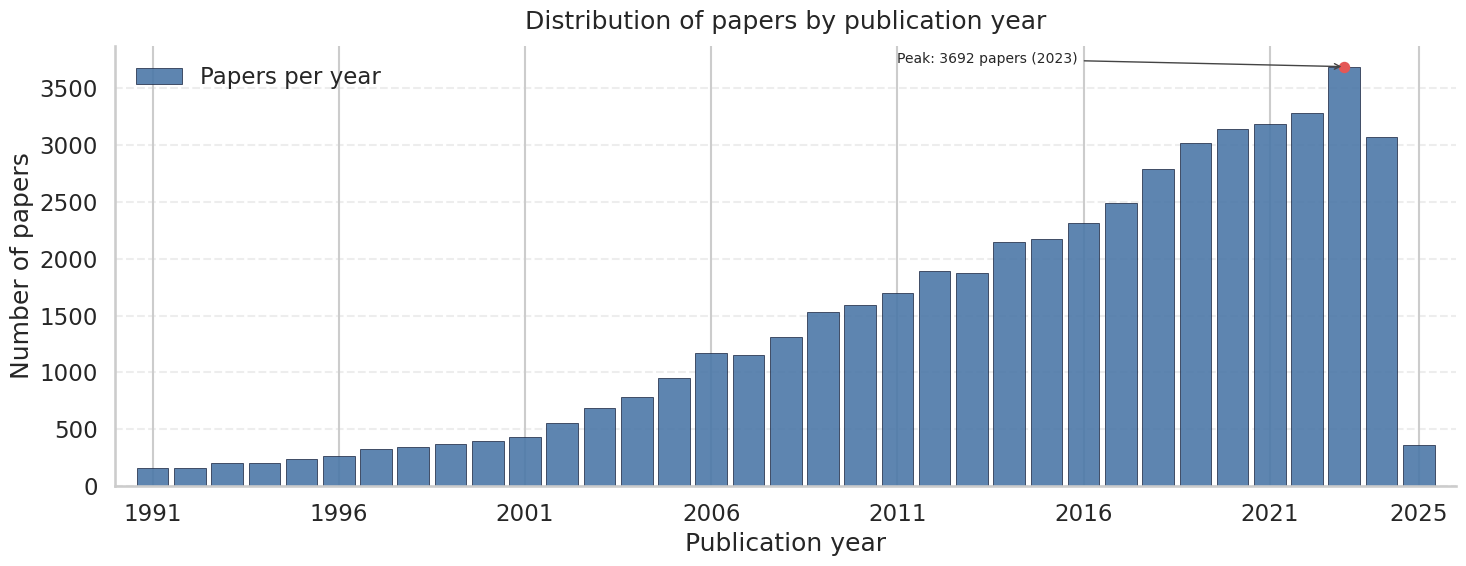

In [225]:
year_counts = (
    df["year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

year_counts = year_counts.reindex(
    range(year_counts.index.min(), year_counts.index.max() + 1),
    fill_value=0
)
rolling_avg = year_counts.rolling(window=5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(
    year_counts.index,
    year_counts.values,
    width=0.85,
    color="#4C78A8",
    edgecolor="#1F2A44",
    linewidth=0.6,
    alpha=0.9,
    label="Papers per year"
)

peak_year = int(year_counts.idxmax())
peak_value = int(year_counts.max())
ax.scatter([peak_year], [peak_value], color="#E45756", s=45, zorder=3)
ax.annotate(
    f"Peak: {peak_value} papers ({peak_year})",
    xy=(peak_year, peak_value),
    xytext=(peak_year - 12, peak_value + 35),
    arrowprops=dict(arrowstyle="->", color="#444444", lw=1),
    fontsize=10
)

tick_years = list(range(year_counts.index.min(), year_counts.index.max() + 1, 5))
if year_counts.index.max() not in tick_years:
    tick_years.append(year_counts.index.max())

ax.set_xticks(tick_years)
ax.set_xlim(year_counts.index.min() - 1, year_counts.index.max() + 1)
ax.set_title("Distribution of papers by publication year", pad=12)
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of papers")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The distribution of papers by year shows a steady growth over time, peaking in 2023. The drop in 2025 is expected since the dataset was collected before the end of that year. Overall the distribution looks healthy and consistent with what we observed before filtering.

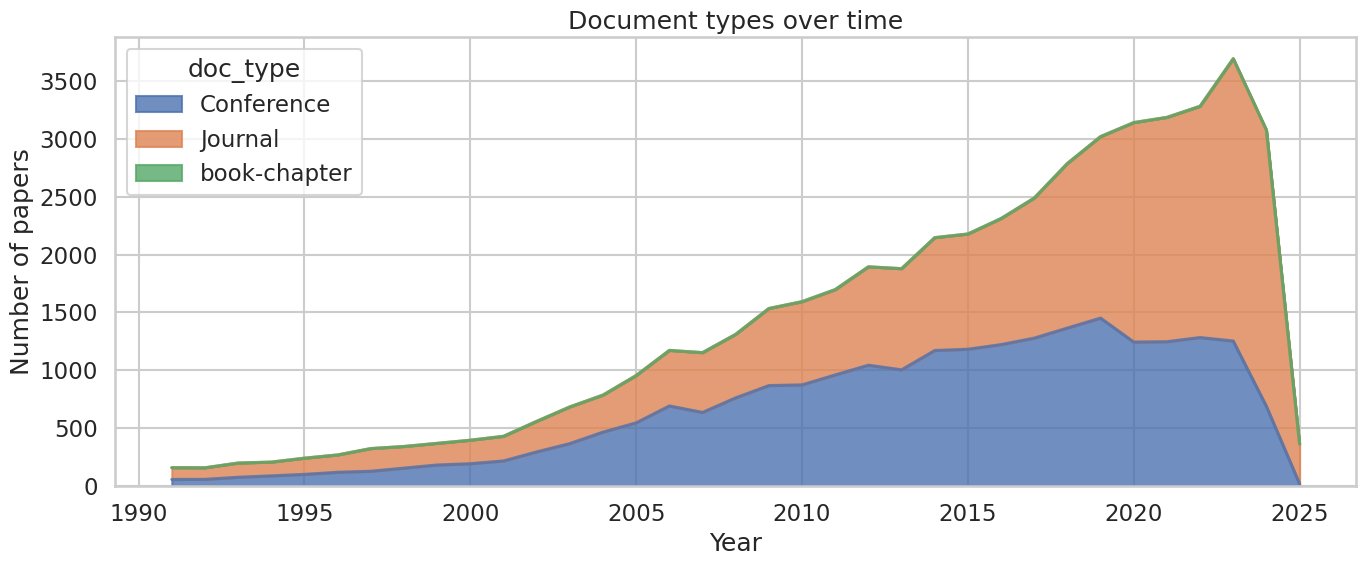

In [226]:
tmp = (
    df.dropna(subset=["year"])
      .assign(year=lambda x: x["year"].astype(int))
      .groupby(["year", "doc_type"])
      .size()
      .unstack(fill_value=0)
)

tmp.plot.area(figsize=(14, 6), alpha=0.8)
plt.title("Document types over time")
plt.xlabel("Year")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()


Breaking down the distribution by document type, we can see that the dataset is fairly balanced between conference and journal papers, with book-chapters representing a very small minority. This imbalance suggests that book-chapters could be dropped to keep the dataset cleaner.

In [ ]:
#sns.set_theme(style="whitegrid", context="talk")
#plt.rcParams["figure.figsize"] = (12, 5)

### 4.2. Feature Visualization 


#### 4.2.1. Numerical

In [227]:
numerical = [col for col in df.select_dtypes(include=[np.number]).columns]

In [228]:
def plot_distribution(feature_idx):
    feature = numerical[feature_idx]
    fig, ax = plt.subplots(figsize=(12, 6))
    
    data = df[feature].dropna()
    years = data.astype(int).value_counts().sort_index()
    ax.bar(years.index, years.values, color='steelblue', alpha=0.7, edgecolor='black', width=0.8)    
    mean = data.mean()
    median = data.median()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    std = data.std()
    min_val = data.min()
    max_val = data.max()
    
    ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.2f}')
    ax.axvline(q1, color='orange', linestyle=':', linewidth=2, label=f'Q1: {q1:.2f}')
    ax.axvline(q3, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3:.2f}')
    
    ax.set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    
    stats_text = f'Min: {min_val:.2f} | Max: {max_val:.2f} | Std: {std:.2f}\n\nMean: {mean:.2f}\nMedian: {median:.2f}\nQ1: {q1:.2f}\nQ3: {q3:.2f}'
    ax.text(0.99, 0.97, stats_text, transform=ax.transAxes, fontsize=10, 
            verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

feature_slider = widgets.IntSlider(min=0, max=len(numerical)-1, step=1, value=0)

widgets.interactive(plot_distribution, feature_idx=feature_slider)

interactive(children=(IntSlider(value=0, description='feature_idx', max=1), Output()), _dom_classes=('widget-i…

#### 4.2.2. Categorical

In [229]:
categorical = [col for col in df.columns if df[col].dtype == 'object' and not df[col].dropna().apply(lambda x: isinstance(x, (list, np.ndarray, dict))).any()]


for col in categorical:
    print(f"{col:30} {df[col].nunique():>6} unique values")

id                              49979 unique values
title                           49979 unique values
abstract                        49961 unique values
lang                               10 unique values
doi                             49979 unique values
venue                           17901 unique values
doc_type                            3 unique values


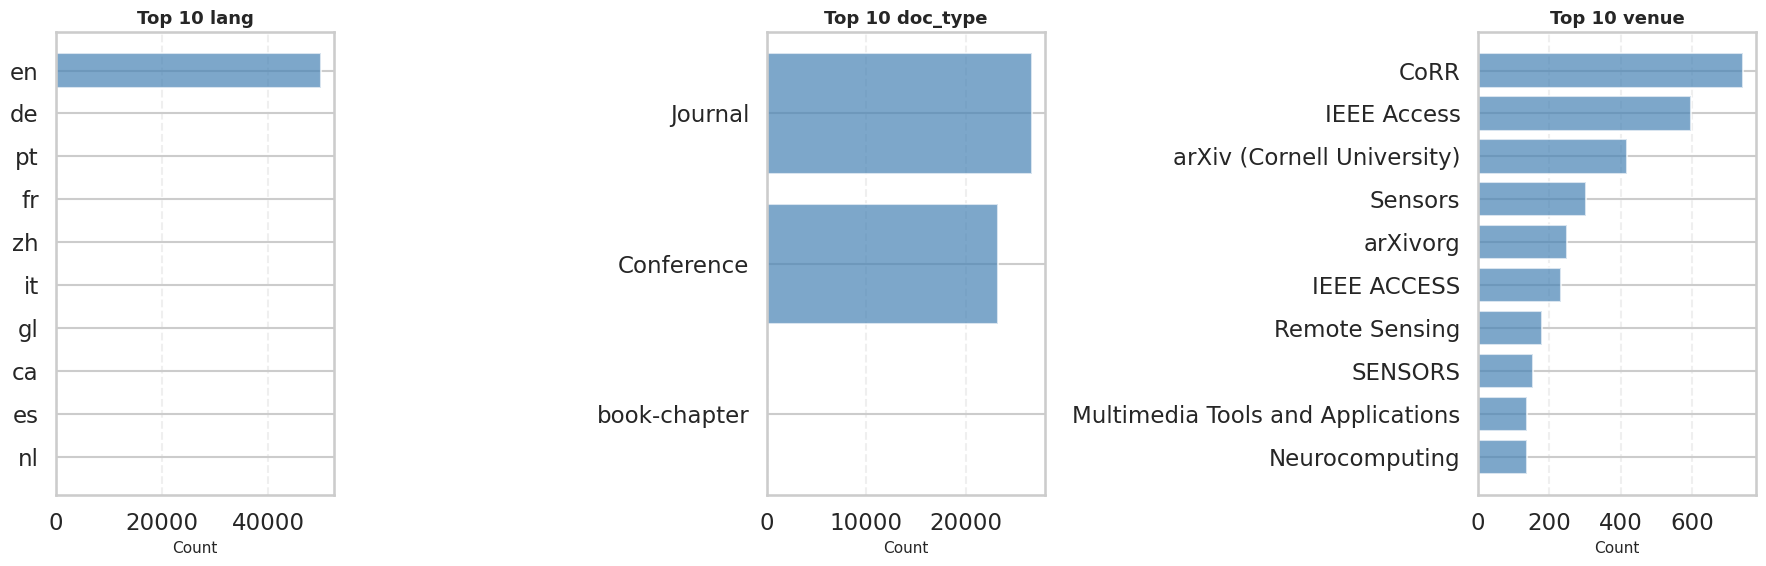

In [230]:
categorical_plot = ['lang', 'doc_type', 'venue']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, categorical_plot):
    top10 = df[col].value_counts().head(10)
    ax.barh(top10.index.astype(str)[::-1], top10.values[::-1], color='steelblue', alpha=0.7)
    ax.set_title(f'Top 10 {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Count', fontsize=11)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Looking at the three plots, language is heavily skewed towards English, which is expected for a scientific dataset. Document types are fairly balanced between journal and conference papers, with book-chapters being a small minority. For venue, CoRR dominates.CoRR is the Computing Research Repository, a preprint server hosted on arXiv where researchers share papers before formal publication. It is followed by IEEE Access and arXiv itself, though their counts are relatively small compared to the total dataset size, reflecting the high diversity of publication venues.


Looking at the venue plot, we can already spot a normalization issue: "IEEE Access" and "IEEE ACCESS" are clearly the same venue written in different cases, and the same applies to "Sensors" and "SENSORS". This confirms the importance of the normalization step we apply before feature extraction, where we lowercase and clean all text fields to avoid treating the same entity as multiple different ones.

### 4.3. First Similarity Check

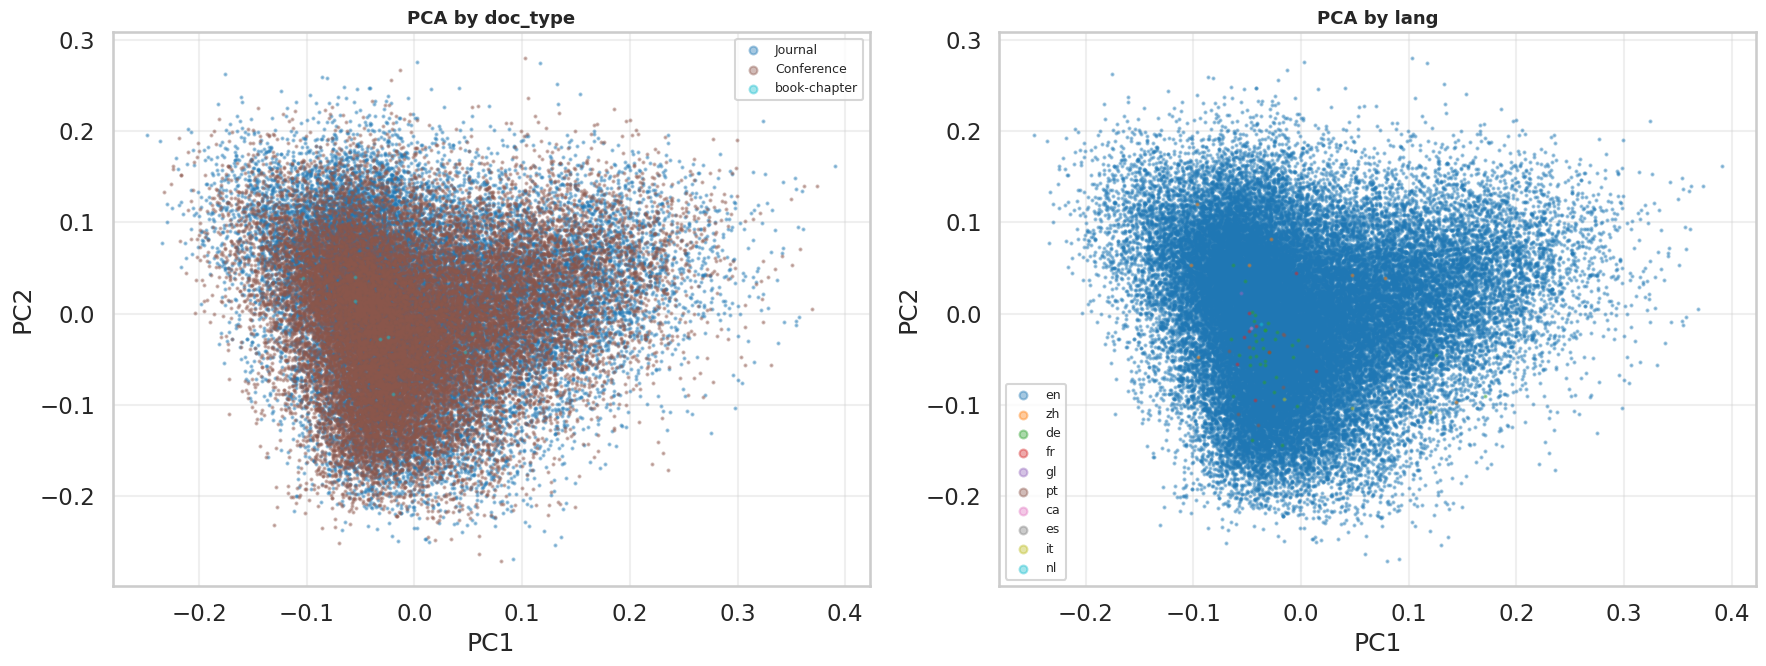

35263

In [231]:
text = (df["title"].fillna("") + " " + df["abstract"].fillna("")).fillna("")

vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X = vectorizer.fit_transform(text)
coords = PCA(n_components=2).fit_transform(X.toarray())

plot_df = df[["title", "year", "venue", "doc_type", "lang"]].copy()
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, col in zip(axes, ["doc_type", "lang"]):
    categories = plot_df[col].fillna("unknown").unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
    for cat, color in zip(categories, colors):
        mask = plot_df[col].fillna("unknown") == cat
        ax.scatter(plot_df.loc[mask, "x"], plot_df.loc[mask, "y"],
                   label=cat, color=color, s=2, alpha=0.4)
    ax.set_title(f"PCA by {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(markerscale=4, fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

del plot_df, X, coords, text, vectorizer
gc.collect()

Let's visualize now the similarity distribution between papers. This gives us an intuition of how separable the document space is and whether textual features alone carry enough signal for our prediction task.

In [232]:
model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")

text = (df["title"].fillna("") + " " + df["abstract"].fillna("")).tolist()

embeddings = model.encode(
    text,
    batch_size=512,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

np.save("data/embeddings_visualization.npy", embeddings)
print(f"Embeddings shape: {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/98 [00:00<?, ?it/s]

Embeddings shape: (49979, 384)


In [233]:
emb = torch.tensor(embeddings, device="cuda")
idx = np.random.choice(len(emb), size=5000, replace=False)
emb_sample = emb[idx]

sims = (emb_sample @ emb_sample.T).cpu().numpy()

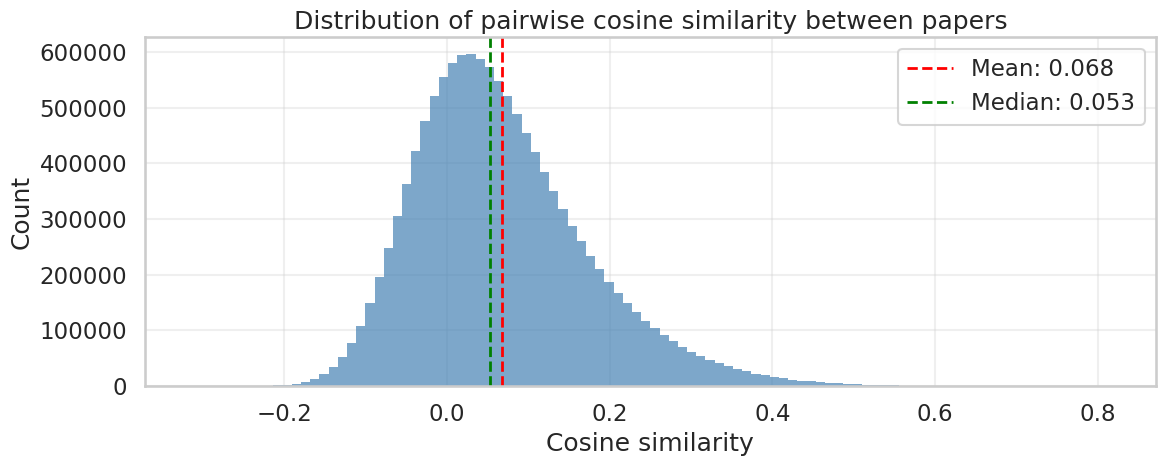

In [234]:
upper = sims[np.triu_indices(len(emb_sample), k=1)]

plt.figure(figsize=(12, 5))
plt.hist(upper, bins=100, color="steelblue", alpha=0.7, edgecolor="none")
plt.axvline(upper.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {upper.mean():.3f}")
plt.axvline(np.median(upper), color="green", linestyle="--", linewidth=2, label=f"Median: {np.median(upper):.3f}")
plt.title("Distribution of pairwise cosine similarity between papers")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [235]:
del emb, emb_sample, sims, upper
torch.cuda.empty_cache()
gc.collect()

8773

## 5. Dataset Split Train/Val/Test

We split the dataset chronologically by publication year, using a 70/15/15 ratio for train, validation, and test. Between each split we leave a one-year gap to prevent temporal leakage: this ensures the model never trains on papers published immediately before the validation or test periods. The gap simulates a realistic scenario where we predict future citations without seeing the most recent past.

In [5]:
# in memory variable and their dimension 
for var_name in dir():
    var = eval(var_name)
    try:
        size_mb = len(str(var)) / 1024 / 1024
        if size_mb > 10:  # mostra solo variabili > 10 MB
            print(f"{var_name}: {size_mb:.2f} MB")
    except:
        pass

In [6]:
SPLITS_EXIST = all(
    os.path.exists(f"data/{name}.parquet") 
    for name in ["train", "val", "test"]
)

if not SPLITS_EXIST:
    df_clean = pd.read_parquet("data/dataset.parquet")
    print("df_clean loaded")
else:
    print("Splits already exist, skipping dataset load.")

Splits already exist, skipping dataset load.


In [7]:
def split_timeseries_with_gaps(df, year_col, train_size=0.7, val_size=0.15):
    years = sorted(df[year_col].unique())
    n_total_rows = len(df)
    
    # Calcoliamo le righe cumulate per anno
    rows_per_year = df.groupby(year_col).size()
    cumulative_rows = rows_per_year.cumsum()
    
    train_threshold = n_total_rows * train_size
    val_threshold   = n_total_rows * (train_size + val_size)
    
    # Troviamo l'anno in cui superiamo le soglie
    train_end_year = cumulative_rows[cumulative_rows <= train_threshold].index.max()
    val_end_year   = cumulative_rows[cumulative_rows <= val_threshold].index.max()
    
    # Gap: escludiamo 1 anno dopo ogni split
    train_end_idx = years.index(train_end_year)
    val_start_idx = train_end_idx + 2   # +1 gap, +1 per lo start
    
    val_end_idx   = years.index(val_end_year)
    test_start_idx = val_end_idx + 2
    
    years_train = years[:train_end_idx + 1]
    years_val   = years[val_start_idx : val_end_idx + 1]
    years_test  = years[test_start_idx:]
    
    train = df[df[year_col].isin(years_train)].copy()
    val   = df[df[year_col].isin(years_val)].copy()
    test  = df[df[year_col].isin(years_test)].copy()
    
    # Report
    print(f"Train: {len(train):>7} righe ({len(train)/n_total_rows:.1%}) | anni {years_train[0]}–{years_train[-1]}")
    print(f"Gap:   {years[train_end_idx+1]}")
    print(f"Val:   {len(val):>7} righe ({len(val)/n_total_rows:.1%})   | anni {years_val[0]}–{years_val[-1]}")
    print(f"Gap:   {years[val_end_idx+1]}")
    print(f"Test:  {len(test):>7} righe ({len(test)/n_total_rows:.1%})  | anni {years_test[0]}–{years_test[-1]}")
    
    return train, val, test, (years_train, years_val, years_test)

if not SPLITS_EXIST:
    df_train, df_val, df_test, periods = split_timeseries_with_gaps(df_clean, 'year')

    print(f"Train years: {periods[0]}")
    print(f"Val years:   {periods[1]}")
    print(f"Test years:  {periods[2]}")

    del df_clean
    gc.collect()
else:
    print("Splits already exist, skipping.")
gc.collect()

Splits already exist, skipping.


1635

In [8]:
if not SPLITS_EXIST:
    splits = {"train": df_train, "val": df_val, "test": df_test}

    for name, df in splits.items():
        file_path = os.path.join("data", f"{name}.parquet")
        df.to_parquet(file_path, engine='pyarrow', index=False)
        print(f"Saved: {file_path} | Rows: {len(df)}")
else:
    print("Files already saved, skipping.")

Files already saved, skipping.


## 6. Data Quality and Normalization

In this step we normalize text fields (title, abstract), DOI, venue, doc_type, and author names. We also create data quality flags and highlight inconsistencies that are useful for the downstream prediction task.

### 6.1. Text Normalization Functions


In [9]:
MIN_REASONABLE_YEAR = 1950

ZERO_WIDTH_PATTERN = re.compile(r"[\u200b-\u200d\ufeff]")
MULTISPACE_PATTERN = re.compile(r"\s+")
PUNCT_TO_SPACE_PATTERN = re.compile(r"[^a-z0-9]+")


def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    return []

def clean_string(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x).strip()

def normalize_text(x, lowercase=True):
    text = clean_string(x)
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text.lower() if lowercase else text

def strip_accents(x):
    text = normalize_text(x, lowercase=True)
    if not text:
        return ""
    decomposed = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))

def normalize_for_key(x):
    text = strip_accents(x)
    text = PUNCT_TO_SPACE_PATTERN.sub(" ", text)
    return MULTISPACE_PATTERN.sub(" ", text).strip()

def normalize_author_name(x):
    name = normalize_text(x, lowercase=False)
    if not name:
        return ""

    if "," in name:
        left, right = [part.strip() for part in name.split(",", 1)]
        if left and right:
            name = f"{right} {left}"

    name = normalize_text(name, lowercase=True)
    name = re.sub(r"[.'`]", "", name)
    name = re.sub(r"[^a-z0-9\s\-]", " ", strip_accents(name))
    return MULTISPACE_PATTERN.sub(" ", name).strip()

def contains_non_ascii(text):
    return any(ord(ch) > 127 for ch in text)


In [10]:
def extract_author_features(authors):
    authors = ensure_list(authors)

    author_names_norm = []
    author_ids_clean = []
    author_orgs_clean = []

    for author in authors:
        if not isinstance(author, dict):
            continue

        norm_name = normalize_author_name(author.get("name"))
        author_id = normalize_text(author.get("id"), lowercase=False)
        author_org = normalize_text(author.get("org"), lowercase=False)

        if norm_name:
            author_names_norm.append(norm_name)
        if author_id:
            author_ids_clean.append(author_id)
        if author_org:
            author_orgs_clean.append(author_org)

    return pd.Series({
        "author_names_norm": list(dict.fromkeys(author_names_norm)),
        "author_ids_clean": list(dict.fromkeys(author_ids_clean)),
        "author_orgs_clean": list(dict.fromkeys(author_orgs_clean)),
        "n_authors": len(author_names_norm),
    })

### 6.2. Normalization Pipeline

In [11]:
for split in ["train", "val", "test"]:
    in_path = f"data/{split}.parquet"
    out_path = f"data/{split}_normalized.parquet"

    normalized_schema = (
        pq.ParquetFile(out_path).schema_arrow.names
        if os.path.exists(out_path)
        else []
    )
    normalized_is_current = {
        "author_ids_clean",
        "author_orgs_clean",
    }.issubset(normalized_schema)
    if normalized_is_current:
        print(f"[{split}] already exists, skipping")
        continue
    if os.path.exists(out_path):
        print(f"[{split}] normalized file is missing causal feature support, rebuilding")
        Path(out_path).unlink(missing_ok=True)

    chunk_size = 200_000
    writer = None

    parquet_file = pq.ParquetFile(in_path)
    total_rows = parquet_file.metadata.num_rows
    processed = 0

    input_cols = [
        "id",
        "title",
        "abstract",
        "keywords",
        "year",
        "authors",
        "references",
        "lang",
        "venue",
        "doc_type",
    ]

    for batch in parquet_file.iter_batches(
        batch_size=chunk_size,
        columns=input_cols,
    ):
        chunk = batch.to_pandas()

        chunk["title_norm"] = chunk["title"].apply(normalize_for_key)
        chunk["abstract_norm"] = chunk["abstract"].apply(normalize_for_key)
        chunk["venue_norm"] = chunk["venue"].apply(normalize_for_key)

        chunk["keywords_norm"] = chunk["keywords"].apply(
            lambda xs: list(
                dict.fromkeys(
                    norm
                    for x in ensure_list(xs)
                    for norm in [normalize_for_key(x)]
                    if norm
                )
            )
        )

        chunk["n_keywords"] = chunk["keywords_norm"].apply(len)
        chunk["n_references"] = chunk["references"].apply(lambda x: len(ensure_list(x)))

        author_features = chunk["authors"].apply(extract_author_features)
        for col in author_features.columns:
            chunk[col] = author_features[col].values
        del author_features

        final_cols = [
            "id",
            "references",

            "title",
            "abstract",
            "title_norm",
            "abstract_norm",

            "year",
            "doc_type",
            "lang",

            "venue_norm",
            "keywords_norm",

            "n_keywords",
            "n_references",

            "authors",
            "author_names_norm",
            "author_ids_clean",
            "author_orgs_clean",
            "n_authors",
        ]

        chunk = chunk[final_cols]

        table = pa.Table.from_pandas(chunk, preserve_index=False)

        if writer is None:
            writer = pq.ParquetWriter(out_path, table.schema, compression="snappy")

        writer.write_table(table)
        processed += len(chunk)
        print(f"  [{split}] {processed:,} / {total_rows:,}")

        del chunk, table

    if writer:
        writer.close()

    print(f"[{split}] saved — {processed:,} rows")

  [train] 200,000 / 3,451,689
  [train] 400,000 / 3,451,689
  [train] 600,000 / 3,451,689
  [train] 800,000 / 3,451,689
  [train] 1,000,000 / 3,451,689
  [train] 1,200,000 / 3,451,689
  [train] 1,400,000 / 3,451,689
  [train] 1,600,000 / 3,451,689
  [train] 1,800,000 / 3,451,689
  [train] 2,000,000 / 3,451,689
  [train] 2,200,000 / 3,451,689
  [train] 2,400,000 / 3,451,689
  [train] 2,600,000 / 3,451,689
  [train] 2,800,000 / 3,451,689
  [train] 3,000,000 / 3,451,689
  [train] 3,200,000 / 3,451,689
  [train] 3,400,000 / 3,451,689
  [train] 3,451,689 / 3,451,689
[train] saved — 3,451,689 rows
  [val] 200,000 / 335,266
  [val] 335,266 / 335,266
[val] saved — 335,266 rows
  [test] 200,000 / 737,608
  [test] 400,000 / 737,608
  [test] 600,000 / 737,608
  [test] 737,608 / 737,608
[test] saved — 737,608 rows


### 6.3. Normalization Preview and Author Alias Analysis

In [12]:
cols_preview = [
    "title_norm",
    "venue_norm",
    "abstract_norm",
    "doc_type",
    "lang",
    "author_names_norm",
    "n_authors"
]
df_preview = pd.read_parquet("data/train_normalized.parquet", columns=cols_preview)
display(df_preview.head(10))
del df_preview

,title_norm,venue_norm,abstract_norm,doc_type,lang,author_names_norm,n_authors
0,simplified voronoi diagrams,latest advances in robot kinematics,we are interested in voronoi diagrams as a too...,Conference,en,"[ruben vaca, joan aranda, federico thomas]",3
1,a characterization of eventual byzantine agree...,siam journal on computing,we investigate eventual byzantine agreement eb...,Conference,en,"[jy halpern, y moses, o waarts]",3
2,2 symmetric crystallizations and 2 fold branch...,discrete mathematics,for each integer g 1 a class m g of 2 symmetri...,Journal,en,"[maria rita casali, luigi grasselli]",2
3,image gathering and digital restoration for fi...,cvgip graphical models and image processing,the fidelity and resolution of the traditional...,Journal,en,"[fo huck, r altergartenberg, zu rahman]",3
4,unilateral approximation of gibbs random field...,cvgip graphical models and image processing,the relationship between a general gibbs rando...,Journal,en,[j goutsias],1
5,an experimental investigation of distributed m...,software practice and experience,this paper discusses the development and refin...,Journal,en,"[sa rees, jp black]",2
6,qualitative physics towards the automation of ...,journal of experimental theoretical artificial...,key concepts and goals in the areas connected ...,Journal,en,"[paul a fishwick, bernard p zeigler]",2
7,probabilistic ctss analysis of timing error pr...,28th acm ieee design automation conference,article probabilistic ctss analysis of timing ...,Conference,en,"[y deguchi, n ishiura, s yajima]",3
8,improved approximation algorithms for shop sch...,acm siam symposium on discrete algorithms,in the job shop scheduling problem there are m...,Conference,en,"[db shmoys, c stein, j wein]",3
9,coordinator support in a nemawashi decision pr...,decision support systems,there is a growing body of literature concerne...,Journal,en,"[k watabe, cw holsapple, ab whinston]",3


In [13]:
df_preview = pd.read_parquet("data/train_normalized.parquet", columns=["authors"])

author_alias_rows = []
for _, row in df_preview.iterrows():
    for author in ensure_list(row["authors"]):
        if not isinstance(author, dict):
            continue

        raw_name = normalize_text(author.get("name"), lowercase=False)
        norm_name = normalize_author_name(author.get("name"))

        if raw_name and norm_name:
            author_alias_rows.append({
                "author_norm": norm_name,
                "author_raw": raw_name,
            })

del df_preview

author_alias_df = pd.DataFrame(author_alias_rows)

author_alias_summary = (
    author_alias_df.groupby("author_norm")
    .agg(
        n_variants=("author_raw", "nunique"),
        examples=("author_raw", lambda x: " | ".join(sorted(set(list(x)[:10]))[:5]))
    )
    .reset_index()
    .sort_values(["n_variants", "author_norm"], ascending=[False, True])
)

author_alias_summary = author_alias_summary[author_alias_summary["n_variants"] > 1]
display(author_alias_summary.head(20))
del author_alias_df


,author_norm,n_variants,examples
1077488,jose del r millan,9,Jose del R. Millan | José Del R. Millán | José...
97318,alex sandy pentland,8,Alex 'Sandy' Pentland | Alex (Sandy) Pentland ...
1399162,maria jose del jesus,8,Maria Jose del Jesus | María José del Jesus | ...
1808095,ramon lopez de mantaras,8,Ramon Lopez de Mantaras | Ramon López De Mànta...
530004,dong-il dan cho,7,Dong-Il Dan Cho | Dong-il 'Dan' Cho | Dong-il ...
567213,ef camacho,7,"Camacho, E.F. | E.F. Camacho | EF CAMACHO | EF..."
641296,fatemeh mariam zahedi,7,Fatemeh ''Mariam'' Zahedi | Fatemeh 'Mariam' Z...
935191,j sanchez,7,J Sanchez | J Sánchez | J. Sánchez
1076899,jose c principe,7,Jose C. Principe | José C. Príncipe
1321668,m de la sen,7,M De La Sen | M De la Sen | M de la Sen | M. D...


In [14]:
target_raw = "Sandra Mitrovic"
target_norm = normalize_author_name(target_raw)

target_norm

'sandra mitrovic'

In [15]:
matches = author_alias_summary[
    author_alias_summary["author_norm"] == target_norm
]

display(matches[["author_norm", "n_variants", "examples"]])
print("N matches:", len(matches))


,author_norm,n_variants,examples
1942413,sandra mitrovic,2,Sandra Mitrovic | Sandra Mitrović


N matches: 1


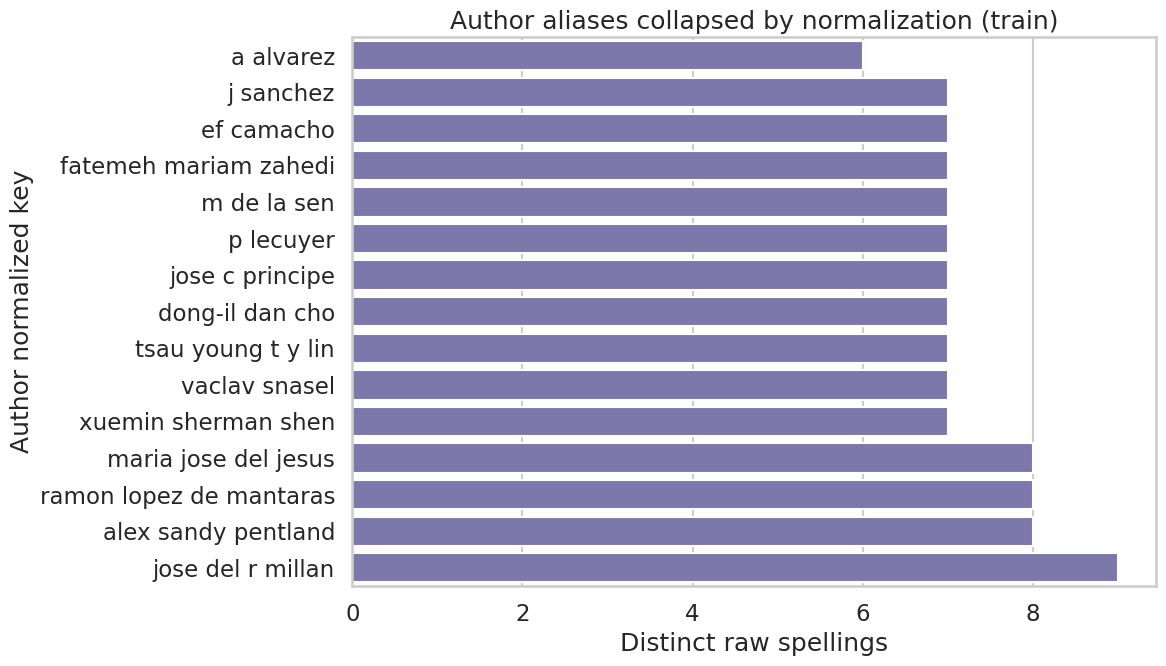

In [16]:
top_author_alias = author_alias_summary.head(15).sort_values("n_variants", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_author_alias, x="n_variants", y="author_norm", color="#7570B3")
plt.title("Author aliases collapsed by normalization (train)")
plt.xlabel("Distinct raw spellings")
plt.ylabel("Author normalized key")
plt.tight_layout()
plt.show()


In [17]:
del author_alias_rows
del matches
del batch
del row
del author
del writer
del parquet_file

gc.collect()

163

In [18]:
pa.default_memory_pool().release_unused()

## 7. Graph

We build a directed citation graph from the training set, where each edge represents a citation from one paper to another. Using cuGraph on GPU, we compute centrality measures (in-degree, out-degree, PageRank, betweenness centrality) and analyze the connected component structure. These graph features capture each paper's structural importance in the citation network and will be used as predictive features in the classification model.

In [22]:
TRAIN_PATH = "data/train_normalized.parquet"
CENTRALITY_OUTPUT = "data/train_centrality.parquet"
GRAPH_STATS_OUTPUT = "data/graph_stats.parquet"

### 7.1. Edge List Construction

In [23]:
# Load only id and references columns to save RAM
t0 = time.time()
df_refs = pd.read_parquet(TRAIN_PATH, columns=["id", "references"])
print(f"Loaded {len(df_refs):,} train papers in {time.time()-t0:.1f}s")

valid_ids = set(df_refs["id"].values)
print(f"Valid IDs: {len(valid_ids):,}")

Loaded 3,451,689 train papers in 5.9s
Valid IDs: 3,451,689


In [24]:
# Build edge list from references (only edges where both papers are in train)
t0 = time.time()
edges = []

for _, row in df_refs.iterrows():
    source = row["id"]
    refs = row["references"]

    if not isinstance(refs, (list, np.ndarray)) or len(refs) == 0:
        continue

    for ref in refs:
        ref_str = str(ref).strip()
        if ref_str in valid_ids and ref_str != source:
            edges.append((source, ref_str))

print(f"Edge list built in {time.time()-t0:.1f}s")
print(f"Total edges: {len(edges):,}")

# Free df_refs, we only need edges now
del df_refs
gc.collect()

# Create edge DataFrame
edges_df = pd.DataFrame(edges, columns=["src", "dst"])
del edges
print(f"Edge DataFrame shape: {edges_df.shape}")

Edge list built in 74.8s
Total edges: 32,411,600
Edge DataFrame shape: (32411600, 2)


### 7.2. Graph Construction (cuGraph)

In [25]:
# cuGraph needs integer node IDs, so we create a mapping
all_nodes = list(valid_ids)
node_to_int = {node: i for i, node in enumerate(all_nodes)}
int_to_node = {i: node for node, i in node_to_int.items()}

# Map string IDs to integers
edges_df["src_int"] = edges_df["src"].map(node_to_int)
edges_df["dst_int"] = edges_df["dst"].map(node_to_int)

# Drop string columns to save memory
edges_int = edges_df[["src_int", "dst_int"]].rename(
    columns={"src_int": "src", "dst_int": "dst"}
)
edges_str = edges_df[["src", "dst"]]
del edges_df

print(f"Nodes: {len(all_nodes):,}")
print(f"Edges: {len(edges_int):,}")

Nodes: 3,451,689
Edges: 32,411,600


In [26]:
t0 = time.time()

# Convert to cuDF DataFrame (moves data to GPU)
edges_cudf = cudf.DataFrame(edges_int)
del edges_int

# Create directed graph
G = cugraph.Graph(directed=True)
G.from_cudf_edgelist(edges_cudf, source="src", destination="dst")

print(f"cuGraph graph built in {time.time()-t0:.1f}s")
print(f"  Nodes: {G.number_of_vertices():,}")
print(f"  Edges: {G.number_of_edges():,}")
print(f"  Density: {G.number_of_edges() / (G.number_of_vertices() * (G.number_of_vertices()-1)):.8f}")

del edges_cudf
gc.collect()

cuGraph graph built in 0.7s
  Nodes: 3,377,161
  Edges: 32,411,600
  Density: 0.00000284


0

### 7.3. Connected Components Analysis

In [27]:
t0 = time.time()

# Weakly connected components (cuGraph needs undirected for WCC)
G_undirected = G.to_undirected()
wcc_df = cugraph.weakly_connected_components(G_undirected)
del G_undirected

# Analyze components
comp_sizes = wcc_df.groupby("labels").size().reset_index(name="size")
comp_sizes = comp_sizes.sort_values("size", ascending=False).reset_index(drop=True)

# Convert to pandas for analysis
comp_sizes_pd = comp_sizes.to_pandas() if hasattr(comp_sizes, 'to_pandas') else comp_sizes

n_components = len(comp_sizes_pd)
largest = comp_sizes_pd.iloc[0]["size"]
total_nodes = comp_sizes_pd["size"].sum()

print(f"Connected components analysis ({time.time()-t0:.1f}s):")
print(f"  Total components: {n_components:,}")
print(f"  Largest component: {largest:,} nodes ({largest/total_nodes*100:.1f}%)")
if n_components > 1:
    print(f"  2nd largest: {comp_sizes_pd.iloc[1]['size']:,} nodes")

# Size breakdown
isolated = (comp_sizes_pd["size"] == 1).sum()
small = ((comp_sizes_pd["size"] > 1) & (comp_sizes_pd["size"] <= 10)).sum()
medium = ((comp_sizes_pd["size"] > 10) & (comp_sizes_pd["size"] <= 100)).sum()
large = (comp_sizes_pd["size"] > 100).sum()

print(f"\n  Isolated (size=1): {isolated:,}")
print(f"  Small (2-10):      {small:,}")
print(f"  Medium (11-100):   {medium:,}")
print(f"  Large (>100):      {large:,}")

Connected components analysis (1.8s):
  Total components: 4,548
  Largest component: 3,366,459 nodes (99.7%)
  2nd largest: 18 nodes

  Isolated (size=1): 0
  Small (2-10):      4,540
  Medium (11-100):   7
  Large (>100):      1


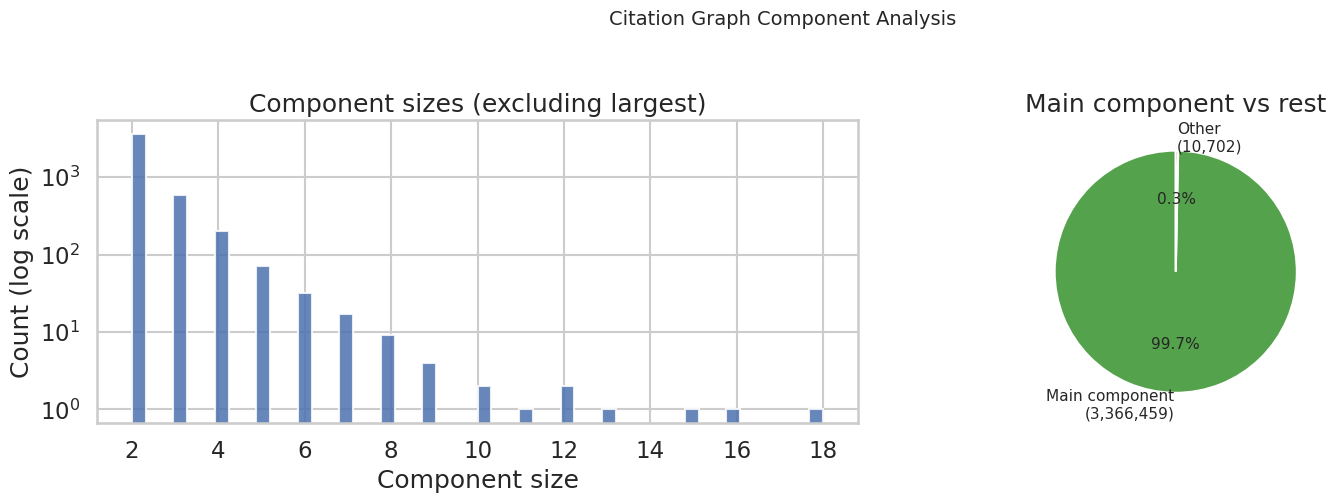

In [28]:
#sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of component sizes (excluding largest)
small_comps = comp_sizes_pd[comp_sizes_pd["size"] < largest]["size"].values
if len(small_comps) > 0:
    axes[0].hist(small_comps, bins=50, color="#4C72B0", alpha=0.85, log=True)
    axes[0].set_title("Component sizes (excluding largest)")
    axes[0].set_xlabel("Component size")
    axes[0].set_ylabel("Count (log scale)")
else:
    axes[0].text(0.5, 0.5, "Only one component", ha="center", va="center", fontsize=14)
    axes[0].set_title("Component sizes (excluding largest)")

# Right: pie chart
rest = total_nodes - largest
axes[1].pie(
    [largest, rest],
    labels=[f"Main component\n({int(largest):,})", f"Other\n({int(rest):,})"],
    colors=["#54A24B", "#E45756"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11}
)
axes[1].set_title("Main component vs rest")

plt.suptitle("Citation Graph Component Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 7.4. Centrality Measures


In [29]:
print("Computing centrality measures on GPU...\n")

# ── In-degree & Out-degree
print("In-degree & Out-degree...")
t0 = time.time()
in_degree = G.in_degree()
out_degree = G.out_degree()

# Convert to pandas
in_deg_pd = in_degree.to_pandas() if hasattr(in_degree, 'to_pandas') else in_degree
out_deg_pd = out_degree.to_pandas() if hasattr(out_degree, 'to_pandas') else out_degree

in_deg_dict = dict(zip(in_deg_pd["vertex"], in_deg_pd["degree"]))
out_deg_dict = dict(zip(out_deg_pd["vertex"], out_deg_pd["degree"]))
print(f"  Done in {time.time()-t0:.1f}s")
del in_degree, out_degree, in_deg_pd, out_deg_pd

# ── PageRank
print("PageRank...")
t0 = time.time()
pagerank_df = cugraph.pagerank(G, alpha=0.85, max_iter=100, tol=1e-06)

pr_pd = pagerank_df.to_pandas() if hasattr(pagerank_df, 'to_pandas') else pagerank_df
pr_dict = dict(zip(pr_pd["vertex"], pr_pd["pagerank"]))
print(f"  Done in {time.time()-t0:.1f}s")
del pagerank_df, pr_pd

# ── Betweenness Centrality
n_vertices = G.number_of_vertices()
k_betweenness = min(5000, n_vertices)
print(f"Betweenness centrality (k={k_betweenness:,})...")
t0 = time.time()
bc_df = cugraph.betweenness_centrality(G, k=k_betweenness, normalized=True, seed=42)

bc_pd = bc_df.to_pandas() if hasattr(bc_df, 'to_pandas') else bc_df
bc_dict = dict(zip(bc_pd["vertex"], bc_pd["betweenness_centrality"]))
print(f"  Done in {time.time()-t0:.1f}s")
del bc_df, bc_pd

print("\nAll centrality measures computed!")

# Free GPU memory
del G
gc.collect()

Computing centrality measures on GPU...

In-degree & Out-degree...
  Done in 0.8s
PageRank...
  Done in 0.7s
Betweenness centrality (k=5,000)...
  Done in 186.8s

All centrality measures computed!


2579

### 7.5. Centrality Export and Visualization

In [30]:
# Build centrality for each paper (map int IDs back to string IDs)
centrality_rows = []

for node_str in all_nodes:
    node_int = node_to_int[node_str]
    centrality_rows.append({
        "id": node_str,
        "in_degree": in_deg_dict.get(node_int, 0),
        "out_degree": out_deg_dict.get(node_int, 0),
        "pagerank": pr_dict.get(node_int, 0.0),
        "betweenness": bc_dict.get(node_int, 0.0),
    })

centrality_df = pd.DataFrame(centrality_rows)
del centrality_rows, in_deg_dict, out_deg_dict, pr_dict, bc_dict

print(f"Centrality DataFrame shape: {centrality_df.shape}")
display(centrality_df.describe().round(6))

# Save
centrality_df.to_parquet(CENTRALITY_OUTPUT, index=False)
print(f"\nCentrality saved to {CENTRALITY_OUTPUT}")
print(f"Size: {Path(CENTRALITY_OUTPUT).stat().st_size / 1024**2:.1f} MB")

Centrality DataFrame shape: (3451689, 5)


,in_degree,out_degree,pagerank,betweenness
count,3.451689e+06,3.451689e+06,3.451689e+06,3.451689e+06
mean,9.390070e+00,9.390070e+00,0.000000e+00,0.000000e+00
std,5.400405e+01,1.049477e+01,3.000000e-06,0.000000e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,7.000000e+00,0.000000e+00,0.000000e+00
75%,7.000000e+00,1.300000e+01,0.000000e+00,0.000000e+00
max,2.275800e+04,1.565000e+03,1.678000e-03,8.200000e-05



Centrality saved to data/train_centrality.parquet
Size: 78.0 MB


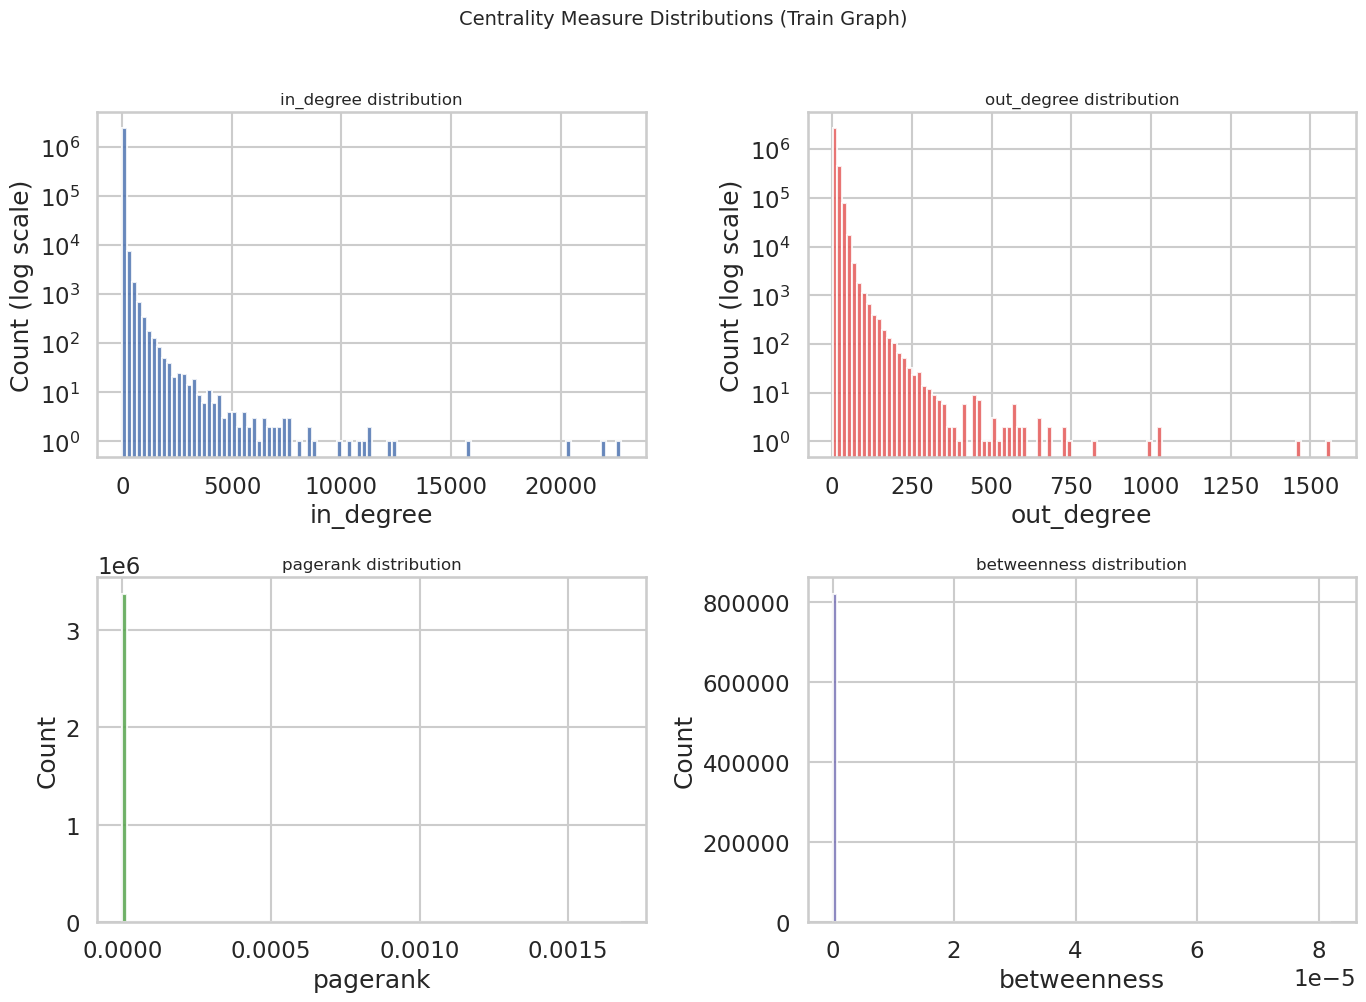

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color in zip(axes.flatten(),
                           ["in_degree", "out_degree", "pagerank", "betweenness"],
                           ["#4C72B0", "#E45756", "#54A24B", "#7570B3"]):
    data = centrality_df[col]
    if col in ["in_degree", "out_degree"]:
        ax.hist(data[data > 0], bins=100, color=color, alpha=0.85, log=True)
        ax.set_ylabel("Count (log scale)")
    else:
        ax.hist(data[data > 0], bins=100, color=color, alpha=0.85)
        ax.set_ylabel("Count")
    ax.set_title(f"{col} distribution", fontsize=12)
    ax.set_xlabel(col)

plt.suptitle("Centrality Measure Distributions (Train Graph)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Free memory
#del centrality_df
#gc.collect()
#print("Memory freed. Centrality is saved on disk.")


In [33]:
import graphistry
con = duckdb.connect()
con.register("edges_view", edges_str)  # <-- add this line

graphistry.register(
    api=3,
    server="hub.graphistry.com",
    username="Paolo_n",
    password="Ww7ji7fQ"
)

print("1. Finding the absolute Top 1 node...")
top_1_query = """
    SELECT node, COUNT(*) as degree
    FROM (
        SELECT src AS node FROM edges_view
        UNION ALL
        SELECT dst AS node FROM edges_view
    )
    GROUP BY node
    ORDER BY degree DESC
    LIMIT 1
"""
top_1_node = con.execute(top_1_query).df()['node'].iloc[0]
print(f"Target Node: {top_1_node}")

print("2. Extracting network tree (Hop 1 and Hop 2)...")
hop_query = f"""
    WITH Hop1 AS (
        SELECT dst AS node FROM edges_view WHERE src = '{top_1_node}'
        UNION
        SELECT src AS node FROM edges_view WHERE dst = '{top_1_node}'
    ),
    Hop2 AS (
        SELECT e.dst AS node FROM edges_view e JOIN Hop1 h ON e.src = h.node
        UNION
        SELECT e.src AS node FROM edges_view e JOIN Hop1 h ON e.dst = h.node
    )
    SELECT 'hop1' as level, node FROM Hop1 WHERE node != '{top_1_node}'
    UNION
    SELECT 'hop2' as level, node FROM Hop2 WHERE node != '{top_1_node}' AND node NOT IN (SELECT node FROM Hop1)
"""
results = con.execute(hop_query).df()

hop_1_list = results[results['level'] == 'hop1']['node'].tolist()
hop_2_list = results[results['level'] == 'hop2']['node'].tolist()

print("3. Tagging nodes for visualization...")
node_records = []
seen_nodes = set()

# Tag the 1 Target Node
node_records.append({"id": top_1_node, "type": "Target (Top 1)", "size": 30})
seen_nodes.add(top_1_node)

# Tag Hop 1 and Hop 2
for h1 in hop_1_list:
    if h1 not in seen_nodes:
        node_records.append({"id": h1, "type": "1st Degree", "size": 15})
        seen_nodes.add(h1)
        
for h2 in hop_2_list:
    if h2 not in seen_nodes:
        node_records.append({"id": h2, "type": "2nd Degree", "size": 5})
        seen_nodes.add(h2)

nodes_df = pd.DataFrame(node_records)

print("4. Fetching connecting edges...")
con.register("plot_nodes", nodes_df)
edges_query = """
    SELECT e.src, e.dst
    FROM edges_view e
    JOIN plot_nodes n1 ON e.src = n1.id
    JOIN plot_nodes n2 ON e.dst = n2.id
"""
tree_edges_df = con.execute(edges_query).df()

print("5. Plotting with Graphistry...")
# Update our color map to match the new Top 1 label
category_colors = {
    "Target (Top 1)": "red",
    "1st Degree": "blue",
    "2nd Degree": "silver"
}

g = graphistry.edges(tree_edges_df, 'src', 'dst') \
              .nodes(nodes_df, 'id') \
              .bind(
                  point_title='id',
                  point_size='size'
              ) \
              .encode_point_color(
                  'type',
                  categorical_mapping=category_colors,
                  default_mapping="black"
              ) \
              .settings(url_params={
                  'bg': '%23E5E5E5',
                  'edgeOpacity': 0.05,
                  'pointOpacity': 0.8      
              })

g.plot()

1. Finding the absolute Top 1 node...
Target Node: 53e9a281b7602d9702b88a98
2. Extracting network tree (Hop 1 and Hop 2)...
3. Tagging nodes for visualization...
4. Fetching connecting edges...
5. Plotting with Graphistry...


## 8. Pair Generation (DuckDB)



This step creates supervised paper pairs for citation prediction.

Each pair has:

| Column | Meaning |
|--------|---------|
| `source_id` | Paper that may cite another paper |
| `target_id` | Candidate cited paper |
| `label` | `1` if source cites target, `0` otherwise |

Instead of using all citation pairs, we sample a smaller and more informative dataset:

- **Positive pairs** are sampled from real citations using `POSITIVE_SAMPLE_PERCENT`.
- **Negative pairs** are matched hard negatives. For each sampled positive pair,
  the negative target is not cited by the source, has a similar target year, and
  preserves the positive pair's `same_venue` status. This prevents `same_venue`
  from becoming a shortcut for the sampling procedure.

This creates more realistic negative examples and reduces RAM/training cost.

The final output still contains only:

```text
source_id, target_id, label


In [120]:
TRAIN_NORMALIZED = DATA_DIR / "train_normalized.parquet"
VAL_NORMALIZED   = DATA_DIR / "val_normalized.parquet"
TEST_NORMALIZED  = DATA_DIR / "test_normalized.parquet"

In [121]:
TRAIN_POSITIVE_SAMPLE_PERCENT = 5
VAL_POSITIVE_SAMPLE_PERCENT = 2
TEST_POSITIVE_SAMPLE_PERCENT = 1

TRAIN_NEGATIVE_RATIO = 1
TRAIN_TARGET_POOL_PERCENT = 20
TRAIN_NEGATIVE_ATTEMPTS_PER_POSITIVE = 10

VAL_NEGATIVE_RATIO = 9
VAL_TARGET_POOL_PERCENT = 50
VAL_NEGATIVE_ATTEMPTS_PER_POSITIVE = 20

TEST_NEGATIVE_RATIO = 9
TEST_TARGET_POOL_PERCENT = 50
TEST_NEGATIVE_ATTEMPTS_PER_POSITIVE = 20

RANDOM_SEED = 42
NEGATIVE_BATCH_SIZE = 1_000_000
FORCE_REGENERATE_PAIRS = True

In [122]:

def generate_pairs_graph_aware_duckdb(
    parquet_path,
    centrality_path,
    output_path,
    all_papers_paths=None,
    positive_sample_percent=20,
    target_pool_percent=5,
    neg_ratio=1,
    seed=42,
    negative_attempts_per_positive=5,
    negative_batch_size=300_000,
):
    con = duckdb.connect()
    con.execute("PRAGMA preserve_insertion_order=false")
    con.execute("SET threads TO 4")

    Path(output_path).unlink(missing_ok=True)

    if all_papers_paths is None:
        all_papers_paths = [parquet_path]

    positive_threshold = max(0, min(10000, int(round(positive_sample_percent * 100))))
    target_threshold = max(0, min(10000, int(round(target_pool_percent * 100))))

    union_sql = " UNION ALL ".join([
        f"""
        SELECT
            id,
            TRY_CAST(year AS INTEGER) AS year_int,
            COALESCE(venue_norm, '') AS venue_norm
        FROM '{p}'
        """
        for p in all_papers_paths
    ])

    con.execute(f"""
        CREATE TABLE all_papers AS
        SELECT
            id,
            MAX(year_int) AS year_int,
            MAX(venue_norm) AS venue_norm
        FROM ({union_sql}) u
        GROUP BY id
    """)

    con.execute(f"""
        CREATE TABLE centrality AS
        SELECT
            id,
            MAX(in_degree) AS in_degree
        FROM '{centrality_path}'
        GROUP BY id
    """)

    con.execute("""
        CREATE TABLE venue_ids AS
        SELECT
            venue_norm,
            ROW_NUMBER() OVER (ORDER BY venue_norm) AS venue_id
        FROM (
            SELECT DISTINCT venue_norm
            FROM all_papers
            WHERE venue_norm != ''
        )
    """)

    con.execute("""
        CREATE TABLE all_papers_enriched AS
        SELECT
            ap.id,
            ap.year_int,
            v.venue_id,
            CAST(
                CASE
                    WHEN COALESCE(c.in_degree, 0) = 0 THEN 0
                    WHEN COALESCE(c.in_degree, 0) <= 5 THEN 1
                    WHEN COALESCE(c.in_degree, 0) <= 50 THEN 2
                    ELSE 3
                END AS UTINYINT
            ) AS popularity_bucket
        FROM all_papers ap
        LEFT JOIN venue_ids v ON ap.venue_norm = v.venue_norm
        LEFT JOIN centrality c ON ap.id = c.id
    """)

    con.execute("DROP TABLE all_papers")
    con.execute("DROP TABLE venue_ids")
    con.execute("DROP TABLE centrality")

    con.execute(f"""
        CREATE TABLE positive_pairs AS
        SELECT
            p.id AS source_id,
            ref.ref_id AS target_id,
            1 AS label
        FROM read_parquet('{parquet_path}') p
        CROSS JOIN LATERAL UNNEST(p."references") AS ref(ref_id)
        JOIN all_papers_enriched t
          ON ref.ref_id = t.id
        WHERE p."references" IS NOT NULL
          AND ref.ref_id != p.id
          AND TRY_CAST(p.year AS INTEGER) IS NOT NULL
          AND t.year_int IS NOT NULL
          AND t.year_int <= TRY_CAST(p.year AS INTEGER)
          AND hash(p.id, ref.ref_id, {seed}) % 10000 < {positive_threshold}
    """)

    n_positive_sampled = con.execute("""
        SELECT COUNT(*)
        FROM positive_pairs
    """).fetchone()[0]

    print(f"Positive pairs sampled: {n_positive_sampled:,}")

    con.execute(f"""
        CREATE TABLE source_years AS
        SELECT
            id,
            TRY_CAST(year AS INTEGER) AS year_int
        FROM '{parquet_path}'
    """)

    con.execute("""
        CREATE TABLE positives_enriched AS
        SELECT
            pp.source_id,
            pp.target_id AS positive_target_id,
            sy.year_int AS source_year,
            pt.year_int AS positive_target_year,
            pt.venue_id AS positive_target_venue_id,
            pt.popularity_bucket AS positive_popularity_bucket
        FROM positive_pairs pp
        JOIN source_years sy ON pp.source_id = sy.id
        JOIN all_papers_enriched pt ON pp.target_id = pt.id
        WHERE sy.year_int IS NOT NULL
          AND pt.year_int IS NOT NULL
          AND pt.venue_id IS NOT NULL
    """)

    con.execute("DROP TABLE source_years")

    con.execute("""
        CREATE OR REPLACE TABLE positive_pairs AS
        SELECT
            source_id,
            positive_target_id AS target_id,
            1 AS label
        FROM positives_enriched
    """)

    n_positive = con.execute("""
        SELECT COUNT(*)
        FROM positive_pairs
    """).fetchone()[0]

    n_negative_target = n_positive * neg_ratio
    negative_batches = max(1, math.ceil(n_positive / negative_batch_size))

    print(f"Positive pairs retained: {n_positive:,}")
    print(f"Target negative pairs: {n_negative_target:,}")
    print(f"Negative batches: {negative_batches:,}")

    con.execute(f"""
        CREATE TABLE target_pool AS
        SELECT
            id,
            year_int,
            venue_id,
            popularity_bucket
        FROM all_papers_enriched
        WHERE year_int IS NOT NULL
          AND venue_id IS NOT NULL
          AND hash(id, {seed}) % 10000 < {target_threshold}
    """)

    n_pool = con.execute("""
        SELECT COUNT(*)
        FROM target_pool
    """).fetchone()[0]

    print(f"Target pool size: {n_pool:,}")

    con.execute(f"""
        CREATE TABLE target_indexed AS
        SELECT
            id,
            year_int,
            venue_id,
            popularity_bucket,
            ROW_NUMBER() OVER (
                PARTITION BY year_int, venue_id, popularity_bucket
                ORDER BY hash(id, {seed})
            ) AS bucket_rn
        FROM target_pool
    """)

    con.execute("DROP TABLE target_pool")

    con.execute("""
        CREATE TABLE target_bucket_sizes AS
        SELECT
            year_int,
            venue_id,
            popularity_bucket,
            COUNT(*) AS bucket_size
        FROM target_indexed
        GROUP BY year_int, venue_id, popularity_bucket
    """)

    con.execute("""
        CREATE TABLE negative_pairs_internal AS
        SELECT
            source_id,
            positive_target_id,
            positive_target_id AS target_id,
            0 AS label
        FROM positives_enriched
        WHERE FALSE
    """)

    for batch in range(negative_batches):
        con.execute(f"""
            CREATE TEMP TABLE positive_batch AS
            SELECT
                source_id,
                positive_target_id,
                source_year,
                positive_target_year,
                positive_target_venue_id,
                positive_popularity_bucket
            FROM positives_enriched
            WHERE hash(source_id, positive_target_id, {seed}) % {negative_batches} = {batch}
        """)

        batch_count = con.execute("""
            SELECT COUNT(*)
            FROM positive_batch
        """).fetchone()[0]

        if batch_count == 0:
            con.execute("DROP TABLE positive_batch")
            continue

        con.execute("""
            CREATE TEMP TABLE batch_sources AS
            SELECT DISTINCT source_id
            FROM positive_batch
        """)

        con.execute(f"""
            CREATE TEMP TABLE positive_exclusion_batch AS
            SELECT
                p.id AS source_id,
                ref.ref_id AS target_id
            FROM read_parquet('{parquet_path}') p
            JOIN batch_sources bs
              ON p.id = bs.source_id
            CROSS JOIN LATERAL UNNEST(p."references") AS ref(ref_id)
            JOIN all_papers_enriched t
              ON ref.ref_id = t.id
            WHERE p."references" IS NOT NULL
              AND ref.ref_id != p.id
              AND TRY_CAST(p.year AS INTEGER) IS NOT NULL
              AND t.year_int IS NOT NULL
              AND t.year_int <= TRY_CAST(p.year AS INTEGER)
        """)

        for attempt in range(1, negative_attempts_per_positive + 1):
            con.execute(f"""
                INSERT INTO negative_pairs_internal
                WITH already_done AS (
                    SELECT
                        npi.source_id,
                        npi.positive_target_id,
                        COUNT(*) AS n_negatives
                    FROM negative_pairs_internal npi
                    JOIN positive_batch pb
                      ON npi.source_id = pb.source_id
                     AND npi.positive_target_id = pb.positive_target_id
                    GROUP BY
                        npi.source_id,
                        npi.positive_target_id
                ),
                needed_positives AS (
                    SELECT
                        pb.source_id,
                        pb.positive_target_id,
                        pb.source_year,
                        pb.positive_target_year,
                        pb.positive_target_venue_id,
                        pb.positive_popularity_bucket
                    FROM positive_batch pb
                    LEFT JOIN already_done ad
                      ON ad.source_id = pb.source_id
                     AND ad.positive_target_id = pb.positive_target_id
                    WHERE COALESCE(ad.n_negatives, 0) < {neg_ratio}
                ),
                positive_bucket_keys AS (
                    SELECT
                        np.source_id,
                        np.positive_target_id,
                        np.source_year,
                        np.positive_target_year + CAST(r.delta AS INTEGER) AS candidate_year,
                        np.positive_target_venue_id AS candidate_venue_id,
                        np.positive_popularity_bucket AS candidate_popularity_bucket,
                        CAST(r.delta AS INTEGER) AS delta
                    FROM needed_positives np
                    CROSS JOIN range(-1, 2) AS r(delta)
                    WHERE np.positive_target_year + CAST(r.delta AS INTEGER) <= np.source_year
                ),
                candidate_rows AS (
                    SELECT
                        pbk.source_id,
                        pbk.positive_target_id,
                        ti.id AS target_id,
                        0 AS label,
                        ROW_NUMBER() OVER (
                            PARTITION BY pbk.source_id, pbk.positive_target_id
                            ORDER BY hash(
                                pbk.source_id,
                                pbk.positive_target_id,
                                ti.id,
                                {attempt},
                                {seed}
                            )
                        ) AS rn
                    FROM positive_bucket_keys pbk
                    JOIN target_bucket_sizes tbs
                      ON tbs.year_int = pbk.candidate_year
                     AND tbs.venue_id = pbk.candidate_venue_id
                     AND tbs.popularity_bucket = pbk.candidate_popularity_bucket
                    JOIN target_indexed ti
                      ON ti.year_int = pbk.candidate_year
                     AND ti.venue_id = pbk.candidate_venue_id
                     AND ti.popularity_bucket = pbk.candidate_popularity_bucket
                     AND ti.bucket_rn =
                        CAST(
                            1 + (
                                hash(
                                    pbk.source_id,
                                    pbk.positive_target_id,
                                    pbk.candidate_year,
                                    pbk.candidate_venue_id,
                                    pbk.candidate_popularity_bucket,
                                    pbk.delta,
                                    {attempt},
                                    {seed}
                                ) % tbs.bucket_size
                            ) AS BIGINT
                        )
                    WHERE ti.id != pbk.source_id
                      AND ti.id != pbk.positive_target_id
                      AND NOT EXISTS (
                          SELECT 1
                          FROM positive_exclusion_batch pe
                          WHERE pe.source_id = pbk.source_id
                            AND pe.target_id = ti.id
                      )
                      AND NOT EXISTS (
                          SELECT 1
                          FROM negative_pairs_internal existing
                          WHERE existing.source_id = pbk.source_id
                            AND existing.target_id = ti.id
                      )
                )
                SELECT
                    source_id,
                    positive_target_id,
                    target_id,
                    label
                FROM candidate_rows
                WHERE rn = 1
            """)

            n_batch_done = con.execute("""
                SELECT COUNT(*)
                FROM negative_pairs_internal npi
                JOIN positive_batch pb
                  ON npi.source_id = pb.source_id
                 AND npi.positive_target_id = pb.positive_target_id
            """).fetchone()[0]

            if n_batch_done >= batch_count * neg_ratio:
                break

        con.execute("DROP TABLE positive_exclusion_batch")
        con.execute("DROP TABLE batch_sources")
        con.execute("DROP TABLE positive_batch")

        n_current = con.execute("""
            SELECT COUNT(*)
            FROM negative_pairs_internal
        """).fetchone()[0]

        print(
            f"Negative batch {batch + 1:,}/{negative_batches:,}: "
            f"{n_current:,} / {n_negative_target:,}"
        )

        if n_current >= n_negative_target:
            break

    con.execute(f"""
        CREATE TABLE negative_pairs AS
        SELECT
            source_id,
            target_id,
            label
        FROM negative_pairs_internal
        LIMIT {n_negative_target}
    """)

    n_negative_actual = con.execute("""
        SELECT COUNT(*)
        FROM negative_pairs
    """).fetchone()[0]

    print(f"Negative pairs sampled: {n_negative_actual:,}")

    if n_negative_actual < n_negative_target:
        print(
            f"WARNING: generated only {n_negative_actual:,} / "
            f"{n_negative_target:,} requested negatives. "
            f"Consider increasing target_pool_percent or negative_attempts_per_positive."
        )

    con.execute(f"""
        COPY (
            SELECT * FROM positive_pairs
            UNION ALL
            SELECT * FROM negative_pairs
        ) TO '{output_path}' (FORMAT PARQUET)
    """)

    total = n_positive + n_negative_actual

    print(f"Total pairs: {total:,} saved to {output_path}")

    if total > 0:
        print(
            f"Label distribution: "
            f"1={n_positive:,} ({n_positive / total * 100:.1f}%), "
            f"0={n_negative_actual:,} ({n_negative_actual / total * 100:.1f}%)"
        )

    con.execute("DROP TABLE positive_pairs")
    con.execute("DROP TABLE negative_pairs")
    con.execute("DROP TABLE negative_pairs_internal")
    con.execute("DROP TABLE positives_enriched")
    con.execute("DROP TABLE target_bucket_sizes")
    con.execute("DROP TABLE target_indexed")
    con.execute("DROP TABLE all_papers_enriched")

    con.close()


In [123]:
split_pair_config = {
    "train": {
        "positive_sample_percent": TRAIN_POSITIVE_SAMPLE_PERCENT,
        "neg_ratio": TRAIN_NEGATIVE_RATIO,
        "target_pool_percent": TRAIN_TARGET_POOL_PERCENT,
        "negative_attempts_per_positive": TRAIN_NEGATIVE_ATTEMPTS_PER_POSITIVE,
    },
    "val": {
        "positive_sample_percent": VAL_POSITIVE_SAMPLE_PERCENT,
        "neg_ratio": VAL_NEGATIVE_RATIO,
        "target_pool_percent": VAL_TARGET_POOL_PERCENT,
        "negative_attempts_per_positive": VAL_NEGATIVE_ATTEMPTS_PER_POSITIVE,
    },
    "test": {
        "positive_sample_percent": TEST_POSITIVE_SAMPLE_PERCENT,
        "neg_ratio": TEST_NEGATIVE_RATIO,
        "target_pool_percent": TEST_TARGET_POOL_PERCENT,
        "negative_attempts_per_positive": TEST_NEGATIVE_ATTEMPTS_PER_POSITIVE,
    },
}


for split in ["train", "val", "test"]:
    output_path = f"data/{split}_pairs.parquet"

    if os.path.exists(output_path) and not FORCE_REGENERATE_PAIRS:
        print(f"[{split}] pairs already exists, skipping")
        continue

    if split == "train":
        all_paths = [str(TRAIN_NORMALIZED)]
    elif split == "val":
        all_paths = [
            str(TRAIN_NORMALIZED),
            str(VAL_NORMALIZED),
        ]
    else:
        all_paths = [
            str(TRAIN_NORMALIZED),
            str(VAL_NORMALIZED),
            str(TEST_NORMALIZED),
        ]

    cfg = split_pair_config[split]

    print(
        f"Generating pairs for: {split} "
        f"(positive_sample={cfg['positive_sample_percent']}%, "
        f"target_pool={cfg['target_pool_percent']}%, "
        f"negative_ratio=1:{cfg['neg_ratio']}, "
        f"attempts={cfg['negative_attempts_per_positive']})"
    )

    generate_pairs_graph_aware_duckdb(
        parquet_path=f"data/{split}_normalized.parquet",
        centrality_path="data/train_centrality.parquet",
        output_path=output_path,
        all_papers_paths=all_paths,
        positive_sample_percent=cfg["positive_sample_percent"],
        target_pool_percent=cfg["target_pool_percent"],
        neg_ratio=cfg["neg_ratio"],
        seed=RANDOM_SEED,
        negative_attempts_per_positive=cfg["negative_attempts_per_positive"],
        negative_batch_size=NEGATIVE_BATCH_SIZE,
    )

Generating pairs for: train (positive_sample=5%, target_pool=20%, negative_ratio=1:1, attempts=10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Positive pairs sampled: 1,604,263
Positive pairs retained: 1,604,225
Target negative pairs: 1,604,225
Negative batches: 2
Target pool size: 690,696


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Negative batch 1/2: 679,914 / 1,604,225


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Negative batch 2/2: 1,360,286 / 1,604,225
Negative pairs sampled: 1,360,286
Total pairs: 2,964,511 saved to data/train_pairs.parquet
Label distribution: 1=1,604,225 (54.1%), 0=1,360,286 (45.9%)
Generating pairs for: val (positive_sample=2%, target_pool=50%, negative_ratio=1:9, attempts=20)
Positive pairs sampled: 101,770
Positive pairs retained: 101,767
Target negative pairs: 915,903
Negative batches: 1
Target pool size: 1,893,103
Negative batch 1/1: 750,689 / 915,903
Negative pairs sampled: 750,689
Total pairs: 852,456 saved to data/val_pairs.parquet
Label distribution: 1=101,767 (11.9%), 0=750,689 (88.1%)
Generating pairs for: test (positive_sample=1%, target_pool=50%, negative_ratio=1:9, attempts=20)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Positive pairs sampled: 102,410
Positive pairs retained: 102,409
Target negative pairs: 921,681
Negative batches: 1
Target pool size: 2,261,771
Negative batch 1/1: 795,107 / 921,681
Negative pairs sampled: 795,107
Total pairs: 897,516 saved to data/test_pairs.parquet
Label distribution: 1=102,409 (11.4%), 0=795,107 (88.6%)


## 9. Feature Extraction


For each pair (source_paper, target_paper) we extract features that capture
different reasons why a citation might occur. The features are divided into
3 groups, which will later be used to train separate and combined models.

**Traditional Features (7)**

Metadata-based features that don't require text analysis or network structure:

| Feature | Description |
|---------|-------------|
| `year_diff` | year(source) − year(target). Papers cite older work, so positive values indicate a valid citation direction. |
| `is_recent` | 1 if the two papers are within 3 years of each other. Captures recency bias. |
| `same_venue` | 1 if both papers share the same venue. Same-community papers cite each other more. |
| `same_doc_type` | 1 if both papers share the same document type (journal, conference, etc.). |
| `n_citation_target` | Number of times the target was cited before the source was written (temporally gated). Popular papers attract more citations. |
| `n_authors_source` | Number of authors on the source paper. |
| `n_authors_target` | Number of authors on the target paper. |

**Textual Features (3)**

Content-similarity features derived from the papers' text:

| Feature | Description |
|---------|-------------|
| `abstract_sim` | Cosine similarity between TF-IDF vectors of the two abstracts. Strongest semantic signal. |
| `keyword_jaccard` | Jaccard similarity between keyword sets. Measures topical overlap via curated descriptors. |
| `title_sim` | Cosine similarity between TF-IDF vectors of the two titles. |

**Graph Features (6)**

Structural features from the citation network and co-authorship:

| Feature | Description |
|---------|-------------|
| `has_shared_author` | 1 if at least one author appears in both papers. Self-citation is common. |
| `shared_orgs` | 1 if any authors share the same organization. |
| `in_degree_target` | Incoming citations of target paper in the train graph. |
| `out_degree_target` | Outgoing references of target paper in the train graph. |
| `pagerank_target` | PageRank of target paper. Recursive importance measure. |
| `betweenness_target` | Betweenness centrality of target paper. Bridge between communities. |

Source centrality features (`in_degree_source`, `pagerank_source`, `betweenness_source`, `out_degree_source`) were excluded because a source paper has zero citations at writing time — any value from the global graph would be pure future leakage. Similarly, `n_refs_source` (the source's final reference count) is unavailable pre-publication. Target centrality is kept because target papers are already published and their relative importance ranking is approximately stable over time. Building per-year graph snapshots would be the fully correct approach, but it requires ~25–30 separate cuGraph runs on millions of nodes, which is prohibitively expensive. Tree-based models like LightGBM exploit ranking rather than magnitude, so the mild inflation in absolute values does not significantly affect performance.

**Pipeline Strategy**

To handle RAM constraints with millions of papers, we split extraction into two phases:
- **Phase 1 (DuckDB)**: traditional features + graph centrality lookups via SQL joins.
  DuckDB works directly on parquet files without loading everything into RAM.
- **Phase 2 (Python + GPU)**: textual similarities (TF-IDF + cosine on GPU),
  set-based features (shared_author, shared_orgs) via Python dicts.

Centrality measures come from the **train graph only** to prevent data leakage.
Val/test papers not present in the train graph receive centrality = 0.
`n_citation_target` is computed from the union of all available prior splits
(train for train pairs, train+val for val pairs, train+val+test for test pairs),
temporally gated by `citing_year < source_year`.

Each set (train, val, test) is processed independently and saved before
loading the next one, keeping peak RAM usage low.

**Total: 16 features per pair.**

In [124]:
# Paths
DATA_DIR = Path("data")
TRAIN_NORMALIZED = DATA_DIR / "train_normalized.parquet"
VAL_NORMALIZED   = DATA_DIR / "val_normalized.parquet"
TEST_NORMALIZED  = DATA_DIR / "test_normalized.parquet"

TRAIN_PAIRS = DATA_DIR / "train_pairs.parquet"
VAL_PAIRS   = DATA_DIR / "val_pairs.parquet"
TEST_PAIRS  = DATA_DIR / "test_pairs.parquet"

CENTRALITY_PATH = DATA_DIR / "train_centrality.parquet"

VECTORIZER_PATH = DATA_DIR / "tfidf_vectorizers.joblib"

# TF-IDF config
TF_IDF_MAX_FEATURES = 5000

# improve computation efficency 
PAIR_CHUNK_SIZE = 2_000_000     # pairs per streaming chunk
GPU_SIM_CHUNK_SIZE = 512        # rows densified onto GPU at a time

# Phase 1 outputs
PHASE1_OUTPUTS = {
    "train": DATA_DIR / "train_features_phase1.parquet",
    "val":   DATA_DIR / "val_features_phase1.parquet",
    "test":  DATA_DIR / "test_features_phase1.parquet",
}

PHASE2_OUTPUTS = {
    "train": DATA_DIR / "train_features_final.parquet",
    "val":   DATA_DIR / "val_features_final.parquet",
    "test":  DATA_DIR / "test_features_final.parquet",
}

FORCE_REGENERATE_FEATURES = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 9.1. Phase 1 — Traditional & Graph Centrality Features


Phase 1 extracts 11 features for each pair directly via DuckDB SQL joins
on parquet files, keeping peak RAM usage low without loading data into memory.

**Features produced here:**
- `year_diff`, `is_recent` — temporal relationship between the two papers
- `same_venue`, `same_doc_type` — community and document-type overlap
- `n_citation_target` — how many times the target was cited before the source was written (temporally gated, train graph only, no leakage)
- `n_authors_source`, `n_authors_target` — author count for each paper
- `in_degree_target`, `out_degree_target` — citation counts from the train graph. We use target-side centrality only; source-side out-degree is excluded because it would leak information about the source paper's final bibliography.
- `pagerank_target` — recursive importance from the train graph
- `betweenness_target` — bridge role between communities in the train graph

Centrality features come from the **train graph only** to prevent data leakage.
Val/test papers not present in the train graph receive centrality = 0.
`n_citation_target` is counted from raw reference lists gated by
`citing_year < source_year`, never from the label column.

Phase 2 will add the remaining 5 pre-publication-safe textual and set-based features.


#### 9.1.1. Load Base Features


Joins pairs with paper metadata and centrality scores.
Writes a temporary parquet with all base columns plus
`source_year_tmp` / `target_year_tmp` needed by Step 2.


In [125]:
def _load_base_features(con, pairs_path, normalized_path, all_papers_paths, centrality_path, tmp_path):
    union_sql = " UNION ALL ".join([
        f"""
        SELECT
            id,
            TRY_CAST(year AS INTEGER) AS year_int,
            COALESCE(venue_norm, '') AS venue_norm,
            COALESCE(doc_type, '') AS doc_type,
            COALESCE(n_authors, 0) AS n_authors
        FROM '{p}'
        """
        for p in all_papers_paths
    ])

    con.execute(f"""
        CREATE TEMP TABLE source_meta AS
        SELECT
            id,
            TRY_CAST(year AS INTEGER) AS year_int,
            COALESCE(venue_norm, '') AS venue_norm,
            COALESCE(doc_type, '') AS doc_type,
            COALESCE(n_authors, 0) AS n_authors
        FROM '{normalized_path}'
    """)

    con.execute(f"""
        CREATE TEMP TABLE all_papers_meta AS
        SELECT
            id,
            MAX(year_int) AS year_int,
            MAX(venue_norm) AS venue_norm,
            MAX(doc_type) AS doc_type,
            MAX(n_authors) AS n_authors
        FROM ({union_sql}) u
        GROUP BY id
    """)

    con.execute(f"""
        CREATE TEMP TABLE centrality_meta AS
        SELECT
            id,
            MAX(in_degree) AS in_degree,
            MAX(out_degree) AS out_degree,
            MAX(pagerank) AS pagerank,
            MAX(betweenness) AS betweenness
        FROM '{centrality_path}'
        GROUP BY id
    """)

    con.execute(f"""
        COPY (
            SELECT
                p.source_id,
                p.target_id,
                p.label,

                s.year_int AS source_year_tmp,
                t.year_int AS target_year_tmp,

                s.year_int - t.year_int AS year_diff,

                CASE
                    WHEN s.year_int - t.year_int BETWEEN 0 AND 3
                    THEN 1 ELSE 0
                END AS is_recent,

                CASE
                    WHEN s.venue_norm = t.venue_norm
                     AND s.venue_norm != ''
                    THEN 1 ELSE 0
                END AS same_venue,

                CASE
                    WHEN s.doc_type = t.doc_type
                     AND s.doc_type != ''
                    THEN 1 ELSE 0
                END AS same_doc_type,

                COALESCE(s.n_authors, 0) AS n_authors_source,
                COALESCE(t.n_authors, 0) AS n_authors_target,

                COALESCE(ct.in_degree, 0) AS in_degree_target,
                COALESCE(ct.out_degree, 0) AS out_degree_target,
                COALESCE(ct.pagerank, 0.0) AS pagerank_target,
                COALESCE(ct.betweenness, 0.0) AS betweenness_target

            FROM '{pairs_path}' p
            LEFT JOIN source_meta s
              ON p.source_id = s.id
            LEFT JOIN all_papers_meta t
              ON p.target_id = t.id
            LEFT JOIN centrality_meta ct
              ON p.target_id = ct.id
        ) TO '{tmp_path}' (FORMAT PARQUET)
    """)

    con.execute("DROP TABLE source_meta")
    con.execute("DROP TABLE all_papers_meta")
    con.execute("DROP TABLE centrality_meta")



In [126]:
# Paths
DATA_DIR = Path("data")
TRAIN_NORMALIZED = DATA_DIR / "train_normalized.parquet"
VAL_NORMALIZED   = DATA_DIR / "val_normalized.parquet"
TEST_NORMALIZED  = DATA_DIR / "test_normalized.parquet"

TRAIN_PAIRS = DATA_DIR / "train_pairs.parquet"
VAL_PAIRS   = DATA_DIR / "val_pairs.parquet"
TEST_PAIRS  = DATA_DIR / "test_pairs.parquet"

CENTRALITY_PATH = DATA_DIR / "train_centrality.parquet"

VECTORIZER_PATH = DATA_DIR / "tfidf_vectorizers.joblib"

# TF-IDF config
TF_IDF_MAX_FEATURES = 5000

# improve computation efficency 
PAIR_CHUNK_SIZE = 2_000_000     # pairs per streaming chunk
GPU_SIM_CHUNK_SIZE = 512        # rows densified onto GPU at a time

# Phase 1 outputs
PHASE1_OUTPUTS = {
    "train": DATA_DIR / "train_features_phase1.parquet",
    "val":   DATA_DIR / "val_features_phase1.parquet",
    "test":  DATA_DIR / "test_features_phase1.parquet",
}

PHASE2_OUTPUTS = {
    "train": DATA_DIR / "train_features_final.parquet",
    "val":   DATA_DIR / "val_features_final.parquet",
    "test":  DATA_DIR / "test_features_final.parquet",
}

FORCE_REGENERATE_FEATURES = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### 9.1.2. Compute Prior Citations

Counts how many times the target paper was cited **before** the source
paper was written. Uses raw reference lists from the normalized parquet,
never from the label column — no data leakage.


In [127]:
def _compute_prior_citations(con, citation_source_paths, tmp_path):
    con.execute(f"""
        CREATE TEMP TABLE feature_target_years AS
        SELECT DISTINCT
            target_id,
            source_year_tmp
        FROM '{tmp_path}'
        WHERE target_id IS NOT NULL
          AND source_year_tmp IS NOT NULL
    """)

    con.execute("""
        CREATE TEMP TABLE feature_target_ids AS
        SELECT DISTINCT target_id
        FROM feature_target_years
    """)

    union_clauses = " UNION ALL ".join([
        f"""
        SELECT
            ref.ref_id AS target_id,
            TRY_CAST(p.year AS INTEGER) AS citing_year,
            COUNT(*) AS n_citations
        FROM read_parquet('{path}') p
        CROSS JOIN LATERAL UNNEST(p."references") AS ref(ref_id)
        JOIN feature_target_ids fti
          ON ref.ref_id = fti.target_id
        WHERE p."references" IS NOT NULL
          AND ref.ref_id IS NOT NULL
          AND TRY_CAST(p.year AS INTEGER) IS NOT NULL
        GROUP BY
            ref.ref_id,
            TRY_CAST(p.year AS INTEGER)
        """
        for path in citation_source_paths
    ])

    con.execute(f"""
        CREATE TEMP TABLE citation_year_counts AS
        SELECT
            target_id,
            citing_year,
            SUM(n_citations) AS n_citations
        FROM ({union_clauses}) u
        GROUP BY target_id, citing_year
    """)

    con.execute("""
        CREATE TEMP TABLE target_prior_counts AS
        SELECT
            fty.target_id,
            fty.source_year_tmp,
            COALESCE(SUM(cyc.n_citations), 0) AS n_citation_target
        FROM feature_target_years fty
        LEFT JOIN citation_year_counts cyc
          ON cyc.target_id = fty.target_id
         AND cyc.citing_year < fty.source_year_tmp
        GROUP BY
            fty.target_id,
            fty.source_year_tmp
    """)

    con.execute("DROP TABLE feature_target_ids")
    con.execute("DROP TABLE feature_target_years")
    con.execute("DROP TABLE citation_year_counts")


#### 9.1.3. Write Final Output


Joins prior citation counts onto base features, drops the temporary
year columns, and writes the final parquet.


In [128]:
def _write_final(con, tmp_path, output_path):
    con.execute(f"""
        COPY (
            SELECT
                f.source_id,
                f.target_id,
                f.label,
                f.year_diff,
                f.is_recent,
                f.same_venue,
                f.same_doc_type,
                COALESCE(tpc.n_citation_target, 0) AS n_citation_target,
                f.n_authors_source,
                f.n_authors_target,
                f.in_degree_target,
                f.out_degree_target,
                f.pagerank_target,
                f.betweenness_target
            FROM '{tmp_path}' f
            LEFT JOIN target_prior_counts tpc
              ON f.target_id = tpc.target_id
             AND f.source_year_tmp = tpc.source_year_tmp
        ) TO '{output_path}' (FORMAT PARQUET)
    """)

    con.execute("DROP TABLE target_prior_counts")


#### 9.1.4. Orchestrator

Chains all steps, handles tmp file cleanup, and reports timing.


In [129]:
def extract_traditional_features_duckdb(
    pairs_path,
    normalized_path,
    centrality_path,
    output_path,
    citation_source_paths=None,
    all_papers_paths=None,          # CHANGED: new parameter
):
    con = duckdb.connect()
    t0 = time.time()

    tmp_path = str(output_path).replace(".parquet", "_tmp.parquet")
    Path(tmp_path).unlink(missing_ok=True)
    Path(output_path).unlink(missing_ok=True)

    # CHANGED: pass all_papers_paths, default to [normalized_path]
    ap_paths = all_papers_paths or [str(normalized_path)]
    _load_base_features(con, pairs_path, normalized_path, ap_paths, centrality_path, tmp_path)

    cit_paths = citation_source_paths or [normalized_path]
    _compute_prior_citations(con, cit_paths, tmp_path)

    _write_final(con, tmp_path, output_path)

    Path(tmp_path).unlink(missing_ok=True)

    elapsed = time.time() - t0
    n_rows = con.execute(f"SELECT COUNT(*) FROM '{output_path}'").fetchone()[0]
    con.close()
    print(f"  Rows: {n_rows:,} | Time: {elapsed:.1f}s → {output_path}")

#### 9.1.5. Run 

In [130]:
split, pairs, normalized = "train", TRAIN_PAIRS, TRAIN_NORMALIZED
output = PHASE1_OUTPUTS[split]

if output.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists.")
else:
    print(f"Phase 1 — {split}")
    extract_traditional_features_duckdb(
        pairs_path=pairs,
        normalized_path=normalized,
        centrality_path=CENTRALITY_PATH,
        output_path=output,
        citation_source_paths=[str(TRAIN_NORMALIZED)],
        all_papers_paths=[str(TRAIN_NORMALIZED)],
    )


Phase 1 — train


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Rows: 2,964,511 | Time: 10.2s → data/train_features_phase1.parquet


In [131]:
split, pairs, normalized = "val", VAL_PAIRS, VAL_NORMALIZED
output = PHASE1_OUTPUTS[split]

if output.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists.")
else:
    print(f"Phase 1 — {split}")
    extract_traditional_features_duckdb(
        pairs_path=pairs,
        normalized_path=normalized,
        centrality_path=CENTRALITY_PATH,
        output_path=output,
        citation_source_paths=[str(TRAIN_NORMALIZED), str(VAL_NORMALIZED)],
        all_papers_paths=[str(TRAIN_NORMALIZED), str(VAL_NORMALIZED)],
    )


Phase 1 — val


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Rows: 852,456 | Time: 7.7s → data/val_features_phase1.parquet


In [132]:
split, pairs, normalized = "test", TEST_PAIRS, TEST_NORMALIZED
output = PHASE1_OUTPUTS[split]

if output.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists.")
else:
    print(f"Phase 1 — {split}")
    extract_traditional_features_duckdb(
        pairs_path=pairs,
        normalized_path=normalized,
        centrality_path=CENTRALITY_PATH,
        output_path=output,
        citation_source_paths=[
            str(TRAIN_NORMALIZED),
            str(VAL_NORMALIZED),
            str(TEST_NORMALIZED),
        ],
        all_papers_paths=[
            str(TRAIN_NORMALIZED),
            str(VAL_NORMALIZED),
            str(TEST_NORMALIZED),
        ],
    )


Phase 1 — test


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Rows: 897,516 | Time: 8.6s → data/test_features_phase1.parquet


### 9.2. Phase 2 — Textual & Set-based Features

Phase 1 already produced traditional + graph centrality features via DuckDB.
Phase 2 adds the remaining 5 pre-publication-safe features that need either GPU compute (TF-IDF
cosine similarities) or per-paper Python lookups (set intersections).

**Features produced here:**
- `abstract_sim`, `title_sim` — cosine similarity on TF-IDF vectors (GPU)
- `keyword_jaccard` — Jaccard similarity between keyword sets
- `has_shared_author`, `shared_orgs` — co-authorship / co-affiliation flags

The pipeline is split into small functions so each step can be explained
and inspected on its own. The orchestrator at the bottom just chains them.

#### 9.2.1. Helpers

`jaccard` — standard Jaccard similarity between two sets.
Returns 0 when both sets are empty (instead of raising on 0/0).

In [133]:
def jaccard(set_a, set_b):
    """Jaccard similarity between two sets."""
    if not set_a and not set_b:
        return 0.0
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0

#### 9.2.2. Load Inputs


We read only the columns we actually need from the normalized papers
(loading every column would waste RAM). `id_to_idx` maps each paper ID
to its row position so we can later index the TF-IDF matrices by ID.

In [134]:
def load_papers(normalized_paths, phase1_path=None):
    """Load only papers needed by the current pair file."""
    if isinstance(normalized_paths, (str, Path)):
        normalized_paths = [normalized_paths]

    needed_ids = None
    if phase1_path is not None:
        print("  Loading needed paper ids from phase1 pairs...")
        ids_df = pd.read_parquet(
            phase1_path,
            columns=["source_id", "target_id"]
        )
        needed_ids = set(pd.concat([
            ids_df["source_id"],
            ids_df["target_id"]
        ]).dropna().unique())
        del ids_df
        gc.collect()
        print(f"    Needed unique papers: {len(needed_ids):,}")

    desired_cols = [
        "id",
        "title_norm",
        "abstract_norm",
        "keywords_norm",
        "author_names_norm",
        "author_ids_clean",
        "author_orgs_clean",
    ]

    dfs = []
    t0 = time.time()

    for p in normalized_paths:
        p = Path(p)
        print(f"  Loading papers from {p.name}...")

        available_cols = set(pq.ParquetFile(p).schema.names)
        cols = [c for c in desired_cols if c in available_cols]

        df_part = pd.read_parquet(p, columns=cols)

        for col in desired_cols:
            if col not in df_part.columns:
                if col in ["title_norm", "abstract_norm"]:
                    df_part[col] = ""
                elif col == "id":
                    raise ValueError(f"Missing required column 'id' in {p}")
                else:
                    df_part[col] = [[] for _ in range(len(df_part))]

        if needed_ids is not None:
            df_part = df_part[df_part["id"].isin(needed_ids)]

        print(f"    {len(df_part):,} papers kept")
        dfs.append(df_part[desired_cols])

    df = pd.concat(dfs, ignore_index=True).drop_duplicates(subset=["id"])
    print(f"    Total unique papers loaded: {len(df):,} in {time.time()-t0:.1f}s")

    id_to_idx = {pid: i for i, pid in enumerate(df["id"])}
    return df, id_to_idx


#### 9.2.3. TF-IDF Matrices

On **train** we fit the vocabulary and transform.
On **val/test** we reuse the train vectorizers (transform only) — this
is critical to avoid leakage: the model must not see val/test vocabulary
during training.

Bigrams (`ngram_range=(1, 2)`) capture short phrases like "neural network",
and `min_df=2` drops terms appearing only once.

In [135]:
def build_tfidf_matrices(df, train_title_vec=None, train_abstract_vec=None):
    """Fit on train, transform-only on val/test."""
    titles = df["title_norm"].fillna("").values
    abstracts = df["abstract_norm"].fillna("").values

    if train_title_vec is None:
        title_vec = TfidfVectorizer(
            max_features=TF_IDF_MAX_FEATURES, stop_words="english",
            ngram_range=(1, 2), min_df=2
        )
        title_tfidf = title_vec.fit_transform(titles)

        abstract_vec = TfidfVectorizer(
            max_features=TF_IDF_MAX_FEATURES, stop_words="english",
            ngram_range=(1, 2), min_df=2
        )
        abstract_tfidf = abstract_vec.fit_transform(abstracts)
        print("    TF-IDF: fit + transform (train)")
    else:
        title_vec, abstract_vec = train_title_vec, train_abstract_vec
        title_tfidf = title_vec.transform(titles)
        abstract_tfidf = abstract_vec.transform(abstracts)
        print("    TF-IDF: transform only (using train vocabulary)")

    print(f"    Title TF-IDF:    {title_tfidf.shape}")
    print(f"    Abstract TF-IDF: {abstract_tfidf.shape}")
    return title_vec, abstract_vec, title_tfidf, abstract_tfidf


#### 9.2.4. Lookup Sets

Pre-build dictionaries `paper_id -> set(...)` so per-pair work is just dict
lookups + set intersection. These dicts are the heaviest persistent objects
in memory, but they only depend on papers (not pairs), so they're built once.



In [136]:
def build_lookup_sets(df):
    """Build paper_id -> set dictionaries for authors, orgs, and keywords."""
    author_sets = {}
    org_sets = {}
    keyword_sets = {}

    for _, row in df.iterrows():
        pid = row["id"]

        a_ids = row.get("author_ids_clean", [])
        a_names = row.get("author_names_norm", [])
        if isinstance(a_ids, list) and len(a_ids) > 0:
            author_sets[pid] = set(a_ids)
        elif isinstance(a_names, list):
            author_sets[pid] = set(a_names)
        else:
            author_sets[pid] = set()

        a_orgs = row.get("author_orgs_clean", [])
        org_sets[pid] = set(a_orgs) if isinstance(a_orgs, list) else set()

        kw = row.get("keywords_norm", [])
        keyword_sets[pid] = set(kw) if isinstance(kw, list) else set()

    return author_sets, org_sets, keyword_sets


#### 9.3.5. GPU Cosine Similarities

For each pair we need cosine similarity between the source and target
vectors. Doing this on CPU one pair at a time would take forever, so we
batch the rows onto GPU, L2-normalize, and take a row-wise dot product.

`CHUNK_SIZE = 512` keeps VRAM usage bounded — we densify only 512 rows at
a time instead of the whole sparse matrix.


In [137]:
def gpu_similarities_for_chunk(src_indices, tgt_indices, title_tfidf, abstract_tfidf, device):
    """Cosine similarity for one chunk of pairs."""
    results = {}

    for name, tfidf_matrix in [("title_sim", title_tfidf), ("abstract_sim", abstract_tfidf)]:
        all_sims = []
        for cs in range(0, len(src_indices), GPU_SIM_CHUNK_SIZE):
            ce = min(cs + GPU_SIM_CHUNK_SIZE, len(src_indices))

            src_vecs = torch.tensor(
                tfidf_matrix[src_indices[cs:ce]].toarray(),
                dtype=torch.float32, device=device
            )
            tgt_vecs = torch.tensor(
                tfidf_matrix[tgt_indices[cs:ce]].toarray(),
                dtype=torch.float32, device=device
            )
            src_norm = torch.nn.functional.normalize(src_vecs, p=2, dim=1)
            tgt_norm = torch.nn.functional.normalize(tgt_vecs, p=2, dim=1)
            sims = (src_norm * tgt_norm).sum(dim=1)
            all_sims.append(sims.cpu().numpy())

            del src_vecs, tgt_vecs, src_norm, tgt_norm, sims
        torch.cuda.empty_cache()
        results[name] = np.concatenate(all_sims)

    return results

#### 9.2.6. Set-based Features


We pre-build dictionaries `paper_id -> set(...)` so the pair loop in step 5
is just two dict lookups and a set intersection. Building these once is
much faster than re-parsing the dataframe per pair.

This is the heaviest object in memory — millions of Python sets.


In [138]:
def set_features_for_chunk(chunk_df, author_sets, org_sets, keyword_sets):
    """Compute pre-publication-safe set features for one pair chunk."""
    n = len(chunk_df)
    keyword_jaccards  = np.zeros(n)
    shared_author_arr = np.zeros(n, dtype=np.int8)
    shared_orgs_arr   = np.zeros(n, dtype=np.int8)

    for i, row in enumerate(chunk_df.itertuples(index=False)):
        s, t = row.source_id, row.target_id

        keyword_jaccards[i] = jaccard(
            keyword_sets.get(s, set()), keyword_sets.get(t, set())
        )

        shared_author_arr[i] = int(
            len(author_sets.get(s, set()) & author_sets.get(t, set())) > 0
        )
        shared_orgs_arr[i] = int(
            len(org_sets.get(s, set()) & org_sets.get(t, set())) > 0
        )

    return {
        "keyword_jaccard":   keyword_jaccards,
        "has_shared_author": shared_author_arr,
        "shared_orgs":       shared_orgs_arr,
    }


In [139]:
def stream_phase1_and_write(phase1_path, output_path, id_to_idx,
                            title_tfidf, abstract_tfidf,
                            author_sets, org_sets, keyword_sets):
    """Stream phase1 pairs, attach phase 2 features, write to output."""
    parquet_file = pq.ParquetFile(phase1_path)
    n_total = parquet_file.metadata.num_rows
    print(f"    Streaming {n_total:,} pairs in chunks of {PAIR_CHUNK_SIZE:,}...")

    writer = None
    rows_done = 0
    t_start = time.time()

    try:
        for batch in parquet_file.iter_batches(batch_size=PAIR_CHUNK_SIZE):
            chunk = batch.to_pandas()

            # Map ids -> tfidf row indices
            src_indices = np.fromiter(
                (id_to_idx[s] for s in chunk["source_id"]),
                dtype=np.int64, count=len(chunk)
            )
            tgt_indices = np.fromiter(
                (id_to_idx[t] for t in chunk["target_id"]),
                dtype=np.int64, count=len(chunk)
            )

            # Phase 2 features for this chunk
            sims = gpu_similarities_for_chunk(
                src_indices, tgt_indices, title_tfidf, abstract_tfidf, device
            )
            sets = set_features_for_chunk(
                chunk, author_sets, org_sets, keyword_sets
            )

            chunk["abstract_sim"]      = sims["abstract_sim"]
            chunk["title_sim"]         = sims["title_sim"]
            chunk["keyword_jaccard"]   = sets["keyword_jaccard"]
            chunk["has_shared_author"] = sets["has_shared_author"]
            chunk["shared_orgs"]       = sets["shared_orgs"]

            # Write
            table = pa.Table.from_pandas(chunk, preserve_index=False)
            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema, compression="snappy")
            writer.write_table(table)

            rows_done += len(chunk)
            elapsed = time.time() - t_start
            rate = rows_done / elapsed if elapsed > 0 else 0
            eta = (n_total - rows_done) / rate if rate > 0 else 0
            print(f"    [{rows_done:,}/{n_total:,}]  "
                  f"{elapsed:.0f}s elapsed, ~{eta:.0f}s remaining")

            del chunk, sims, sets, src_indices, tgt_indices, table
            gc.collect()
    finally:
        if writer is not None:
            writer.close()

    print(f"    Total time: {time.time()-t_start:.0f}s")

#### 9.2.7. Orchestrator

Chains the five steps together, freeing memory between phases. The order
is deliberate: TF-IDF + GPU sims happen *before* the lookup sets are built
so the title/abstract matrices can be released before the heaviest
objects (the sets) are allocated.

In [140]:
def extract_text_graph_features(split_name, normalized_path, phase1_path, output_path,
                                 train_title_vectorizer=None, train_abstract_vectorizer=None,
                                 all_papers_paths=None):          # CHANGED: new parameter
    """Full phase 2 pipeline for a single split, memory-bounded."""

    # CHANGED: load all available papers so cross-split targets are resolved
    papers_to_load = all_papers_paths or [normalized_path]
    print(f"\n  Loading {split_name} data ({len(papers_to_load)} file(s))...")
    df, id_to_idx = load_papers(papers_to_load, phase1_path=phase1_path)

    print(f"\n  Building TF-IDF matrices...")
    title_vec, abstract_vec, title_tfidf, abstract_tfidf = build_tfidf_matrices(
        df, train_title_vectorizer, train_abstract_vectorizer
    )

    # We no longer need the raw text columns
    df = df.drop(columns=["title_norm", "abstract_norm"])
    gc.collect()

    print(f"\n  Building lookup sets...")
    t0 = time.time()
    author_sets, org_sets, keyword_sets = build_lookup_sets(df)
    print(f"    Done in {time.time()-t0:.1f}s")

    # df is no longer needed — everything lives in id_to_idx + lookup sets
    del df
    gc.collect()

    print(f"\n  Streaming phase 1 pairs and computing phase 2 features...")
    stream_phase1_and_write(
        phase1_path, output_path, id_to_idx,
        title_tfidf, abstract_tfidf,
        author_sets, org_sets, keyword_sets,
    )

    # Cleanup
    del title_tfidf, abstract_tfidf
    del author_sets, org_sets, keyword_sets
    del id_to_idx
    gc.collect()
    torch.cuda.empty_cache()

    size_mb = Path(output_path).stat().st_size / 1024**2
    print(f"\n  Saved to {output_path}  ({size_mb:.1f} MB)")
    return title_vec, abstract_vec

#### 9.2.8. Run

Skip if the output already exists. We persist the fitted vectorizers
because val and test must reuse the train vocabulary.

In [141]:
output = PHASE2_OUTPUTS["train"]

if output.exists() and VECTORIZER_PATH.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists. Loading vectorizers...")
    title_vec, abstract_vec = joblib.load(VECTORIZER_PATH)
else:
    print("Phase 2 — train")
    title_vec, abstract_vec = extract_text_graph_features(
        "train", TRAIN_NORMALIZED,
        PHASE1_OUTPUTS["train"], output
    )
    joblib.dump((title_vec, abstract_vec), VECTORIZER_PATH)
    print(f"  Vectorizers saved -> {VECTORIZER_PATH}")


Phase 2 — train

  Loading train data (1 file(s))...
  Loading needed paper ids from phase1 pairs...
    Needed unique papers: 1,670,903
  Loading papers from train_normalized.parquet...
    1,670,903 papers kept
    Total unique papers loaded: 1,670,903 in 16.6s

  Building TF-IDF matrices...
    TF-IDF: fit + transform (train)
    Title TF-IDF:    (1670903, 5000)
    Abstract TF-IDF: (1670903, 5000)

  Building lookup sets...
    Done in 31.7s

  Streaming phase 1 pairs and computing phase 2 features...
    Streaming 2,964,511 pairs in chunks of 2,000,000...
    [2,000,000/2,964,511]  49s elapsed, ~24s remaining
    [2,964,511/2,964,511]  80s elapsed, ~0s remaining
    Total time: 82s

  Saved to data/train_features_final.parquet  (127.2 MB)
  Vectorizers saved -> data/tfidf_vectorizers.joblib


In [142]:
output = PHASE2_OUTPUTS["val"]

if output.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists.")
else:
    print("Phase 2 — val")
    extract_text_graph_features(
        "val", VAL_NORMALIZED,
        PHASE1_OUTPUTS["val"], output,
        train_title_vectorizer=title_vec,
        train_abstract_vectorizer=abstract_vec,
        all_papers_paths=[str(TRAIN_NORMALIZED), str(VAL_NORMALIZED)],
    )


Phase 2 — val

  Loading val data (2 file(s))...
  Loading needed paper ids from phase1 pairs...
    Needed unique papers: 495,157
  Loading papers from train_normalized.parquet...
    393,899 papers kept
  Loading papers from val_normalized.parquet...
    101,258 papers kept
    Total unique papers loaded: 495,157 in 17.0s

  Building TF-IDF matrices...
    TF-IDF: transform only (using train vocabulary)
    Title TF-IDF:    (495157, 5000)
    Abstract TF-IDF: (495157, 5000)

  Building lookup sets...
    Done in 8.7s

  Streaming phase 1 pairs and computing phase 2 features...
    Streaming 852,456 pairs in chunks of 2,000,000...
    [852,456/852,456]  22s elapsed, ~0s remaining
    Total time: 24s

  Saved to data/val_features_final.parquet  (35.1 MB)


In [143]:
output = PHASE2_OUTPUTS["test"]

if output.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists.")
else:
    print("Phase 2 — test")
    extract_text_graph_features(
        "test", TEST_NORMALIZED,
        PHASE1_OUTPUTS["test"], output,
        train_title_vectorizer=title_vec,
        train_abstract_vectorizer=abstract_vec,
        all_papers_paths=[
            str(TRAIN_NORMALIZED),
            str(VAL_NORMALIZED),
            str(TEST_NORMALIZED),
        ],
    )

del title_vec, abstract_vec
gc.collect()


Phase 2 — test

  Loading test data (3 file(s))...
  Loading needed paper ids from phase1 pairs...
    Needed unique papers: 557,885
  Loading papers from train_normalized.parquet...
    311,808 papers kept
  Loading papers from val_normalized.parquet...
    82,885 papers kept
  Loading papers from test_normalized.parquet...
    163,192 papers kept
    Total unique papers loaded: 557,885 in 23.7s

  Building TF-IDF matrices...
    TF-IDF: transform only (using train vocabulary)
    Title TF-IDF:    (557885, 5000)
    Abstract TF-IDF: (557885, 5000)

  Building lookup sets...
    Done in 10.0s

  Streaming phase 1 pairs and computing phase 2 features...
    Streaming 897,516 pairs in chunks of 2,000,000...
    [897,516/897,516]  25s elapsed, ~0s remaining
    Total time: 26s

  Saved to data/test_features_final.parquet  (36.0 MB)


0

## 10. Features selection

Before classification, we inspect the feature space with three complementary checks.

**Step 1 — Correlation Analysis**: diagnostic check for redundant features.  
This step does not automatically remove features.

**Step 2 — L1 Logistic Regression**: diagnostic linear sparsity check.  
If the coefficient path becomes sparse as regularization increases, it gives evidence about which features are useful for a linear model. If the same features survive across all regularization values, L1 is treated as diagnostic rather than as the main selector.

**Step 3 — LightGBM Feature Importance**: main feature-selection signal for the selected feature set.  
Gain-based importance captures non-linear splits and interactions, which are important for this tabular citation-prediction task.

The final selected feature set keeps non-constant features selected by LightGBM gain. Lasso and correlation are reported to understand redundancy and linear behavior, but they do not dominate the final decision.


In [144]:
TRADITIONAL_FEATURES = [
    "year_diff",
    "is_recent",
    "same_venue",
    "same_doc_type",
    "n_citation_target",
    "n_authors_source",
    "n_authors_target",
]

TEXT_FEATURES = [
    "abstract_sim",
    "keyword_jaccard",
    "title_sim",
]

GRAPH_FEATURES = [
    "has_shared_author",
    "shared_orgs",
    "in_degree_target",
    "out_degree_target",
    "pagerank_target",
    "betweenness_target",
]

ALL_FEATURES = TRADITIONAL_FEATURES + TEXT_FEATURES + GRAPH_FEATURES

FEATURE_COMBINATIONS = {
    "M1 Traditional":         TRADITIONAL_FEATURES,
    "M2 Text":                TEXT_FEATURES,
    "M3 Graph":               GRAPH_FEATURES,
    "M4 Traditional + Text":  TRADITIONAL_FEATURES + TEXT_FEATURES,
    "M5 Traditional + Graph": TRADITIONAL_FEATURES + GRAPH_FEATURES,
    "M6 Text + Graph":        TEXT_FEATURES + GRAPH_FEATURES,
    "M7 All":                 ALL_FEATURES,
}

ALL_FEATURES = FEATURE_COMBINATIONS["M7 All"]


print("Feature combinations:")
for name, feats in FEATURE_COMBINATIONS.items():
    print(f"  {name:30s} -> {len(feats):2d} features")

Feature combinations:
  M1 Traditional                 ->  7 features
  M2 Text                        ->  3 features
  M3 Graph                       ->  6 features
  M4 Traditional + Text          -> 10 features
  M5 Traditional + Graph         -> 13 features
  M6 Text + Graph                ->  9 features
  M7 All                         -> 16 features


In [145]:
print("Loading datasets...")
t0 = time.time()

needed_cols = ["label"] + ALL_FEATURES

train = pd.read_parquet(
    DATA_DIR / "train_features_final.parquet",
    columns=needed_cols,
)

val = pd.read_parquet(
    DATA_DIR / "val_features_final.parquet",
    columns=needed_cols,
)

print(f"  Train: {len(train):,} pairs")
print(f"  Val:   {len(val):,} pairs")
print(f"  Loaded in {time.time()-t0:.1f}s")

X_train = train[ALL_FEATURES].astype(np.float32)
y_train = train["label"].values

X_val = val[ALL_FEATURES].astype(np.float32)
y_val = val["label"].values

print(f"\n  Train labels: {pd.Series(y_train).value_counts().to_dict()}")
print(f"  Val labels:   {pd.Series(y_val).value_counts().to_dict()}")


Loading datasets...
  Train: 2,964,511 pairs
  Val:   852,456 pairs
  Loaded in 0.1s

  Train labels: {1: 1604225, 0: 1360286}
  Val labels:   {0: 750689, 1: 101767}


In [146]:
# Balanced sample for feature selection only
FS_SAMPLE_PER_CLASS = 100_000

train_fs = pd.concat([
    train[train["label"] == 1].sample(
        n=min(FS_SAMPLE_PER_CLASS, (train["label"] == 1).sum()),
        random_state=42,
    ),
    train[train["label"] == 0].sample(
        n=min(FS_SAMPLE_PER_CLASS, (train["label"] == 0).sum()),
        random_state=42,
    ),
], ignore_index=True).sample(frac=1, random_state=42)

X_train_fs_raw = train_fs[ALL_FEATURES].astype(np.float32)
y_train_fs = train_fs["label"].values

print(f"Feature-selection sample: {len(train_fs):,} rows")
print(f"  Labels: {pd.Series(y_train_fs).value_counts().to_dict()}")

del train_fs, train, val
gc.collect()


Feature-selection sample: 200,000 rows
  Labels: {0: 100000, 1: 100000}


0

### 10.1 Correlation Matrix

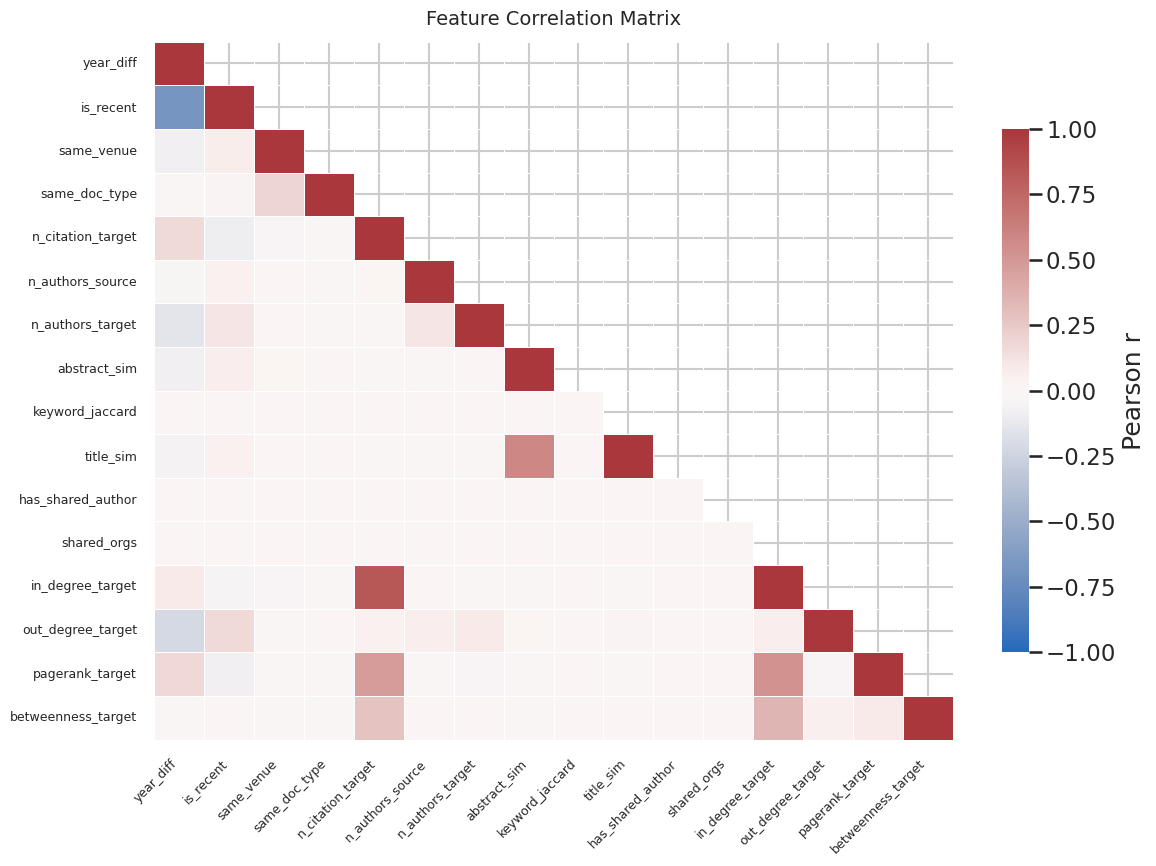

Top absolute correlations:
        feature_1          feature_2   corr
n_citation_target   in_degree_target  0.839
        year_diff          is_recent -0.679
     abstract_sim          title_sim  0.582
 in_degree_target    pagerank_target  0.525
n_citation_target    pagerank_target  0.482
 in_degree_target betweenness_target  0.348
n_citation_target betweenness_target  0.274
        year_diff  out_degree_target -0.218
       same_venue      same_doc_type  0.191
        year_diff    pagerank_target  0.174


In [147]:
# Correlation matrix on feature-selection sample
corr_matrix = X_train_fs_raw[ALL_FEATURES].corr()

corr_plot = corr_matrix.fillna(0)
mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_plot,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
)

plt.title("Feature Correlation Matrix", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

top_corr = (
    upper.stack()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_corr.columns = ["feature_1", "feature_2", "abs_corr"]
top_corr["corr"] = [
    corr_matrix.loc[row.feature_1, row.feature_2]
    for row in top_corr.itertuples()
]

print("Top absolute correlations:")
print(top_corr[["feature_1", "feature_2", "corr"]].round(3).to_string(index=False))




In [148]:
CORR_THRESHOLD = 0.85

print(f"\nHighly correlated pairs (|r| > {CORR_THRESHOLD}):\n")

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if pd.notna(r) and abs(r) > CORR_THRESHOLD:
            f1 = corr_matrix.columns[i]
            f2 = corr_matrix.columns[j]
            high_corr_pairs.append((f1, f2, r))
            print(f"  {f1:25s} <-> {f2:25s}  r = {r:+.3f}")

if not high_corr_pairs:
    print("  None found.")


Highly correlated pairs (|r| > 0.85):

  None found.


### 10.2 L1 Logistic Regression Diagnostic

L1 Logistic Regression is used here as a linear sparsity diagnostic.

If increasing regularization removes features, the coefficient path helps identify linearly useful predictors. If the same features survive across almost all regularization strengths, L1 is not treated as the main selector.


In [149]:
# Scale feature-selection sample only
scaler_fs = StandardScaler()
X_train_fs = pd.DataFrame(
    scaler_fs.fit_transform(X_train_fs_raw[ALL_FEATURES]),
    columns=ALL_FEATURES,
)

C_values = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
COEF_THRESHOLD = 1e-3

lasso_results = {}

for c in C_values:
    lr = LogisticRegression(
        penalty="l1",
        C=c,
        solver="saga",
        max_iter=500,
        tol=1e-3,
        random_state=42,
        n_jobs=-1,
    )

    lr.fit(X_train_fs, y_train_fs)

    coefs = pd.Series(lr.coef_[0], index=ALL_FEATURES)
    surviving = coefs[coefs.abs() > COEF_THRESHOLD].index.tolist()

    lasso_results[c] = {
        "coefs": coefs,
        "surviving": surviving,
        "n_surviving": len(surviving),
    }


In [150]:
print("Lasso Diagnostic — Surviving Features per C\n")
print(f"  {'C':>10s}  {'N features':>12s}  Surviving")
print(f"  {'-'*10}  {'-'*12}  {'-'*50}")

for c in C_values:
    r = lasso_results[c]
    print(f"  {c:10.5f}  {r['n_surviving']:12d}  {', '.join(r['surviving'])}")



Lasso Diagnostic — Surviving Features per C

           C    N features  Surviving
  ----------  ------------  --------------------------------------------------
     0.00010             3  abstract_sim, title_sim, in_degree_target
     0.00030             6  year_diff, n_citation_target, abstract_sim, title_sim, in_degree_target, pagerank_target
     0.00100             7  year_diff, same_venue, n_citation_target, abstract_sim, title_sim, in_degree_target, pagerank_target
     0.00300            10  year_diff, same_venue, same_doc_type, n_citation_target, n_authors_source, abstract_sim, title_sim, in_degree_target, out_degree_target, pagerank_target
     0.01000            10  year_diff, same_venue, same_doc_type, n_citation_target, n_authors_source, abstract_sim, title_sim, in_degree_target, out_degree_target, pagerank_target


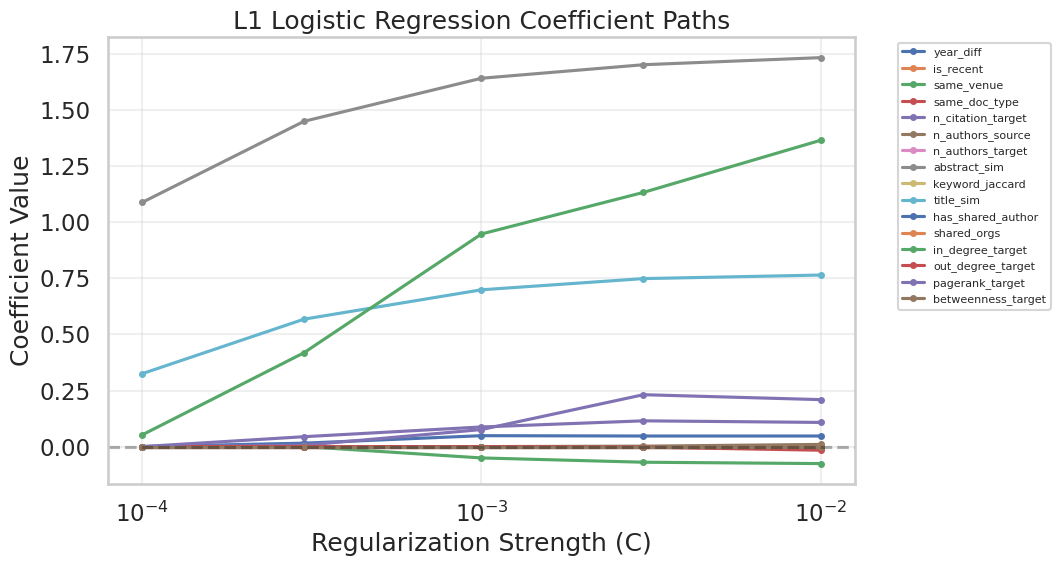

In [151]:
coef_df = pd.DataFrame(
    {c: lasso_results[c]["coefs"] for c in C_values}
).T

coef_df.index.name = "C"

plt.figure(figsize=(11, 6))

for feat in ALL_FEATURES:
    plt.plot(C_values, coef_df[feat], marker="o", markersize=4, label=feat)

plt.xscale("log")
plt.axhline(y=0, color="black", linestyle="--", alpha=0.3)
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Coefficient Value")
plt.title("L1 Logistic Regression Coefficient Paths")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [152]:
# Lasso diagnostic: features that survive across multiple regularization strengths
survival_counts = pd.Series(0, index=ALL_FEATURES)

for c in C_values:
    survival_counts.loc[lasso_results[c]["surviving"]] += 1

LASSO_MIN_SURVIVALS = 3
lasso_selected = set(survival_counts[survival_counts >= LASSO_MIN_SURVIVALS].index)

print(f"\nLasso diagnostic selected features (survive in >= {LASSO_MIN_SURVIVALS} C values):")
print(sorted(lasso_selected))

print("\nLasso survival counts:")
print(
    survival_counts
    .sort_values(ascending=False)
    .to_frame("n_C_values")
    .to_string()
)

print(f"\nLasso diagnostic dropped features:")
print(sorted(set(ALL_FEATURES) - lasso_selected))

if len(lasso_selected) >= len(ALL_FEATURES) * 0.75:
    print(
        "\nNOTE: Lasso did not produce a strongly sparse selection path. "
        "It will be treated as a diagnostic signal, not as the main feature selector."
    )





Lasso diagnostic selected features (survive in >= 3 C values):
['abstract_sim', 'in_degree_target', 'n_citation_target', 'pagerank_target', 'same_venue', 'title_sim', 'year_diff']

Lasso survival counts:
                    n_C_values
abstract_sim                 5
title_sim                    5
in_degree_target             5
year_diff                    4
n_citation_target            4
pagerank_target              4
same_venue                   3
n_authors_source             2
same_doc_type                2
out_degree_target            2
n_authors_target             0
is_recent                    0
shared_orgs                  0
has_shared_author            0
keyword_jaccard              0
betweenness_target           0

Lasso diagnostic dropped features:
['betweenness_target', 'has_shared_author', 'is_recent', 'keyword_jaccard', 'n_authors_source', 'n_authors_target', 'out_degree_target', 'same_doc_type', 'shared_orgs']


### 10.3 LightGBM Feature Importance


LightGBM gain importance is used as the main model-based selection signal.

Unlike L1 Logistic Regression, LightGBM can capture non-linear effects and interactions between metadata, text, and graph features. Features with very low gain are considered weak for the final compact feature set.


In [153]:
lgbm_fs = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=12,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
    importance_type="gain",
)

lgbm_fs.fit(X_train_fs_raw[ALL_FEATURES], y_train_fs)

lgbm_importance = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Gain": lgbm_fs.feature_importances_,
}).sort_values("Gain", ascending=False)

total_gain = lgbm_importance["Gain"].sum()

if total_gain > 0:
    lgbm_importance["Gain_pct"] = lgbm_importance["Gain"] / total_gain * 100
else:
    lgbm_importance["Gain_pct"] = 0.0

lgbm_importance["Cumulative_pct"] = lgbm_importance["Gain_pct"].cumsum()

print("LightGBM Feature Importance (Gain)\n")

for _, row in lgbm_importance.iterrows():
    bar = "#" * int(row["Gain_pct"])
    print(f"  {row['Feature']:25s}  {row['Gain_pct']:5.1f}%  {bar}")



LightGBM Feature Importance (Gain)

  abstract_sim                60.8%  ############################################################
  title_sim                   14.0%  #############
  in_degree_target            12.0%  ###########
  n_citation_target            6.0%  ######
  pagerank_target              2.3%  ##
  betweenness_target           1.3%  #
  out_degree_target            1.2%  #
  year_diff                    1.0%  
  n_authors_target             0.6%  
  n_authors_source             0.4%  
  same_venue                   0.2%  
  same_doc_type                0.1%  
  is_recent                    0.0%  
  shared_orgs                  0.0%  
  keyword_jaccard              0.0%  
  has_shared_author            0.0%  


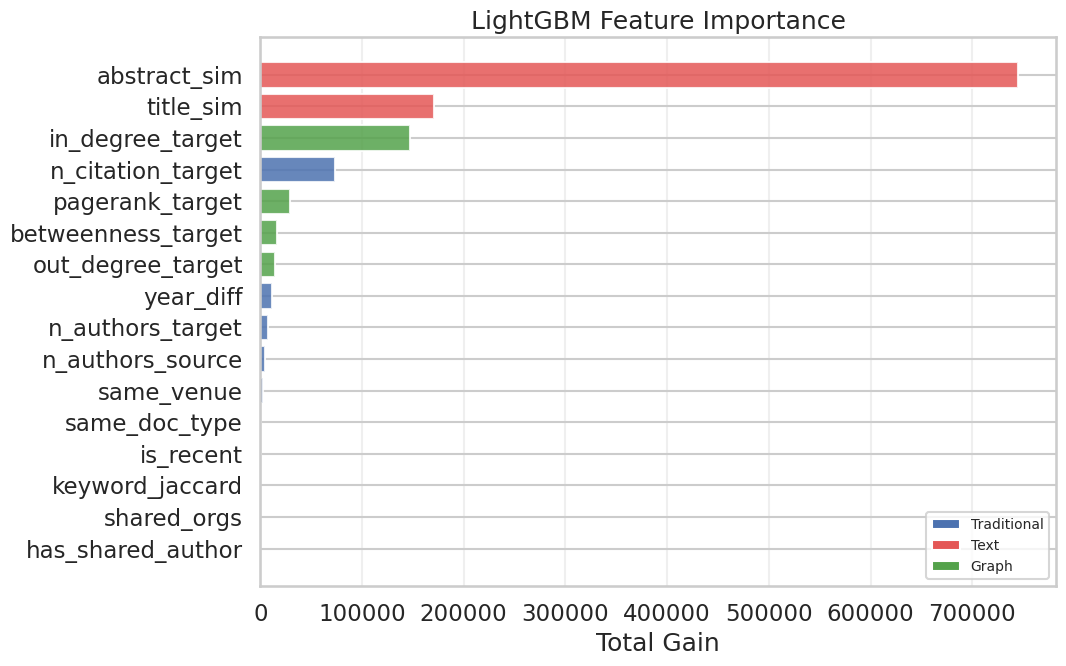


LightGBM selected features (>= 1.0% gain):
['abstract_sim', 'betweenness_target', 'in_degree_target', 'n_citation_target', 'out_degree_target', 'pagerank_target', 'title_sim']

LightGBM dropped features (< 1.0% gain):
['has_shared_author', 'is_recent', 'keyword_jaccard', 'n_authors_source', 'n_authors_target', 'same_doc_type', 'same_venue', 'shared_orgs', 'year_diff']


18949

In [154]:
lgbm_sorted = lgbm_importance.sort_values("Gain", ascending=True)

def get_group(feat):
    if feat in TRADITIONAL_FEATURES:
        return "Traditional"
    elif feat in TEXT_FEATURES:
        return "Text"
    else:
        return "Graph"

group_colors = {
    "Traditional": "#4C72B0",
    "Text": "#E45756",
    "Graph": "#54A24B",
}

colors = [group_colors[get_group(f)] for f in lgbm_sorted["Feature"]]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(lgbm_sorted["Feature"], lgbm_sorted["Gain"], color=colors, alpha=0.85)
ax.set_xlabel("Total Gain")
ax.set_title("LightGBM Feature Importance")

legend_elements = [Patch(facecolor=c, label=g) for g, c in group_colors.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

LGBM_THRESHOLD_PCT = 1.0

lgbm_selected = set(
    lgbm_importance[
        lgbm_importance["Gain_pct"] >= LGBM_THRESHOLD_PCT
    ]["Feature"]
)

lgbm_dropped = set(ALL_FEATURES) - lgbm_selected

print(f"\nLightGBM selected features (>= {LGBM_THRESHOLD_PCT}% gain):")
print(sorted(lgbm_selected))

print(f"\nLightGBM dropped features (< {LGBM_THRESHOLD_PCT}% gain):")
print(sorted(lgbm_dropped))

del lgbm_fs
gc.collect()

### 10.4 Feature Selection Summary

The final selected feature set is based primarily on LightGBM gain importance.

Correlation analysis is used only to inspect redundancy.  
L1 Logistic Regression is used as a linear diagnostic, but if it does not create a strongly sparse path, it is not allowed to dominate the final selection.

`M8 Selected` keeps the strongest non-constant predictors according to LightGBM gain, plus a small set of core temporally valid citation-visibility and text-similarity signals.

In [155]:
# Final selected features for M8.
# Correlation and Lasso are diagnostic.
# LightGBM gain is used as the main selector because it captures non-linear tabular signal.

MIN_FEATURE_STD = 1e-8

feature_std = X_train_fs_raw[ALL_FEATURES].std()

non_constant_features = set(
    feature_std[feature_std > MIN_FEATURE_STD].index
)

selected_by_lgbm = set(lgbm_selected)

CORE_FEATURES = {
    "abstract_sim",
    "title_sim",
    "n_citation_target",
    "in_degree_target",
    "pagerank_target",
}

combined_selected = (selected_by_lgbm | CORE_FEATURES) & non_constant_features
combined_dropped = set(ALL_FEATURES) - combined_selected

SELECTED_FEATURES = [f for f in ALL_FEATURES if f in combined_selected]

if len(SELECTED_FEATURES) == 0:
    raise ValueError("Feature selection selected zero features. Check LightGBM threshold and feature variance.")

print("Feature Selection Summary\n")
print(f"  {'Feature':25s}  {'Lasso':>8s}  {'LightGBM':>10s}  {'Final':>10s}")
print(f"  {'-'*25}  {'-'*8}  {'-'*10}  {'-'*10}")

for feat in ALL_FEATURES:
    in_lasso = "yes" if feat in lasso_selected else "no"
    in_lgbm = "yes" if feat in lgbm_selected else "no"
    decision = "KEEP" if feat in combined_selected else "DROP"
    print(f"  {feat:25s}  {in_lasso:>8s}  {in_lgbm:>10s}  {decision:>10s}")

print(f"\n  Total:   {len(ALL_FEATURES)} -> {len(SELECTED_FEATURES)} features")
print(f"  Kept:    {SELECTED_FEATURES}")
print(f"  Dropped: {sorted(combined_dropped)}")



Feature Selection Summary

  Feature                       Lasso    LightGBM       Final
  -------------------------  --------  ----------  ----------
  year_diff                       yes          no        DROP
  is_recent                        no          no        DROP
  same_venue                      yes          no        DROP
  same_doc_type                    no          no        DROP
  n_citation_target               yes         yes        KEEP
  n_authors_source                 no          no        DROP
  n_authors_target                 no          no        DROP
  abstract_sim                    yes         yes        KEEP
  keyword_jaccard                  no          no        DROP
  title_sim                       yes         yes        KEEP
  has_shared_author                no          no        DROP
  shared_orgs                      no          no        DROP
  in_degree_target                yes         yes        KEEP
  out_degree_target                no      

### 10.5 Update Feature Combinations

We add an M8 combination using only the selected features, while keeping
M1–M7 intact to compare the effect of feature selection.


In [156]:
FEATURE_COMBINATIONS["M8 Selected"] = SELECTED_FEATURES

print("Updated feature combinations:")
for name, feats in FEATURE_COMBINATIONS.items():
    marker = "  <- feature selection" if name == "M8 Selected" else ""
    print(f"  {name:30s} -> {len(feats):2d} features{marker}")



Updated feature combinations:
  M1 Traditional                 ->  7 features
  M2 Text                        ->  3 features
  M3 Graph                       ->  6 features
  M4 Traditional + Text          -> 10 features
  M5 Traditional + Graph         -> 13 features
  M6 Text + Graph                ->  9 features
  M7 All                         -> 16 features
  M8 Selected                    ->  7 features  <- feature selection


## 11. Classification 


We train models using different combinations of feature groups to understand
the contribution of each group to the citation prediction task.

**Models**

We use two classifiers with different characteristics:

- **Logistic Regression** (cuML, GPU): a linear model that serves as our
  interpretable baseline. If a simple linear combination of features can
  predict citations well, we don't need complex models. Requires feature
  scaling since it's sensitive to different magnitudes.

- **LightGBM** (GPU): a gradient boosting model, generally the best
  performer on tabular data. Builds trees sequentially, each one correcting
  the errors of the previous. Handles mixed feature types (continuous and
  binary) naturally, doesn't require scaling, and is very fast on GPU.

**Feature Combinations**

We train each model on 7 feature subsets to isolate the contribution
of each group:

| Model | Features | Purpose |
|-------|----------|---------|
| M1 | Traditional | Can metadata alone predict citations? |
| M2 | Text | Can topic similarity alone predict citations? |
| M3 | Graph | Can network structure alone predict citations? |
| M4 | Traditional + Text | Does content improve metadata? |
| M5 | Traditional + Graph | Does network improve metadata? |
| M6 | Text + Graph | How do content and network combine? |
| M7 | All | What is the performance ceiling? |
| M8 | Selected Features | how the feature selection impact |

**Evaluation**

We evaluate using three metrics:
- **Accuracy**: overall correctness.
- **F1 Score**: harmonic mean of precision and recall, robust to imbalance.
- **AUC-ROC**: measures ranking quality, how well the model separates
  positive from negative pairs regardless of threshold.

We train on the train set and evaluate on the validation set.
The test set is held out for final evaluation of the best model.

**Total: 2 models × 7 combinations = 14 experiments.**


### 11.1. Model Definitions

In [157]:
def get_lgbm_model():
    """LightGBM with GPU acceleration."""
    return lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=12,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        # device="gpu",
        random_state=42,
        verbose=-1,
        n_jobs=-1,
    )


def get_logistic_model():
    """Logistic Regression (cuML GPU or sklearn CPU)."""
    if USE_CUML:
        return cuLogisticRegression(
            max_iter=1000,
            tol=1e-4,
        )
    else:
        return SklearnLogisticRegression(
            max_iter=1000,
            tol=1e-4,
            solver="saga",
            n_jobs=-1,
            random_state=42,
        )


MODEL_FACTORIES = {
    "LightGBM": get_lgbm_model,
    "LogisticRegression": get_logistic_model,
}


### 11.2. Training and Evaluation

In [158]:
def evaluate_model(model, X, y):
    """Compute accuracy, F1, and AUC for a fitted model."""
    y_pred = model.predict(X)
    y_proba = np.asarray(model.predict_proba(X))[:, 1]
    
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "AUC": roc_auc_score(y, y_proba),
    }

SCALER_PATH = DATA_DIR / "scaler.joblib"

if SCALER_PATH.exists():
    scaler = joblib.load(SCALER_PATH)
    scaler_features = list(getattr(scaler, "feature_names_in_", ALL_FEATURES))
    scaler_needs_refit = (
        getattr(scaler, "n_features_in_", len(ALL_FEATURES)) != len(ALL_FEATURES)
        or scaler_features != list(ALL_FEATURES)
    )
    if scaler_needs_refit:
        print(f"[REFIT] Existing scaler does not match the current {len(ALL_FEATURES)} modeling features")
        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=ALL_FEATURES)
        joblib.dump(scaler, SCALER_PATH)
    else:
        print(f"[SKIP] Loading scaler from {SCALER_PATH}")
        X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=ALL_FEATURES)
else:
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=ALL_FEATURES)
    joblib.dump(scaler, SCALER_PATH)
    print(f"  Scaler saved → {SCALER_PATH}")

X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=ALL_FEATURES)

  Scaler saved → data/scaler.joblib


In [159]:
MODELS_DIR = DATA_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_PATH = DATA_DIR / "training_results.joblib"

results = []
trained_models = {}
trained_model_lookup = {}

for model_name, model_factory in MODEL_FACTORIES.items():
    print(f"\n  {model_name}")
    
    for combo_name, feature_list in FEATURE_COMBINATIONS.items():
        model_path = MODELS_DIR / f"{model_name}_{combo_name}.joblib"

        if model_name == "LogisticRegression":
            X_tr = X_train_scaled[feature_list]
            X_va = X_val_scaled[feature_list]
        else:
            X_tr = X_train[feature_list]
            X_va = X_val[feature_list]

        if model_path.exists():
            print(f"  [SKIP] {combo_name:30s} — loading from disk")
            model = joblib.load(model_path)
            train_time = 0.0
        else:
            t0 = time.time()
            model = model_factory()
            model.fit(X_tr, y_train)
            train_time = time.time() - t0
            joblib.dump(model, model_path)

        trained_model_lookup[(model_name, combo_name)] = model

        metrics = evaluate_model(model, X_va, y_val)

        results.append({
            "Model": model_name,
            "Features": combo_name,
            "N_Features": len(feature_list),
            "Accuracy": metrics["Accuracy"],
            "F1": metrics["F1"],
            "AUC": metrics["AUC"],
            "Time (s)": round(train_time, 1),
        })

        if combo_name == "M7 All":
            trained_models[model_name] = model

        print(f"  {combo_name:30s} | Acc={metrics['Accuracy']:.4f} | F1={metrics['F1']:.4f} | AUC={metrics['AUC']:.4f}")

joblib.dump(results, RESULTS_PATH)


  LightGBM
  M1 Traditional                 | Acc=0.4671 | F1=0.2367 | AUC=0.6079
  M2 Text                        | Acc=0.8047 | F1=0.4837 | AUC=0.8583
  M3 Graph                       | Acc=0.6623 | F1=0.2775 | AUC=0.6346
  M4 Traditional + Text          | Acc=0.8009 | F1=0.4936 | AUC=0.8815
  M5 Traditional + Graph         | Acc=0.8215 | F1=0.2659 | AUC=0.6152
  M6 Text + Graph                | Acc=0.8394 | F1=0.5375 | AUC=0.8882
  M7 All                         | Acc=0.8754 | F1=0.5351 | AUC=0.8433
  M8 Selected                    | Acc=0.8771 | F1=0.5368 | AUC=0.8451

  LogisticRegression
  M1 Traditional                 | Acc=0.2038 | F1=0.2161 | AUC=0.5817
  M2 Text                        | Acc=0.8379 | F1=0.5148 | AUC=0.8564
  M3 Graph                       | Acc=0.5433 | F1=0.2325 | AUC=0.5750
  M4 Traditional + Text          | Acc=0.8399 | F1=0.5329 | AUC=0.8790
  M5 Traditional + Graph         | Acc=0.3042 | F1=0.2181 | AUC=0.5806
  M6 Text + Graph                | Acc=0.85

['data/training_results.joblib']

### 11.3. Results Comparison

In [160]:
if not results:
    results = joblib.load(RESULTS_PATH)

results_df = pd.DataFrame(results)
display(results_df.round(4))

,Model,Features,N_Features,Accuracy,F1,AUC,Time (s)
0,LightGBM,M1 Traditional,7,0.4671,0.2367,0.6079,11.3
1,LightGBM,M2 Text,3,0.8047,0.4837,0.8583,11.1
2,LightGBM,M3 Graph,6,0.6623,0.2775,0.6346,9.0
3,LightGBM,M4 Traditional + Text,10,0.8009,0.4936,0.8815,14.8
4,LightGBM,M5 Traditional + Graph,13,0.8215,0.2659,0.6152,12.3
5,LightGBM,M6 Text + Graph,9,0.8394,0.5375,0.8882,10.6
6,LightGBM,M7 All,16,0.8754,0.5351,0.8433,15.0
7,LightGBM,M8 Selected,7,0.8771,0.5368,0.8451,13.7
8,LogisticRegression,M1 Traditional,7,0.2038,0.2161,0.5817,8.4
9,LogisticRegression,M2 Text,3,0.8379,0.5148,0.8564,8.2


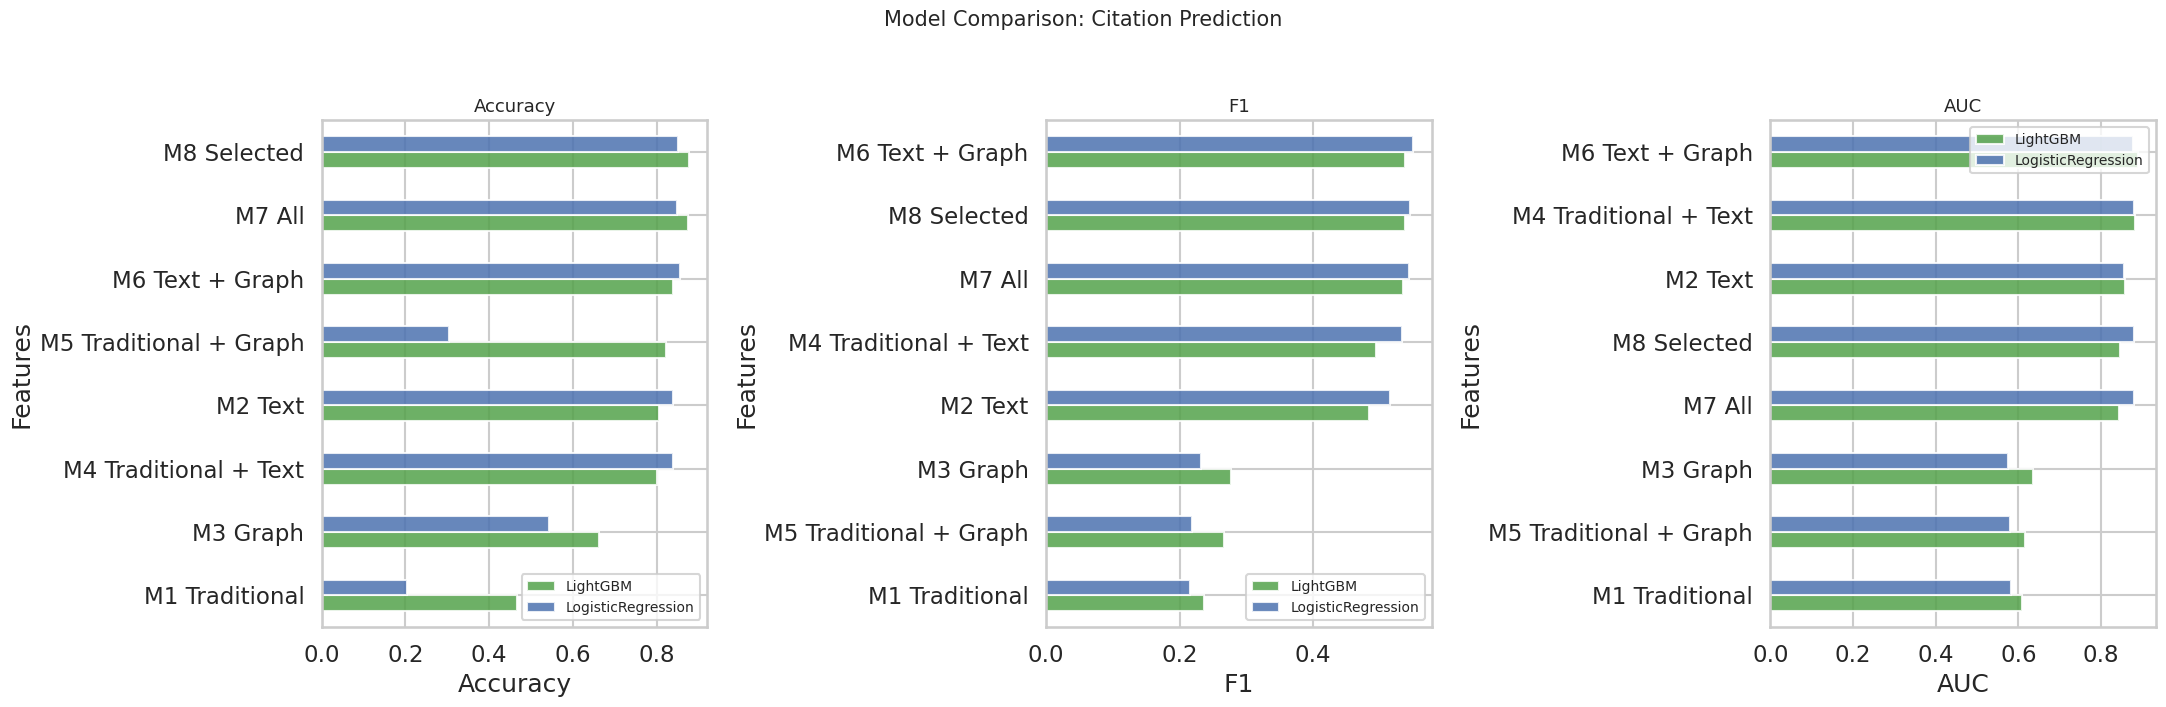

In [161]:
# Results Comparison

#sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
metrics_to_plot = ["Accuracy", "F1", "AUC"]
colors = {"LightGBM": "#54A24B", "LogisticRegression": "#4C72B0"}

for ax, metric in zip(axes, metrics_to_plot):
    pivot = results_df.pivot(index="Features", columns="Model", values=metric)
    pivot = pivot.sort_values(by=pivot.columns[0], ascending=True)
    
    pivot.plot(kind="barh", ax=ax, color=[colors[c] for c in pivot.columns], alpha=0.85)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontsize=13)
    ax.legend(fontsize=10)

plt.suptitle("Model Comparison: Citation Prediction", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()



In [162]:
# Best Model per Feature Combination 
print("── Best model per feature combination (AUC) ──\n")
for combo in FEATURE_COMBINATIONS.keys():
    subset = results_df[results_df["Features"] == combo]
    best = subset.loc[subset["AUC"].idxmax()]
    print(f"  {combo:30s} -> {best['Model']:20s} (AUC={best['AUC']:.4f})")


── Best model per feature combination (AUC) ──

  M1 Traditional                 -> LightGBM             (AUC=0.6079)
  M2 Text                        -> LightGBM             (AUC=0.8583)
  M3 Graph                       -> LightGBM             (AUC=0.6346)
  M4 Traditional + Text          -> LightGBM             (AUC=0.8815)
  M5 Traditional + Graph         -> LightGBM             (AUC=0.6152)
  M6 Text + Graph                -> LightGBM             (AUC=0.8882)
  M7 All                         -> LogisticRegression   (AUC=0.8788)
  M8 Selected                    -> LogisticRegression   (AUC=0.8783)


### 11.4. Feature Importance and ROC Analysis

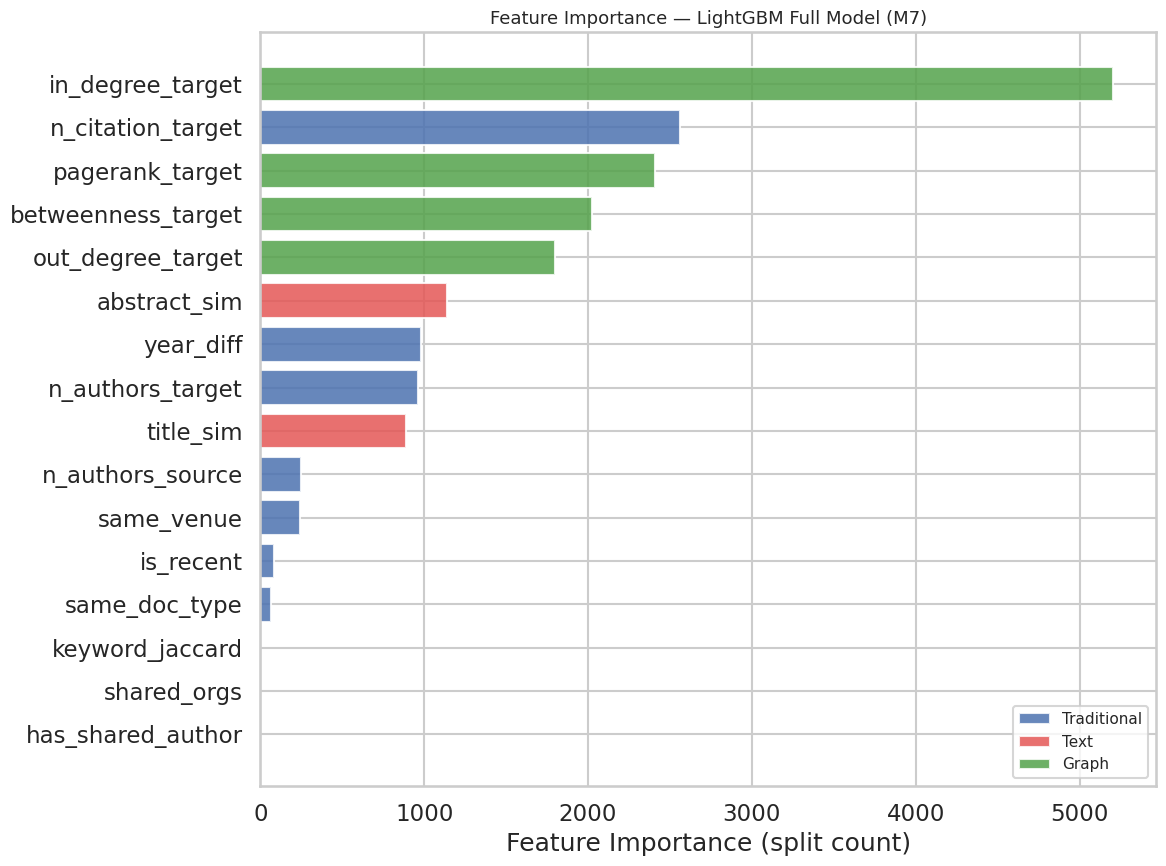

,Feature,Importance,Group
12,in_degree_target,5205,Graph
4,n_citation_target,2558,Traditional
14,pagerank_target,2411,Graph
15,betweenness_target,2023,Graph
13,out_degree_target,1796,Graph
7,abstract_sim,1141,Text
0,year_diff,978,Traditional
6,n_authors_target,964,Traditional
9,title_sim,887,Text
5,n_authors_source,245,Traditional


In [163]:
lgbm_full = trained_models.get("LightGBM")
if lgbm_full is not None:
    m7_features = list(FEATURE_COMBINATIONS["M7 All"])
    importance_df = pd.DataFrame({
        "Feature": m7_features,
        "Importance": lgbm_full.feature_importances_
    }).sort_values("Importance", ascending=True)
    
    def get_group(feat):
        if feat in TRADITIONAL_FEATURES:
            return "Traditional"
        elif feat in TEXT_FEATURES:
            return "Text"
        else:
            return "Graph"
    
    importance_df["Group"] = importance_df["Feature"].apply(get_group)
    group_colors = {"Traditional": "#4C72B0", "Text": "#E45756", "Graph": "#54A24B"}
    
    plt.figure(figsize=(12, 9))
    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"],
        color=[group_colors[g] for g in importance_df["Group"]],
        alpha=0.85
    )
    
    legend_elements = [Patch(facecolor=c, label=g, alpha=0.85) for g, c in group_colors.items()]
    plt.legend(handles=legend_elements, loc="lower right", fontsize=11)
    
    plt.xlabel("Feature Importance (split count)")
    plt.title("Feature Importance — LightGBM Full Model (M7)", fontsize=13)
    plt.tight_layout()
    plt.show()
    
    display(importance_df.sort_values("Importance", ascending=False).round(4))


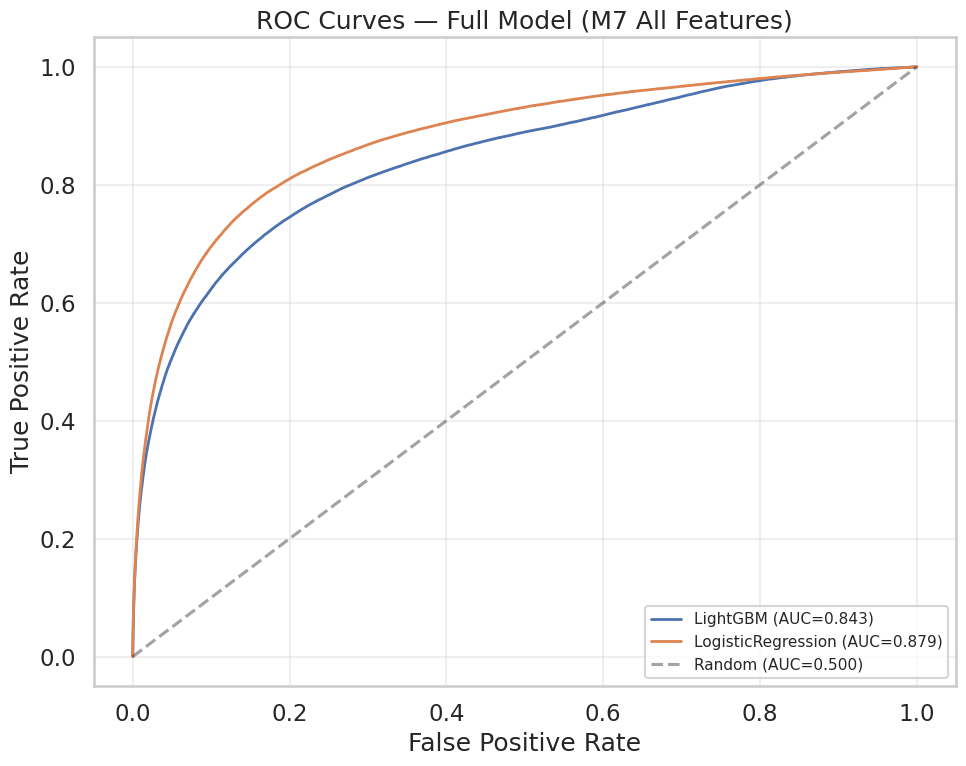

In [164]:
# ROC Curves — Full Model (M7)
m7_features = FEATURE_COMBINATIONS["M7 All"]

plt.figure(figsize=(10, 8))

for model_name, model in trained_models.items():
    if model_name == "LogisticRegression":
        X_eval = X_val_scaled[m7_features]
    else:
        X_eval = X_val[m7_features]
    
    y_proba = np.asarray(model.predict_proba(X_eval))[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_val = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Full Model (M7 All Features)")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

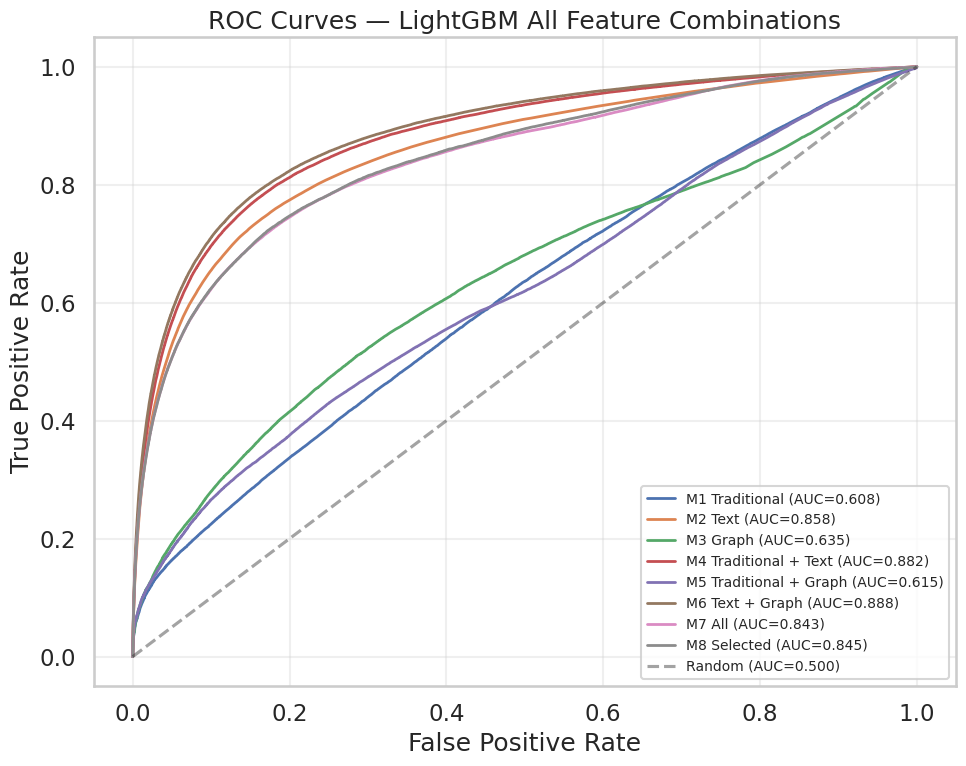

In [165]:
# ROC Curves — LightGBM all combinations
plt.figure(figsize=(10, 8))

for combo_name, feature_list in FEATURE_COMBINATIONS.items():
    model = trained_model_lookup.get(("LightGBM", combo_name))

    if model is None:
        model_path = MODELS_DIR / f"LightGBM_{combo_name}.joblib"
        if not model_path.exists():
            print(f"[WARN] Missing LightGBM model for {combo_name}, skipping.")
            continue
        model = joblib.load(model_path)

    y_proba = np.asarray(model.predict_proba(X_val[feature_list]))[:, 1]

    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_val = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, label=f"{combo_name} (AUC={auc_val:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — LightGBM All Feature Combinations")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [166]:
# Classification Report — Best Model
best_row = results_df.loc[results_df["AUC"].idxmax()]
best_model_name = best_row["Model"]
best_combo = best_row["Features"]

print(f"Best model: {best_model_name} with {best_combo}")
print(f"AUC: {best_row['AUC']:.4f}\n")

best_features = FEATURE_COMBINATIONS[best_combo]
if "trained_model_lookup" in globals():
    best_model = trained_model_lookup[(best_model_name, best_combo)]
else:
    best_model = joblib.load(MODELS_DIR / f"{best_model_name}_{best_combo}.joblib")

if best_model_name == "LogisticRegression":
    X_eval = X_val_scaled[best_features]
else:
    X_eval = X_val[best_features]

y_pred = best_model.predict(X_eval)
print(classification_report(y_val, y_pred, target_names=["No Citation", "Citation"]))


Best model: LightGBM with M6 Text + Graph
AUC: 0.8882

              precision    recall  f1-score   support

 No Citation       0.97      0.85      0.90    750689
    Citation       0.41      0.78      0.54    101767

    accuracy                           0.84    852456
   macro avg       0.69      0.81      0.72    852456
weighted avg       0.90      0.84      0.86    852456



In [167]:
# Group Contribution Analysis 

best_type = best_model_name
r = results_df[results_df["Model"] == best_type].set_index("Features")

print(f"── Marginal contribution of each group ({best_type}, AUC) ──\n")

delta_text = r.loc["M4 Traditional + Text", "AUC"] - r.loc["M1 Traditional", "AUC"]
print(f"  Traditional → +Text:  {delta_text:+.4f} AUC")

delta_graph = r.loc["M5 Traditional + Graph", "AUC"] - r.loc["M1 Traditional", "AUC"]
print(f"  Traditional → +Graph: {delta_graph:+.4f} AUC")

delta_text2 = r.loc["M6 Text + Graph", "AUC"] - r.loc["M3 Graph", "AUC"]
print(f"  Graph       → +Text:  {delta_text2:+.4f} AUC")

delta_graph2 = r.loc["M6 Text + Graph", "AUC"] - r.loc["M2 Text", "AUC"]
print(f"  Text        → +Graph: {delta_graph2:+.4f} AUC")

best_duo_name = max(
    ["M4 Traditional + Text", "M5 Traditional + Graph", "M6 Text + Graph"],
    key=lambda m: r.loc[m, "AUC"]
)
delta_all = r.loc["M7 All", "AUC"] - r.loc[best_duo_name, "AUC"]
print(f"\n  Best pair ({best_duo_name}) → +All: {delta_all:+.4f} AUC")

print(f"\n── Summary ──")
best_single = max(["M1 Traditional", "M2 Text", "M3 Graph"], key=lambda m: r.loc[m, "AUC"])
print(f"  Best single group: {best_single} (AUC={r.loc[best_single, 'AUC']:.4f})")
print(f"  Best pair:         {best_duo_name} (AUC={r.loc[best_duo_name, 'AUC']:.4f})")
print(f"  Full model:        M7 All (AUC={r.loc['M7 All', 'AUC']:.4f})")



── Marginal contribution of each group (LightGBM, AUC) ──

  Traditional → +Text:  +0.2737 AUC
  Traditional → +Graph: +0.0074 AUC
  Graph       → +Text:  +0.2536 AUC
  Text        → +Graph: +0.0299 AUC

  Best pair (M6 Text + Graph) → +All: -0.0449 AUC

── Summary ──
  Best single group: M2 Text (AUC=0.8583)
  Best pair:         M6 Text + Graph (AUC=0.8882)
  Full model:        M7 All (AUC=0.8433)


### 11.5. Final Evaluation on Test Set

FINAL EVALUATION ON TEST SET — VALIDATION-SELECTED MODEL
Selected on validation: LightGBM | M6 Text + Graph
Validation AUC: 0.8882
N features: 9

Test set: 897,516 pairs
Test labels: {0: 795107, 1: 102409}

--------------------------------------------------
Test results: LightGBM | M6 Text + Graph
Accuracy: 0.8520
F1:       0.5421
AUC:      0.8888

Classification report:
              precision    recall  f1-score   support

 No Citation       0.97      0.86      0.91    795107
    Citation       0.42      0.77      0.54    102409

    accuracy                           0.85    897516
   macro avg       0.69      0.82      0.73    897516
weighted avg       0.90      0.85      0.87    897516



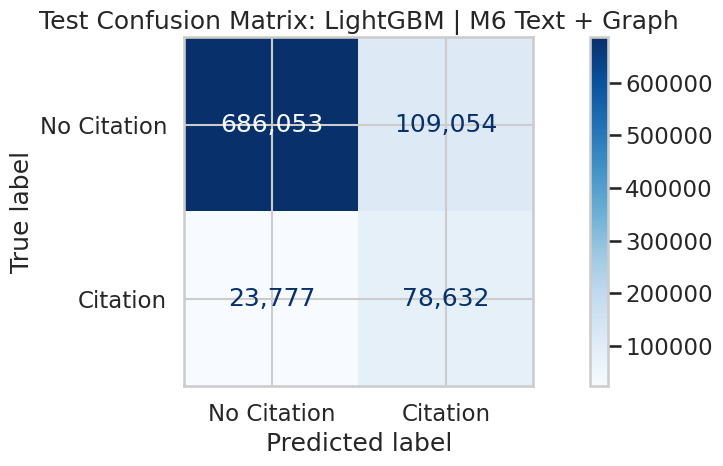

63512

In [168]:
# Final Evaluation on Test Set — validation-selected model
print("FINAL EVALUATION ON TEST SET — VALIDATION-SELECTED MODEL")

best_row = results_df.loc[results_df["AUC"].idxmax()]
best_model_name = best_row["Model"]
best_combo = best_row["Features"]
best_features = FEATURE_COMBINATIONS[best_combo]

print(f"Selected on validation: {best_model_name} | {best_combo}")
print(f"Validation AUC: {best_row['AUC']:.4f}")
print(f"N features: {len(best_features)}")

test = pd.read_parquet(
    DATA_DIR / "test_features_final.parquet",
    columns=["label"] + ALL_FEATURES,
)

y_test = test["label"].values

print(f"\nTest set: {len(test):,} pairs")
print(f"Test labels: {pd.Series(y_test).value_counts().to_dict()}")

best_model = trained_model_lookup.get((best_model_name, best_combo))

if best_model is None:
    model_path = MODELS_DIR / f"{best_model_name}_{best_combo}.joblib"
    if not model_path.exists():
        raise FileNotFoundError(f"Missing selected model: {model_path}")
    best_model = joblib.load(model_path)

if best_model_name == "LogisticRegression":
    X_test_all = test[ALL_FEATURES].astype(np.float32)
    X_test_scaled_all = pd.DataFrame(
        scaler.transform(X_test_all),
        columns=ALL_FEATURES,
    )
    X_test_eval = X_test_scaled_all[best_features]
else:
    X_test_eval = test[best_features].astype(np.float32)

y_pred = np.asarray(best_model.predict(X_test_eval)).ravel()
y_proba = np.asarray(best_model.predict_proba(X_test_eval))[:, 1]

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba),
}

print(f"\n{'-'*50}")
print(f"Test results: {best_model_name} | {best_combo}")
print(f"Accuracy: {test_metrics['Accuracy']:.4f}")
print(f"F1:       {test_metrics['F1']:.4f}")
print(f"AUC:      {test_metrics['AUC']:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["No Citation", "Citation"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Citation", "Citation"],
)
disp.plot(cmap="Blues", values_format=",d")
plt.title(f"Test Confusion Matrix: {best_model_name} | {best_combo}")
plt.tight_layout()
plt.show()

del test
if "X_test_all" in globals():
    del X_test_all
if "X_test_scaled_all" in globals():
    del X_test_scaled_all
del X_test_eval, y_pred, y_proba
gc.collect()


### Validation Feature Contrast

After the final test evaluation, we inspect how the engineered features differ between observed citations and matched non-citations on the validation set.

This is descriptive only. It reflects the constructed pair-classification task and the matched negative sampling strategy; it is not a causal estimate.


In [236]:
feature_groups = {
    **{f: "Traditional" for f in TRADITIONAL_FEATURES},
    **{f: "Text" for f in TEXT_FEATURES},
    **{f: "Graph" for f in GRAPH_FEATURES},
}


           feature  non_citation  citation    delta  standardized_delta       group
      abstract_sim        0.0523    0.1763   0.1240              1.5985        Text
         title_sim        0.0207    0.1476   0.1269              1.4022        Text
 n_citation_target       52.0028  406.3674 354.3647              0.4902 Traditional
  in_degree_target       51.9232  405.8616 353.9384              0.4896       Graph
   pagerank_target        0.0000    0.0000   0.0000              0.4019       Graph
betweenness_target        0.0000    0.0000   0.0000              0.1971       Graph
 out_degree_target       18.6155   20.6831   2.0677              0.1101       Graph
         year_diff        6.3978    6.7076   0.3098              0.0580 Traditional
     same_doc_type        0.6540    0.6358  -0.0181             -0.0381 Traditional
  n_authors_target        3.8483    4.0228   0.1744              0.0356 Traditional
        same_venue        0.0666    0.0580  -0.0086             -0.0348 Trad

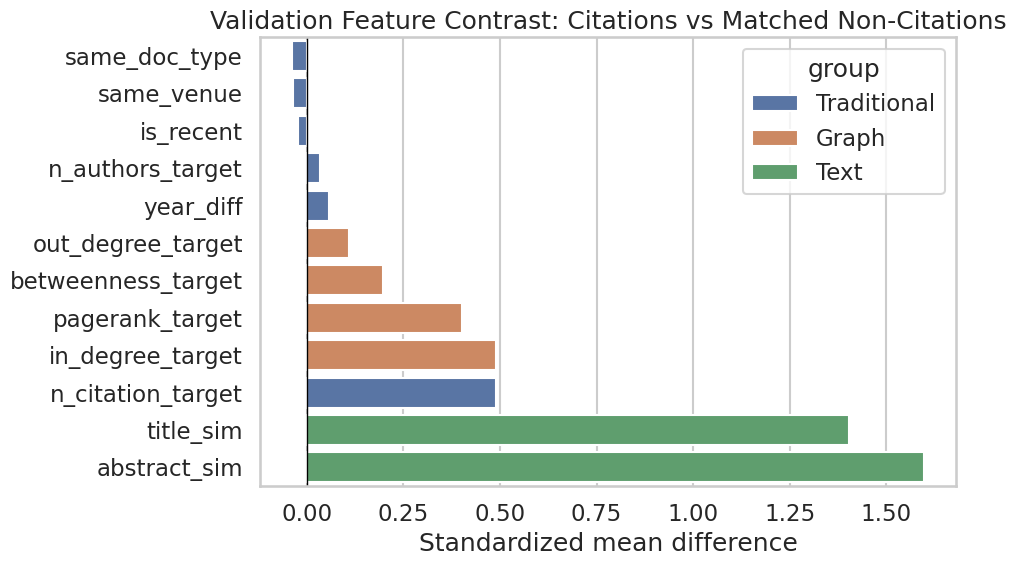

5450

In [237]:
VAL_SAMPLE_SIZE = 200_000
val_feature_path = DATA_DIR / "val_features_final.parquet"

val_sample = pd.read_parquet(
    val_feature_path,
    columns=["label"] + ALL_FEATURES,
)

if len(val_sample) > VAL_SAMPLE_SIZE:
    val_sample = val_sample.sample(VAL_SAMPLE_SIZE, random_state=42)

label_means = val_sample.groupby("label")[ALL_FEATURES].mean().T
label_means = label_means.rename(columns={0: "non_citation", 1: "citation"})

feature_std = val_sample[ALL_FEATURES].std().replace(0, np.nan)

contrast = label_means.copy()
contrast["delta"] = contrast["citation"] - contrast["non_citation"]
contrast["standardized_delta"] = contrast["delta"] / feature_std
contrast["group"] = [feature_groups[f] for f in contrast.index]

contrast = contrast.reset_index().rename(columns={"index": "feature"})
contrast = contrast.sort_values("standardized_delta", key=lambda s: s.abs(), ascending=False)

print(contrast.round(4).to_string(index=False))

plt.figure(figsize=(10, 6))
plot_contrast = contrast.head(12).sort_values("standardized_delta")
sns.barplot(
    data=plot_contrast,
    x="standardized_delta",
    y="feature",
    hue="group",
    dodge=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Validation Feature Contrast: Citations vs Matched Non-Citations")
plt.xlabel("Standardized mean difference")
plt.ylabel("")
plt.tight_layout()
plt.show()

del val_sample
gc.collect()

### SHAP Interpretation

SHAP is used to inspect how the best LightGBM model uses the engineered features.

If the validation-selected model is LightGBM, this explains the selected model.  
If the validation-selected model is Logistic Regression, this explains the best LightGBM model instead, because TreeSHAP is designed for tree ensembles.

SHAP values describe model behavior, not causal effects.


SHAP model: LightGBM | M6 Text + Graph
Validation AUC of inspected LightGBM: 0.8882

SHAP feature importance:
           feature group  mean_abs_shap
      abstract_sim  Text        1.22360
  in_degree_target Graph        0.63468
         title_sim  Text        0.41561
 out_degree_target Graph        0.13005
   pagerank_target Graph        0.12882
betweenness_target Graph        0.08697
       shared_orgs Graph        0.00000
   keyword_jaccard  Text        0.00000
 has_shared_author Graph        0.00000

SHAP importance by feature group:
group  mean_abs_shap  share_pct
 Text         1.6392    62.5719
Graph         0.9805    37.4281


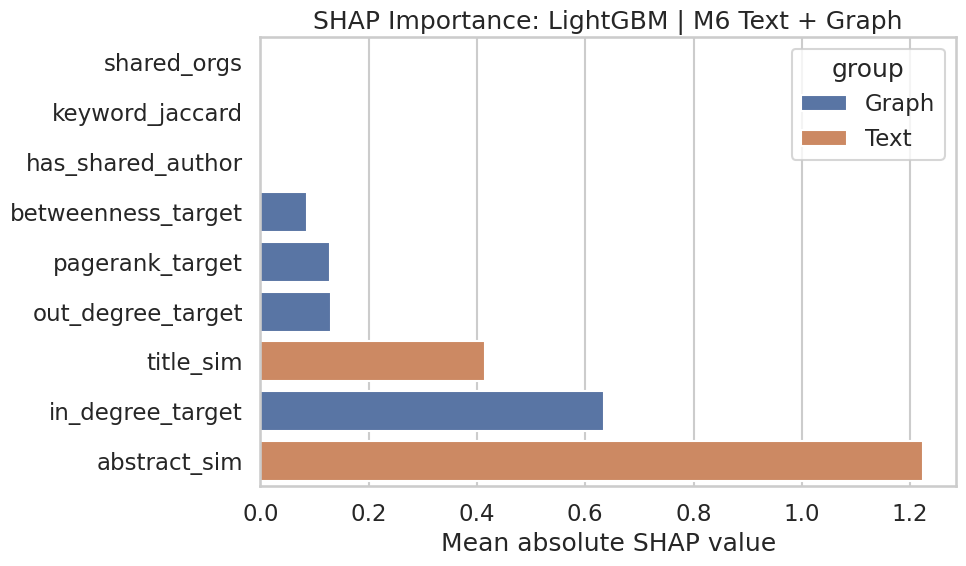

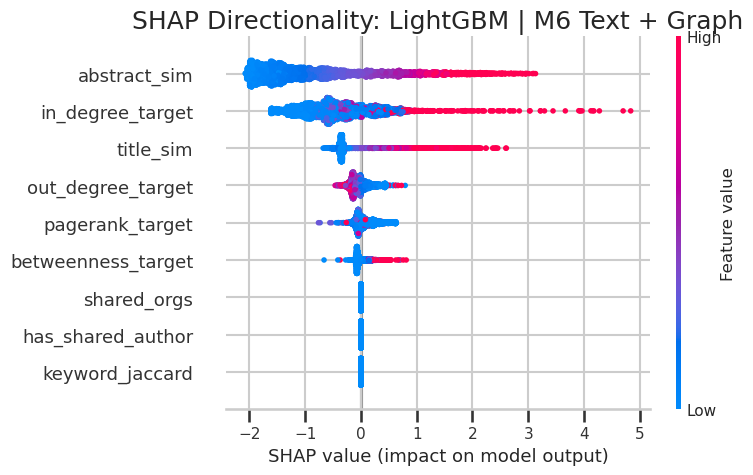

8160

In [238]:
import shap

SHAP_SAMPLE_SIZE = 5_000

lightgbm_results = results_df[results_df["Model"] == "LightGBM"].copy()

if lightgbm_results.empty:
    raise ValueError("No LightGBM results found in results_df. Cannot run TreeSHAP.")

best_lgbm_row = lightgbm_results.sort_values("AUC", ascending=False).iloc[0]
best_lgbm_combo = best_lgbm_row["Features"]
best_lgbm_features = FEATURE_COMBINATIONS[best_lgbm_combo]

shap_model_path = MODELS_DIR / f"LightGBM_{best_lgbm_combo}.joblib"

if not shap_model_path.exists():
    raise FileNotFoundError(f"Missing LightGBM model for SHAP: {shap_model_path}")

shap_model = joblib.load(shap_model_path)

shap_df = pd.read_parquet(
    DATA_DIR / "val_features_final.parquet",
    columns=["label"] + best_lgbm_features,
)

if len(shap_df) > SHAP_SAMPLE_SIZE:
    shap_df = shap_df.sample(SHAP_SAMPLE_SIZE, random_state=42)

X_shap = shap_df[best_lgbm_features].astype(np.float32)

explainer = shap.TreeExplainer(shap_model)
raw_shap_values = explainer.shap_values(X_shap)

if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[1] if len(raw_shap_values) > 1 else raw_shap_values[0]
else:
    shap_values = raw_shap_values
    if getattr(shap_values, "ndim", 2) == 3:
        shap_values = shap_values[:, :, 1]

shap_importance = pd.DataFrame({
    "feature": best_lgbm_features,
    "group": [feature_groups[f] for f in best_lgbm_features],
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(f"SHAP model: LightGBM | {best_lgbm_combo}")
print(f"Validation AUC of inspected LightGBM: {best_lgbm_row['AUC']:.4f}")

print("\nSHAP feature importance:")
print(shap_importance.round(5).to_string(index=False))

group_shap = (
    shap_importance
    .groupby("group", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)

group_shap["share_pct"] = (
    group_shap["mean_abs_shap"] / group_shap["mean_abs_shap"].sum() * 100
)

print("\nSHAP importance by feature group:")
print(group_shap.round(4).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=shap_importance.head(12).sort_values("mean_abs_shap"),
    x="mean_abs_shap",
    y="feature",
    hue="group",
    dodge=False,
)

plt.title(f"SHAP Importance: LightGBM | {best_lgbm_combo}")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("")
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=best_lgbm_features,
    max_display=min(16, len(best_lgbm_features)),
    show=False,
)

plt.title(f"SHAP Directionality: LightGBM | {best_lgbm_combo}")
plt.tight_layout()
plt.show()

del shap_df, X_shap
gc.collect()

## 12 Future Citation Prediction for Year X

The classification model can also be used as a year-specific prediction tool.

Given a prediction year `X`, we select source papers published in year `X` and score their candidate target papers. The model outputs a citation probability for each `(source_id, target_id)` pair.

This is not a full-universe citation forecast unless the candidate generation step includes all possible target papers. In this notebook, predictions are made within the generated candidate pair set: observed citations plus matched non-citation candidates.

The output is useful for:

- ranking likely future citations for each source paper;
- estimating how many citations a source paper is expected to make within the candidate pool;
- evaluating ranking quality when labels are available.


### 12.1. Year Selection and Scoring

e first select candidate citation pairs whose source paper was published in year X.

The split determines which feature file is used. For example, if year X is in the test period, we use `test_features_final.parquet` and `test_normalized.parquet`. This keeps the temporal evaluation consistent with the rest of the pipeline.

In [ ]:
PREDICTION_YEAR = 2024

prediction_split = "test"
features_path = DATA_DIR / f"{prediction_split}_features_final.parquet"
normalized_path = DATA_DIR / f"{prediction_split}_normalized.parquet"

source_years = pd.read_parquet(
    normalized_path,
    columns=["id", "year"],
).rename(columns={"id": "source_id", "year": "source_year"})

source_years["source_year"] = pd.to_numeric(
    source_years["source_year"],
    errors="coerce",
).astype("Int64")

year_features = pd.read_parquet(
    features_path,
    columns=["source_id", "target_id", "label"] + ALL_FEATURES,
)

year_features = year_features.merge(
    source_years,
    on="source_id",
    how="left",
)

year_features = year_features[
    year_features["source_year"] == PREDICTION_YEAR
].copy()

print(f"Prediction year: {PREDICTION_YEAR}")
print(f"Candidate pairs: {len(year_features):,}")
print(f"Source papers:   {year_features['source_id'].nunique():,}")
print(f"Target papers:   {year_features['target_id'].nunique():,}")
print(f"Labels:          {year_features['label'].value_counts().to_dict()}")

Prediction year: 2024
Candidate pairs: 390,830
Source papers:   39,112
Target papers:   268,200
Labels:          {0: 346878, 1: 43952}


In [170]:
if len(year_features) == 0:
    raise ValueError(f"No candidate pairs found for year {PREDICTION_YEAR}")

model_path = MODELS_DIR / f"{best_model_name}_{best_combo}.joblib"
if not model_path.exists():
    raise FileNotFoundError(f"Missing selected model: {model_path}")

year_model = joblib.load(model_path)

if best_model_name == "LogisticRegression":
    if "scaler" not in globals():
        scaler = joblib.load(SCALER_PATH)

    X_year_all = year_features[ALL_FEATURES].astype(np.float32)
    X_year_scaled = pd.DataFrame(
        scaler.transform(X_year_all),
        columns=ALL_FEATURES,
    )
    X_year = X_year_scaled[best_features]
else:
    X_year = year_features[best_features].astype(np.float32)

year_features["citation_probability"] = np.asarray(
    year_model.predict_proba(X_year)
)[:, 1]

year_features["predicted_label"] = (
    year_features["citation_probability"] >= 0.5
).astype(int)

print("Year-X prediction metrics within candidate pool:")
print(f"Accuracy: {accuracy_score(year_features['label'], year_features['predicted_label']):.4f}")
print(f"F1:       {f1_score(year_features['label'], year_features['predicted_label']):.4f}")
print(f"AUC:      {roc_auc_score(year_features['label'], year_features['citation_probability']):.4f}")

Year-X prediction metrics within candidate pool:
Accuracy: 0.8540
F1:       0.5398
AUC:      0.8874


In [239]:
def ranking_metrics_at_k(df, k):
    recalls = []
    precisions = []
    hit_rates = []

    for _, group in df.groupby("source_id"):
        n_true = group["label"].sum()

        if n_true == 0:
            continue

        top_k = group.sort_values("citation_probability", ascending=False).head(k)
        n_hits = top_k["label"].sum()

        recalls.append(n_hits / n_true)
        precisions.append(n_hits / k)
        hit_rates.append(float(n_hits > 0))

    return {
        "K": k,
        "Recall@K": float(np.mean(recalls)) if recalls else np.nan,
        "Precision@K": float(np.mean(precisions)) if precisions else np.nan,
        "HitRate@K": float(np.mean(hit_rates)) if hit_rates else np.nan,
        "N_sources": len(recalls),
    }


ranking_rows = [
    ranking_metrics_at_k(year_features, k)
    for k in [1, 3, 5, 10]
]

ranking_metrics_df = pd.DataFrame(ranking_rows)

print(f"Ranking metrics for {PREDICTION_YEAR}:")
print(ranking_metrics_df.round(4).to_string(index=False))

Ranking metrics for 2024:
 K  Recall@K  Precision@K  HitRate@K  N_sources
 1    0.6757       0.7193     0.7193      39112
 3    0.8798       0.3228     0.9021      39112
 5    0.9410       0.2086     0.9559      39112
10    0.9935       0.1108     0.9996      39112


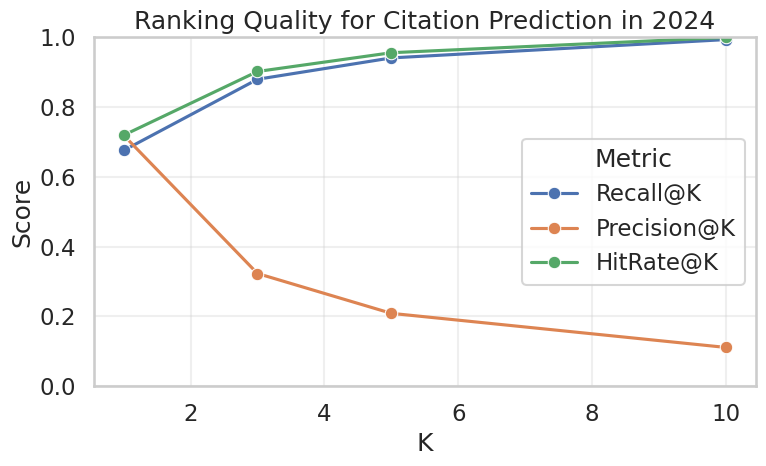

In [240]:
plot_ranking = ranking_metrics_df.melt(
    id_vars=["K", "N_sources"],
    value_vars=["Recall@K", "Precision@K", "HitRate@K"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=plot_ranking,
    x="K",
    y="Score",
    hue="Metric",
    marker="o",
)

plt.title(f"Ranking Quality for Citation Prediction in {PREDICTION_YEAR}")
plt.xlabel("K")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 12.2. Target and Source Recommendations


In [241]:
metadata_paths = [
    TRAIN_NORMALIZED,
    VAL_NORMALIZED,
    TEST_NORMALIZED,
]

paper_meta = pd.concat([
    pd.read_parquet(
        path,
        columns=["id", "title", "year", "venue_norm", "doc_type", "n_authors"]
    )
    for path in metadata_paths
    if Path(path).exists()
], ignore_index=True)

paper_meta = paper_meta.drop_duplicates(subset=["id"])

source_meta = paper_meta.rename(columns={
    "id": "source_id",
    "title": "source_title",
    "year": "source_year_meta",
    "venue_norm": "source_venue",
    "doc_type": "source_doc_type",
    "n_authors": "source_n_authors",
})

target_meta = paper_meta.rename(columns={
    "id": "target_id",
    "title": "target_title",
    "year": "target_year",
    "venue_norm": "target_venue",
    "doc_type": "target_doc_type",
    "n_authors": "target_n_authors",
})

year_features_named = (
    year_features
    .merge(source_meta, on="source_id", how="left")
    .merge(target_meta, on="target_id", how="left")
)

print(f"Year {PREDICTION_YEAR} candidate pairs with metadata: {len(year_features_named):,}")
print(f"Source papers: {year_features_named['source_id'].nunique():,}")
print(f"Target papers: {year_features_named['target_id'].nunique():,}")

Year 2024 candidate pairs with metadata: 390,830
Source papers: 39,112
Target papers: 268,200


In [242]:
TOP_N_PAIRS = 30

top_pairs_named = (
    year_features_named
    .sort_values("citation_probability", ascending=False)
    .head(TOP_N_PAIRS)
    [[
        "source_id",
        "source_title",
        "source_year_meta",
        "source_venue",
        "target_id",
        "target_title",
        "target_year",
        "target_venue",
        "label",
        "citation_probability",
        "abstract_sim",
        "title_sim",
        "n_citation_target",
        "in_degree_target",
        "pagerank_target",
    ]]
)

pd.set_option("display.max_colwidth", 90)

print(f"Top predicted citation pairs for {PREDICTION_YEAR}:")
print(
    top_pairs_named
    .round({
        "citation_probability": 4,
        "abstract_sim": 4,
        "title_sim": 4,
        "pagerank_target": 4,
    })
    .to_string(index=False)
)


Top predicted citation pairs for 2024:
               source_id                                                                                                                  source_title  source_year_meta                                                                                                                                                                                source_venue                target_id                                                                                             target_title  target_year                                                                                                  target_venue  label  citation_probability  abstract_sim  title_sim  n_citation_target  in_degree_target  pagerank_target
65fb832113fb2c6cf6750fcb                  REPS: Rotation Equivariant Siamese Network Enhanced by Probability Segmentation for Satellite Video Tracking              2024                                                                           

In [243]:
target_recommendation_summary = (
    year_features_named
    .groupby(["target_id", "target_title", "target_year", "target_venue"], dropna=False)
    .agg(
        n_candidate_sources=("source_id", "count"),
        n_true_citations=("label", "sum"),
        mean_probability=("citation_probability", "mean"),
        max_probability=("citation_probability", "max"),
        expected_citations=("citation_probability", "sum"),
        mean_abstract_sim=("abstract_sim", "mean"),
        mean_title_sim=("title_sim", "mean"),
        n_citation_target=("n_citation_target", "max"),
        in_degree_target=("in_degree_target", "max"),
        pagerank_target=("pagerank_target", "max"),
    )
    .reset_index()
    .sort_values("expected_citations", ascending=False)
)

print(f"Most recommended target papers for {PREDICTION_YEAR}:")
print(
    target_recommendation_summary
    .head(20)
    .round(4)
    .to_string(index=False)
)


Most recommended target papers for 2024:
               target_id                                                                                                    target_title  target_year                                                         target_venue  n_candidate_sources  n_true_citations  mean_probability  max_probability  expected_citations  mean_abstract_sim  mean_title_sim  n_citation_target  in_degree_target  pagerank_target
573695fd6e3b12023e510ff5                                               Deeply-Recursive Convolutional Network for Image Super-Resolution         2015 2016 ieee conference on computer vision and pattern recognition cvpr                  258                 1            0.7391           0.9908            190.6970             0.0522          0.0343             2132.0              1115           0.0000
573696026e3b12023e515eec                                                                    Deep Residual Learning for Image Recognition         2016 2016 

Which papers are predicted to be frequently cited by many papers published in 2024?

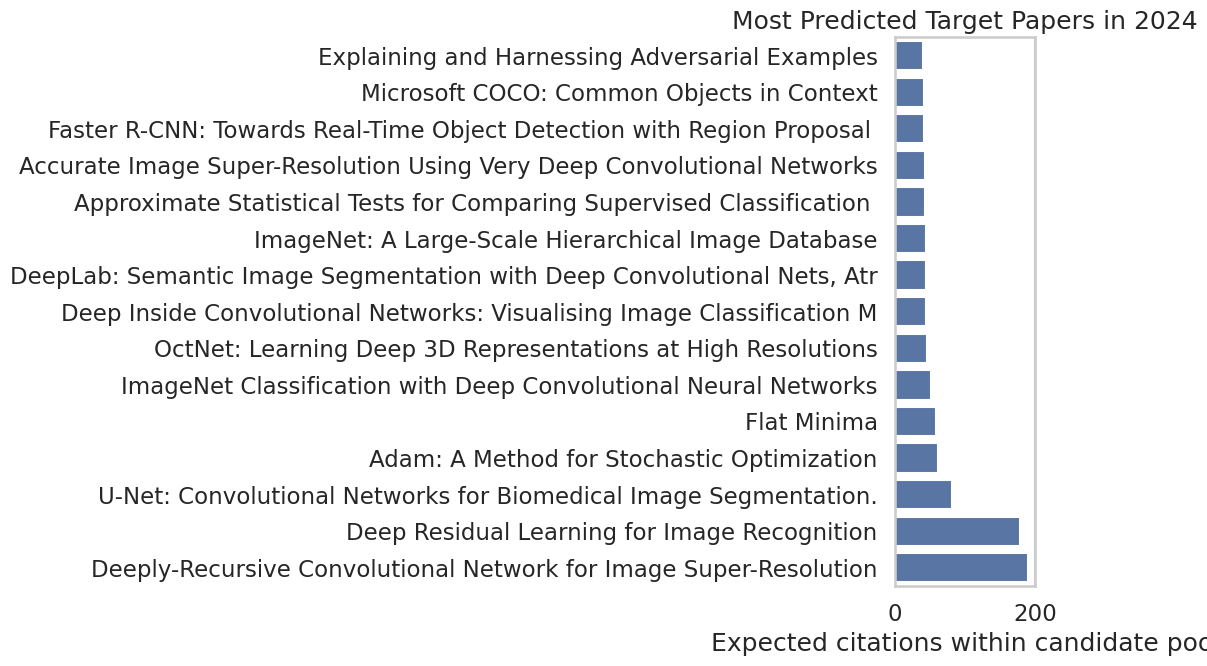

In [244]:
plot_targets = target_recommendation_summary.head(15).copy()

plot_targets["target_label"] = (
    plot_targets["target_title"]
    .fillna(plot_targets["target_id"])
    .str.slice(0, 70)
)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=plot_targets.sort_values("expected_citations", ascending=True),
    x="expected_citations",
    y="target_label",
    color="#4C72B0",
)

plt.title(f"Most Predicted Target Papers in {PREDICTION_YEAR}")
plt.xlabel("Expected citations within candidate pool")
plt.ylabel("")
plt.tight_layout()
plt.show()


A number of highly “attractive” papers stand out in the candidate pool: ResNet, U-Net, Adam, ImageNet, COCO, etc. These are central, reusable, popular, or semantically linked to many source papers.

In [245]:
source_prediction_summary = (
    year_features_named
    # .sort_values("citation_probability", ascending=False)  old one
    .groupby(["source_id", "source_title", "source_year_meta", "source_venue"], dropna=False)
    .agg(
        candidate_targets=("target_id", "count"),
        true_citations=("label", "sum"),
        expected_citations=("citation_probability", "sum"),
        mean_probability=("citation_probability", "mean"),
        max_probability=("citation_probability", "max"),
        top10_expected=("citation_probability", lambda s: s.nlargest(10).sum()), 
        #top10_expected=("citation_probability", lambda s: s.head(10).sum()), old one
    )
    .reset_index()
    .sort_values("top10_expected", ascending=False)
)
top10_expected=("citation_probability", lambda s: s.head(10).sum()),
print(f"Source papers with strongest top-10 predicted citations for {PREDICTION_YEAR}:")
print(
    source_prediction_summary
    .head(20)
    .round(4)
    .to_string(index=False)
)

Source papers with strongest top-10 predicted citations for 2024:
               source_id                                                                                                                                          source_title  source_year_meta                                                                                    source_venue  candidate_targets  true_citations  expected_citations  mean_probability  max_probability  top10_expected
64a39885d68f896efa31e2e0           Quantum Machine Learning on Near-Term Quantum Devices: Current State of Supervised and Unsupervised Techniques for Real-World Applications.              2024                                                                         physical review applied                 33               4             15.0578            0.4563           0.9855          9.4617
6482a38ed68f896efa8db406                                                                                                            Classical Ve

For which 2024 papers does the model have the most “reliable” citation list?

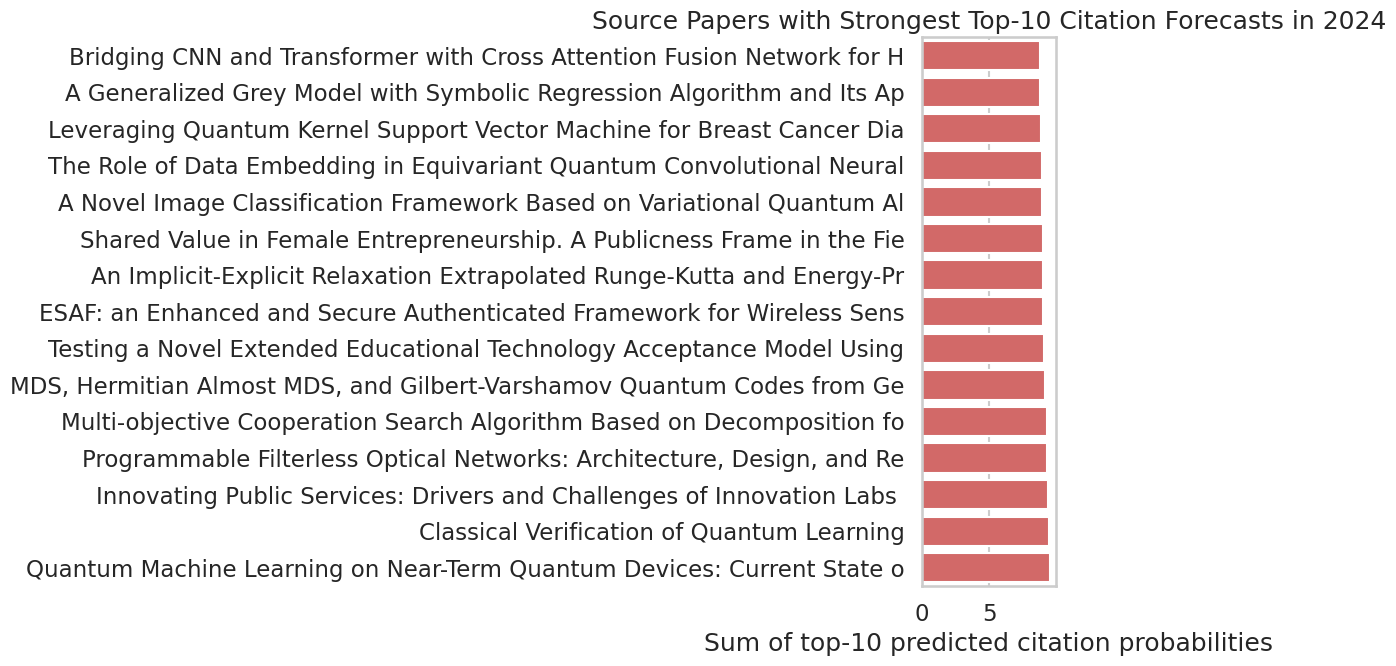

In [246]:
plot_sources = source_prediction_summary.head(15).copy()

plot_sources["source_label"] = (
    plot_sources["source_title"]
    .fillna(plot_sources["source_id"])
    .str.slice(0, 70)
)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=plot_sources.sort_values("top10_expected", ascending=True),
    x="top10_expected",
    y="source_label",
    color="#E45756",
)

plt.title(f"Source Papers with Strongest Top-10 Citation Forecasts in {PREDICTION_YEAR}")
plt.xlabel("Sum of top-10 predicted citation probabilities")
plt.ylabel("")
plt.tight_layout()
plt.show()


These are the source papers for which the model produces a highly confident ranked list.

In [247]:
SOURCE_RANK = 0

selected_source_id = source_prediction_summary.iloc[SOURCE_RANK]["source_id"]
selected_source_title = source_prediction_summary.iloc[SOURCE_RANK]["source_title"]

source_view = (
    year_features_named[year_features_named["source_id"] == selected_source_id]
    .sort_values("citation_probability", ascending=False)
    .head(20)
    [[
        "source_title",
        "target_title",
        "target_year",
        "target_venue",
        "label",
        "citation_probability",
        "abstract_sim",
        "title_sim",
        "n_citation_target",
        "in_degree_target",
        "pagerank_target",
        "same_venue",
        "same_doc_type",
    ]]
)

print("Selected source paper:")
print(selected_source_title)
print("\nTop predicted target papers for this source:")
print(source_view.round(4).to_string(index=False))


Selected source paper:
Quantum Machine Learning on Near-Term Quantum Devices: Current State of Supervised and Unsupervised Techniques for Real-World Applications.

Top predicted target papers for this source:
                                                                                                                               source_title                                                                                                          target_title  target_year                           target_venue  label  citation_probability  abstract_sim  title_sim  n_citation_target  in_degree_target  pagerank_target  same_venue  same_doc_type
Quantum Machine Learning on Near-Term Quantum Devices: Current State of Supervised and Unsupervised Techniques for Real-World Applications.                                                                                              Quantum Machine Learning         2017                                 nature      1                0.9855        

For a specific X source paper, which targets are recommended as the most likely citations?

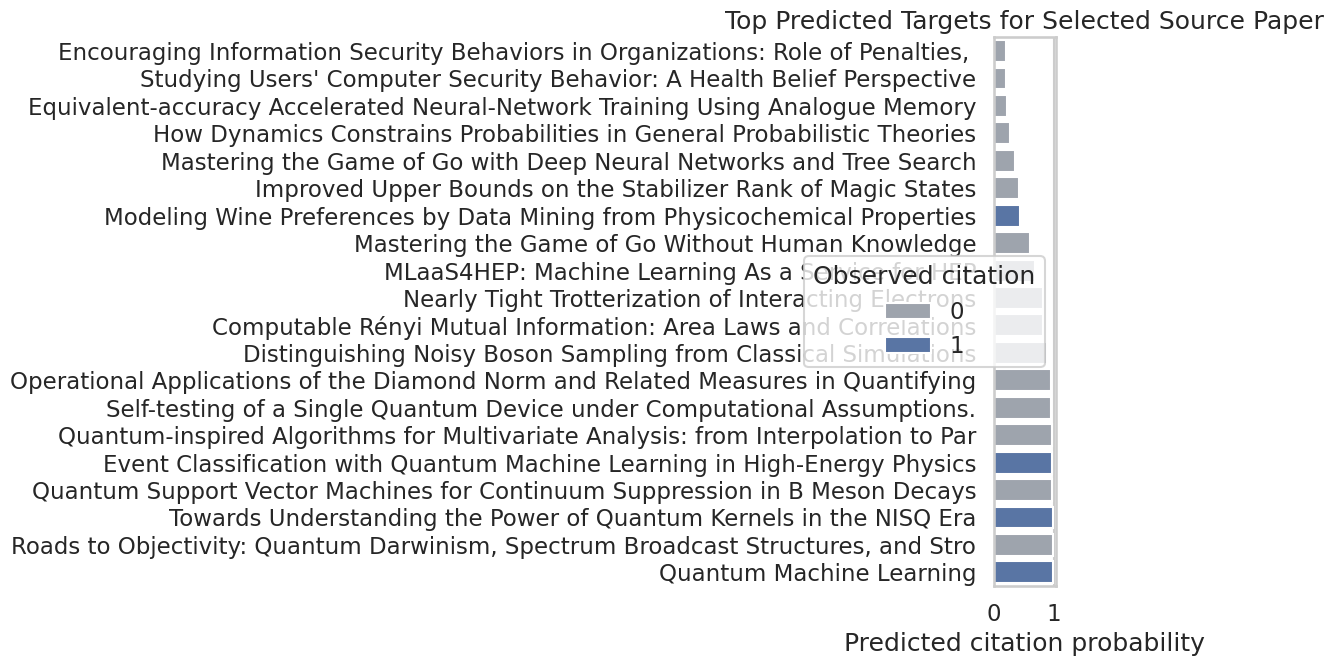

In [248]:
plot_source_view = source_view.copy()
plot_source_view["target_label"] = plot_source_view["target_title"].fillna("").str.slice(0, 80)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=plot_source_view.sort_values("citation_probability", ascending=True),
    x="citation_probability",
    y="target_label",
    hue="label",
    dodge=False,
    palette={0: "#9CA3AF", 1: "#4C72B0"},
)

plt.title("Top Predicted Targets for Selected Source Paper")
plt.xlabel("Predicted citation probability")
plt.ylabel("")
plt.legend(title="Observed citation")
plt.tight_layout()
plt.show()


the recommended targets are indeed consistent with the theme of the source

### 12.3. Feature Space Visualization


In [255]:
PLOT_SAMPLE_SIZE = 50_000

plot_df = year_features_named.copy()

if len(plot_df) > PLOT_SAMPLE_SIZE:
    plot_df = plot_df.sample(PLOT_SAMPLE_SIZE, random_state=42)

plot_features = best_features

X_plot = plot_df[plot_features].astype(np.float32).fillna(0)

scaler_plot = StandardScaler()
X_plot_scaled = scaler_plot.fit_transform(X_plot)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_plot_scaled)

plot_df["pca_1"] = coords[:, 0]
plot_df["pca_2"] = coords[:, 1]

explained = pca.explained_variance_ratio_.sum()

print(f"PCA explained variance: {explained:.3f}")
print(f"Plotted candidate pairs: {len(plot_df):,}")


PCA explained variance: 0.605
Plotted candidate pairs: 50,000


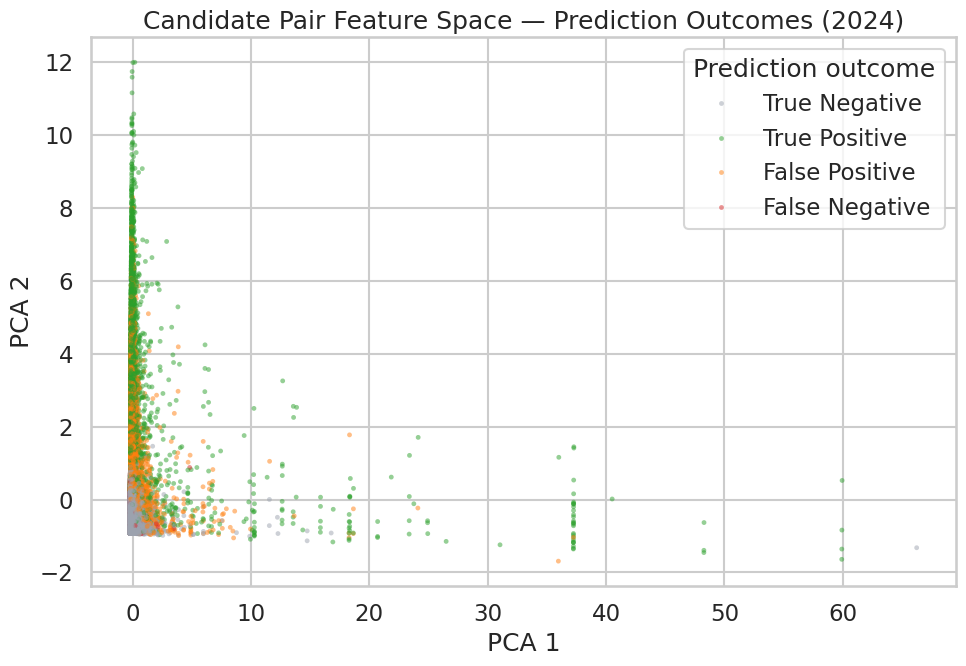

In [ ]:
plot_df["prediction_error_type"] = np.select(
    [
        (plot_df["label"] == 1) & (plot_df["predicted_label"] == 1),
        (plot_df["label"] == 0) & (plot_df["predicted_label"] == 0),
        (plot_df["label"] == 0) & (plot_df["predicted_label"] == 1),
        (plot_df["label"] == 1) & (plot_df["predicted_label"] == 0),
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
    ],
    default="Unknown",
)

error_palette = {
    "True Positive": "#2CA02C",
    "True Negative": "#9CA3AF",
    "False Positive": "#FF7F0E",
    "False Negative": "#D62728",
    "Unknown": "#6B7280",
}

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_df,
    x="pca_1",
    y="pca_2",
    hue="prediction_error_type",
    palette=error_palette,
    s=12,
    alpha=0.5,
    linewidth=0,
)

plt.title(f"Candidate Pair Feature Space — Prediction Outcomes ({PREDICTION_YEAR})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Prediction outcome", loc="best")
plt.tight_layout()
plt.show()


Errors are not random. False positives tend to be plausible pairs based on the features, whilst false negatives are relatively few. This suggests that the model is better at identifying genuine citations than at maintaining high accuracy when we expand the list of candidates.

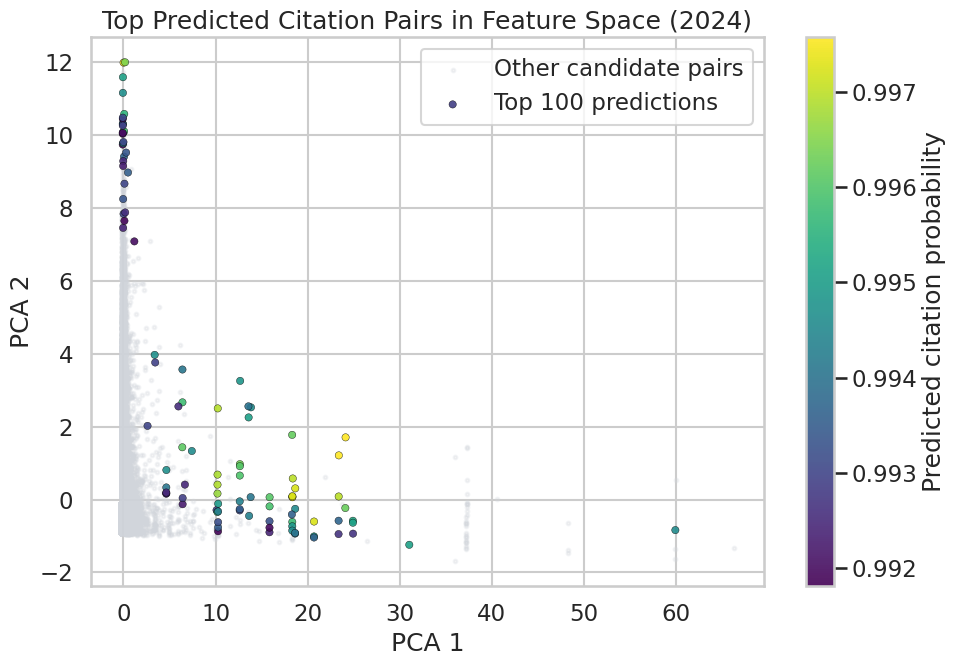

In [252]:
TOP_HIGHLIGHT = 100

plot_df["is_top_prediction"] = False
top_idx = plot_df.nlargest(TOP_HIGHLIGHT, "citation_probability").index
plot_df.loc[top_idx, "is_top_prediction"] = True

plt.figure(figsize=(10, 7))

base = plot_df[~plot_df["is_top_prediction"]]
top = plot_df[plot_df["is_top_prediction"]]

plt.scatter(
    base["pca_1"],
    base["pca_2"],
    c="#D1D5DB",
    s=7,
    alpha=0.25,
    label="Other candidate pairs",
)

plt.scatter(
    top["pca_1"],
    top["pca_2"],
    c=top["citation_probability"],
    cmap="viridis",
    s=28,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.3,
    label=f"Top {TOP_HIGHLIGHT} predictions",
)

plt.colorbar(label="Predicted citation probability")
plt.title(f"Top Predicted Citation Pairs in Feature Space ({PREDICTION_YEAR})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.tight_layout()
plt.show()


The strongest predictions are neither isolated nor random: they occur in specific regions of the feature space, though not all in the same region. The model appears to recognise several types of highly citable pairs.

In [253]:
driver_features = [
    "abstract_sim",
    "title_sim",
    "n_citation_target",
    "in_degree_target",
    "pagerank_target",
    "year_diff",
    "same_venue",
    "same_doc_type",
]

top_driver_pairs = (
    year_features_named
    .sort_values("citation_probability", ascending=False)
    .head(10)
    [["source_title", "target_title", "label", "citation_probability"] + driver_features]
)

print("Feature values for highest-scored pairs:")
print(top_driver_pairs.round(4).to_string(index=False))


Feature values for highest-scored pairs:
                                                                                                source_title                                                                                        target_title  label  citation_probability  abstract_sim  title_sim  n_citation_target  in_degree_target  pagerank_target  year_diff  same_venue  same_doc_type
REPS: Rotation Equivariant Siamese Network Enhanced by Probability Segmentation for Satellite Video Tracking                                                   ImageNet Large Scale Visual Recognition Challenge      1                0.9979        0.0810     0.0000            13788.0              7552           0.0001          9           0              1
                                                              Perception-Aware Texture Similarity Prediction                            Image Quality Assessment: from Error Visibility to Structural Similarity      1                0.9978        0.13